# comparing_model2 — track comparisons via `evals.plotting_utils`

Recreates the example-track figures from `comparing_model.ipynb`, but using the new
general-purpose plotting utility (`evals/plotting_utils.py`). Instead of hand-rolled
stacked axes, each figure is one `plot_tracks(...)` call, and every panel now gets a
real **genomic x-axis** plus an **IGV/UCSC-style gene track** underneath.

Three cases (all ranked by the smoothed-log Pearson metric):
1. **Mamba (GM12878) beats Enformer**
2. **Mamba (GM12878) beats BOTH Enformer and AlphaGenome**
3. **Enformer beats Mamba (GM12878)**

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

# make the utility importable
sys.path.insert(0, '/data1/lesliec/sarthak/caduceus')
from evals.plotting_utils import Track, GeneAnnotation, plot_tracks

## 1. Load predictions, targets, and the smoothed-log Pearson metric

Same data/metric as the AlphaGenome section of the original notebook.

In [2]:
MODEL_OUT = '/data1/lesliec/sarthak/data/joint_playground/model_out'

# Enformer full output (memory-mapped); GM12878 CAGE lives at track 5110
enformer_full = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy', mmap_mode='r')
# AlphaGenome preds are (1937, 896, 273); track 156 is the matching GM12878 CAGE track
ALPHAGENOME_TRACK = 156

model_names = [
    'enformer',
    'GM12878_no_mlm_predictions.npy',
    'alphagenome_cage_test_128bp.npy',
]

preds = {}
for model_name in model_names:
    if model_name == 'enformer':
        preds[model_name] = enformer_full[:, :, 5110]
    elif model_name == 'alphagenome_cage_test_128bp.npy':
        ag = np.load(f'{MODEL_OUT}/{model_name}', mmap_mode='r')
        preds[model_name] = ag[:, :, ALPHAGENOME_TRACK]
    else:
        preds[model_name] = np.load(f'{MODEL_OUT}/{model_name}')
        if preds[model_name].ndim == 3:
            preds[model_name] = preds[model_name][:, :, 0]
    print(f'{model_name}: {preds[model_name].shape}')

# shared GM12878 CAGE targets (identical for every model)
t1 = np.load(f'{MODEL_OUT}/GM12878_base_targets_conv.npy')
print('targets:', t1.shape)

# --- smoothed-log Pearson: log1p + Gaussian smoothing (same as original) ---
SMOOTH_SIGMA = 1.5  # bins (~128 bp each)

def smoothed_log_pearson(pred, true, sigma=SMOOTH_SIGMA):
    p = gaussian_filter1d(np.log1p(np.clip(pred, 0, None)), sigma=sigma)
    t = gaussian_filter1d(np.log1p(np.clip(true, 0, None)), sigma=sigma)
    if np.std(p) < 1e-8 or np.std(t) < 1e-8:
        return np.nan
    return pearsonr(p, t)[0]

pearson_smooth_results = {}
for name, arr in preds.items():
    assert arr.shape == t1.shape, f'{name} vs t1 shape mismatch!'
    vals = np.array([smoothed_log_pearson(arr[i], t1[i]) for i in tqdm(range(arr.shape[0]), desc=name)])
    pearson_smooth_results[name] = vals
    print(f'{name}: mean smoothed-log Pearson = {np.nanmean(vals):.3f} ({np.isnan(vals).sum()} flat/undefined)')

enformer: (1937, 896)
GM12878_no_mlm_predictions.npy: (1937, 896)
alphagenome_cage_test_128bp.npy: (1937, 896)
targets: (1937, 896)


enformer:   0%|          | 0/1937 [00:00<?, ?it/s]

enformer: 100%|██████████| 1937/1937 [00:02<00:00, 696.49it/s]


enformer: mean smoothed-log Pearson = 0.651 (0 flat/undefined)


GM12878_no_mlm_predictions.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1489.35it/s]


GM12878_no_mlm_predictions.npy: mean smoothed-log Pearson = 0.641 (0 flat/undefined)


alphagenome_cage_test_128bp.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1315.91it/s]

alphagenome_cage_test_128bp.npy: mean smoothed-log Pearson = 0.483 (0 flat/undefined)


## 2. Genomic coordinates for each test region

The predicted 896-bin window is the center `896*128 = 114688 bp` of each 131072 bp BED
region, offset by `CROP = 8192 bp`. Test-region index order == BED file order (after
filtering the last column to `test`).

In [3]:
import pandas as pd

BED_PATH = '/data1/lesliec/sarthak/data/DK_zarr/sequences_enformer.bed'
SEQ_LEN  = 131072
PRED_LEN = 896 * 128        # 114688
BIN      = 128
CROP     = (SEQ_LEN - PRED_LEN) // 2   # 8192

_bed = pd.read_csv(BED_PATH, sep='\t', header=None)
_test_bed = _bed[_bed.iloc[:, -1] == 'test'].reset_index(drop=True)
assert len(_test_bed) == t1.shape[0], (len(_test_bed), t1.shape[0])

def region_coords(idx):
    """Genomic coords of the PREDICTED window for test region `idx`."""
    chrom = str(_test_bed.iloc[idx, 0])
    start = int(_test_bed.iloc[idx, 1]) + CROP   # predicted window begins CROP into the bed region
    end   = start + PRED_LEN
    return chrom, start, end

## 3. Gene annotation (GENCODE v49)

First run parses the GTF and writes a parquet cache (~45 s); later runs load in ~1 s.

In [4]:
ann = GeneAnnotation()   # default GENCODE v49, protein_coding, exon+transcript
print('annotation rows:', len(ann.df))

annotation rows: 3222714


## 4. GM12878 DNase accessibility (whole-genome, per chromosome)

`GM12878_DNase.npz` holds one base-pair-resolution coverage array per chromosome
(`chr1`..`chr22`, `chrX`, `chrY`; each shape `(1, chrom_len)`, hg38). For a region we
slice `[start:end]` of the predicted window and mean-pool 128 bp -> 896 bins so it
aligns with the CAGE tracks. Chromosome arrays are cached on first access.

In [5]:
DNASE_PATH = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz'
_dnase = np.load(DNASE_PATH)          # per-chromosome arrays, shape (1, chrom_len)
_dnase_cache = {}

def _dnase_chrom(chrom):
    if chrom not in _dnase_cache:
        _dnase_cache[chrom] = np.asarray(_dnase[chrom][0], dtype=np.float32)
    return _dnase_cache[chrom]

def dnase_profile(idx):
    """Mean-pooled DNase over the 896-bin predicted window for test region `idx`."""
    chrom, start, end = region_coords(idx)
    seg = _dnase_chrom(chrom)[start:end]
    if len(seg) < PRED_LEN:            # pad if the window runs off the chromosome end
        seg = np.pad(seg, (0, PRED_LEN - len(seg)))
    return seg[:PRED_LEN].reshape(896, BIN).mean(axis=1)

## 5. Helper: build tracks for one test region

Predictions are drawn as lines; the shared GM12878 CAGE target is passed as
`ground_truth` (gray fill + dashed max-reference on the prediction axes, matching the
original). The DNase accessibility track is added on its own axis as a differently-
colored fill, and marked `reference_exempt` so the CAGE max-line/scale don't apply to
it (it's a different assay).

In [6]:
# consistent colors carried over from the original notebook
COLORS = {
    'GM12878_no_mlm_predictions.npy': '#2ca02c',      # Mamba (GM12878) — green
    'enformer':                       '#1f77b4',      # Enformer — blue
    'alphagenome_cage_test_128bp.npy': '#ff7f0e',     # AlphaGenome — orange
}
PRETTY = {
    'GM12878_no_mlm_predictions.npy': 'Mamba (GM12878)',
    'enformer':                       'Enformer',
    'alphagenome_cage_test_128bp.npy': 'AlphaGenome',
}

DNASE_COLOR = '#9467bd'   # purple — distinct from the CAGE tracks and gray truth

def make_tracks(idx, model_keys, add_dnase=True):
    chrom, start, end = region_coords(idx)
    common = dict(chrom=chrom, start=start, bin_size=BIN)
    tracks = [Track(np.asarray(preds[k][idx]), name=PRETTY[k], color=COLORS[k], **common)
              for k in model_keys]
    if add_dnase:
        tracks.append(Track(dnase_profile(idx), name='DNase (GM12878)', color=DNASE_COLOR,
                            style='fill', alpha=0.5, reference_exempt=True, **common))
    truth = Track(np.asarray(t1[idx]), name='True (CAGE)', is_truth=True, **common)
    return tracks, truth, (chrom, start, end)

def r(key, idx):
    return pearson_smooth_results[key][idx]

N_EXAMPLES = 3   # few examples per case

## Case 1 — Mamba (GM12878) beats Enformer

Ranked by `ΔR_smooth = Mamba − Enformer` (largest first).

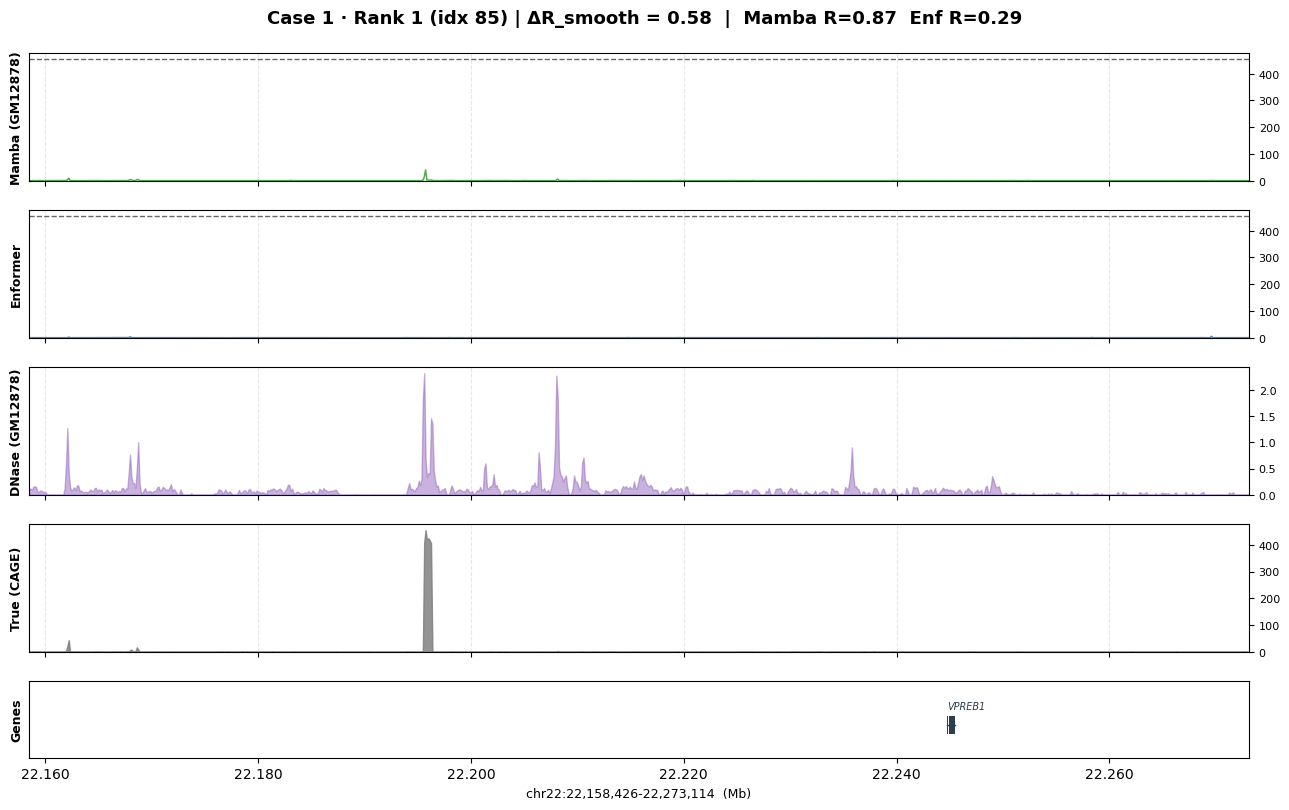

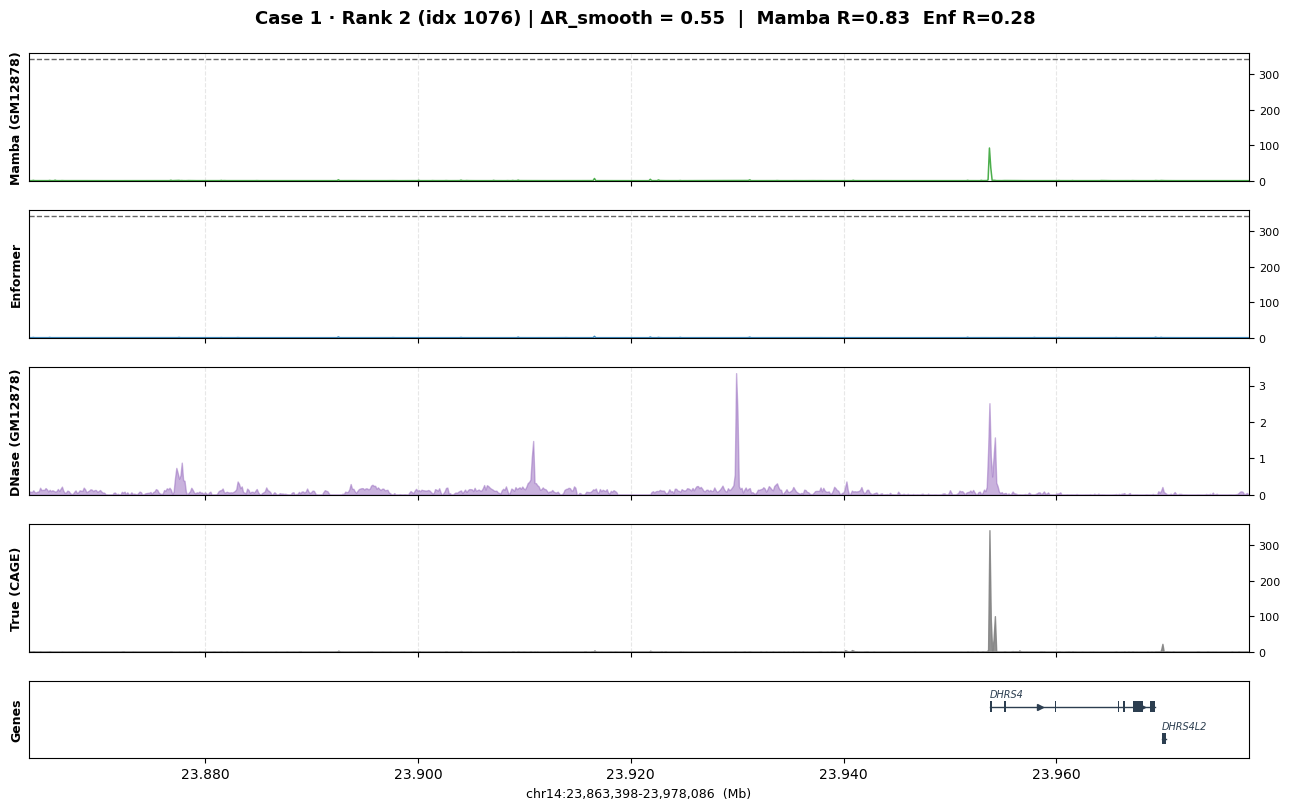

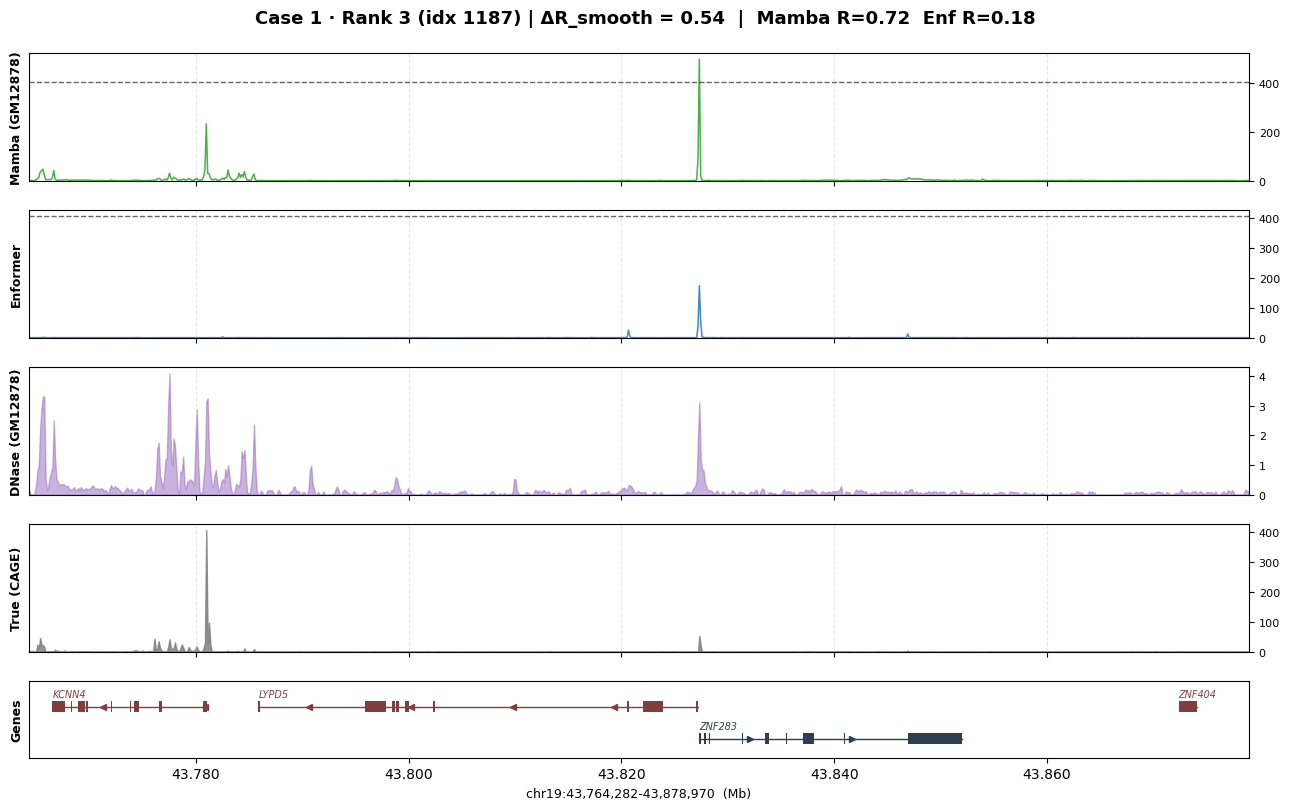

In [7]:
mamba_key    = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'

delta = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
ranked = np.where(np.isnan(delta), -np.inf, delta)
top = np.argsort(ranked)[-N_EXAMPLES:][::-1]

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, enformer_key])
    title = (f'Case 1 · Rank {rank+1} (idx {idx}) | ΔR_smooth = {delta[idx]:.2f}  '
             f'|  Mamba R={r(mamba_key, idx):.2f}  Enf R={r(enformer_key, idx):.2f}')
    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title)
    plt.show()

## Case 2 — Mamba (GM12878) beats BOTH Enformer and AlphaGenome

Ranked by `min(ΔR vs Enformer, ΔR vs AlphaGenome)` — the worse of the two margins is
still large, so Mamba beats both.

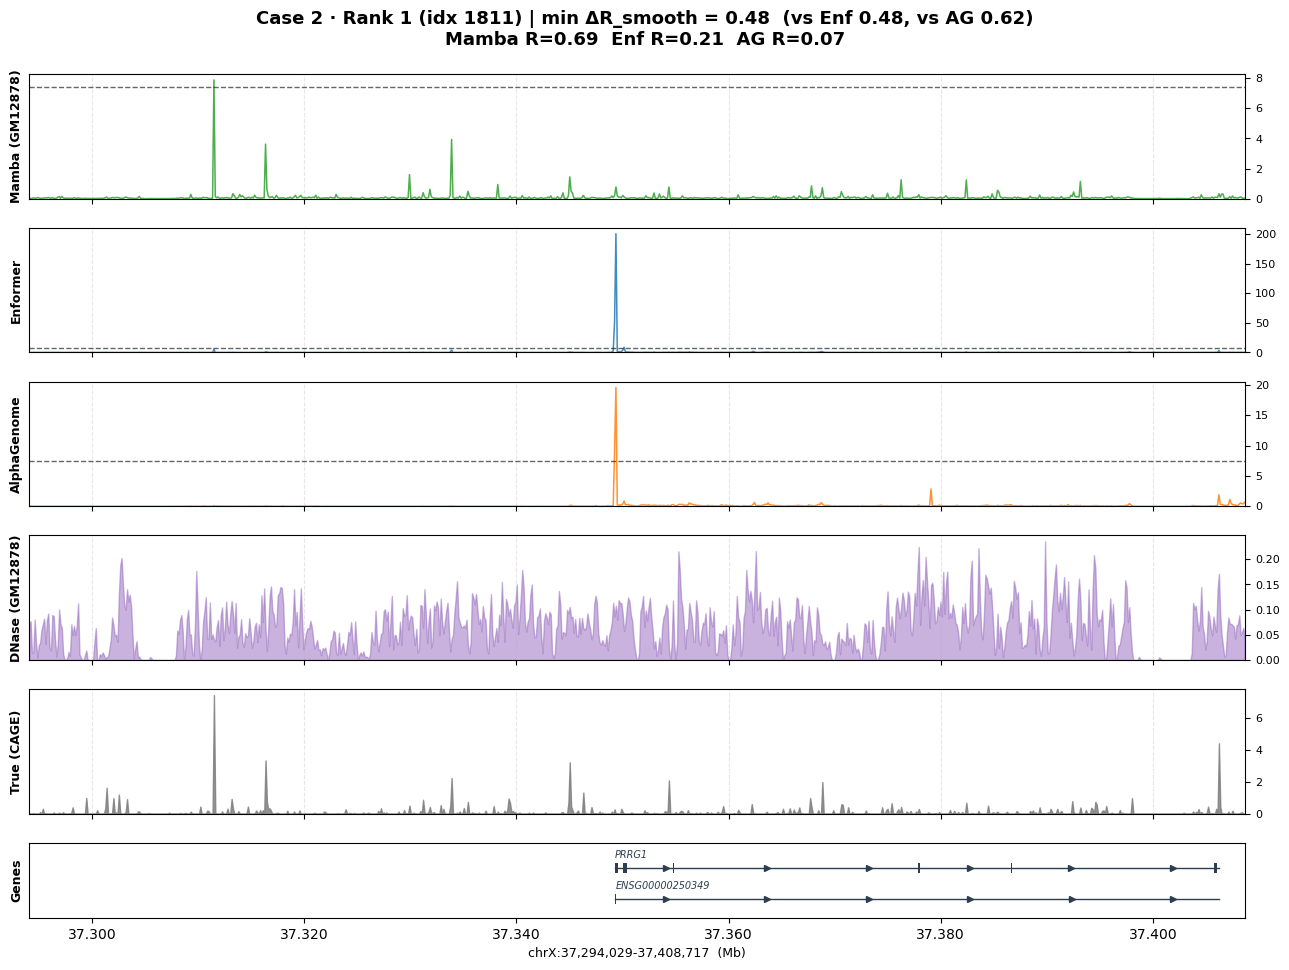

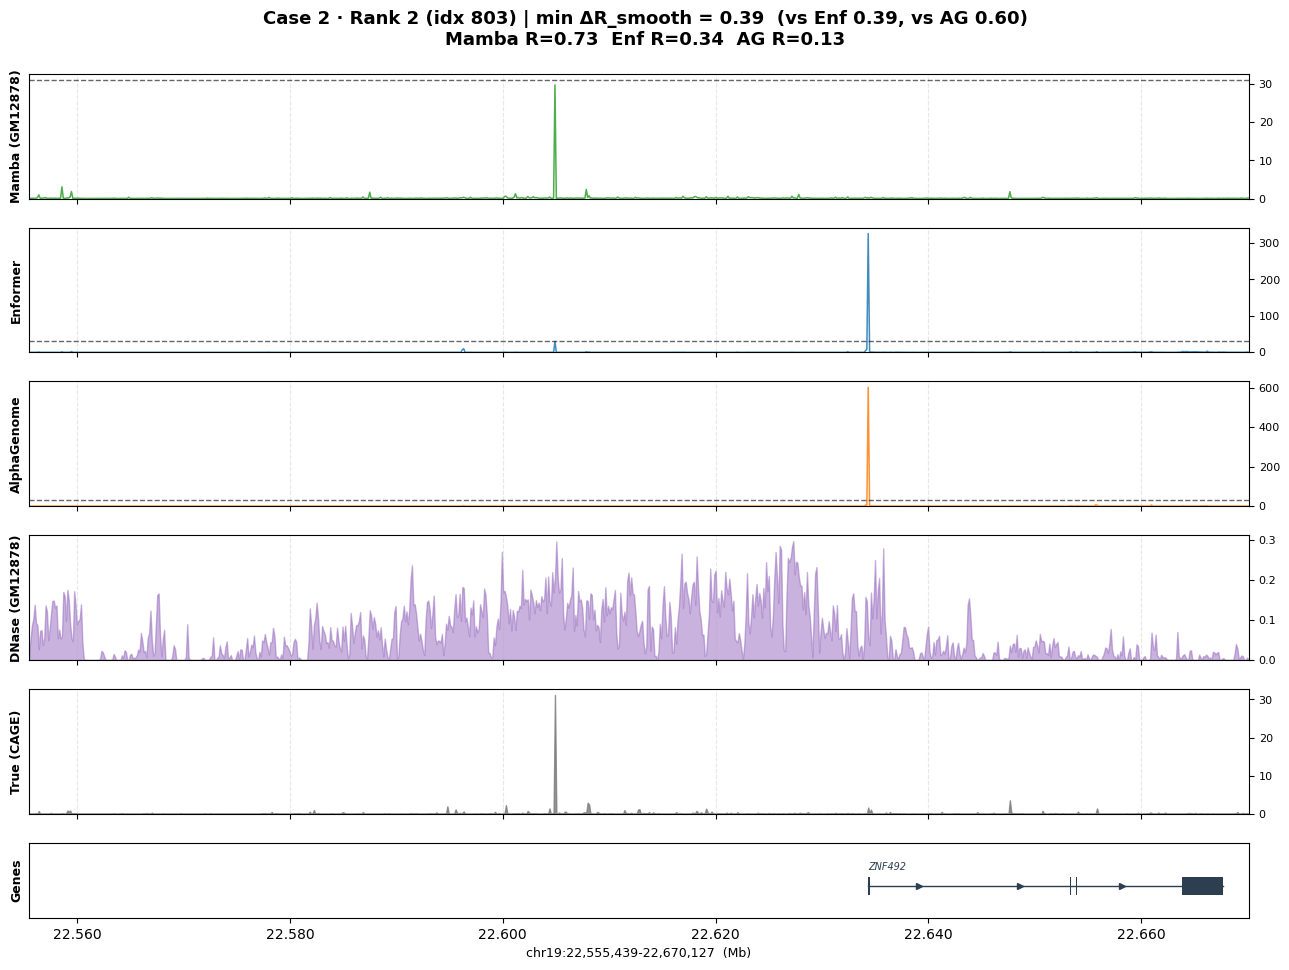

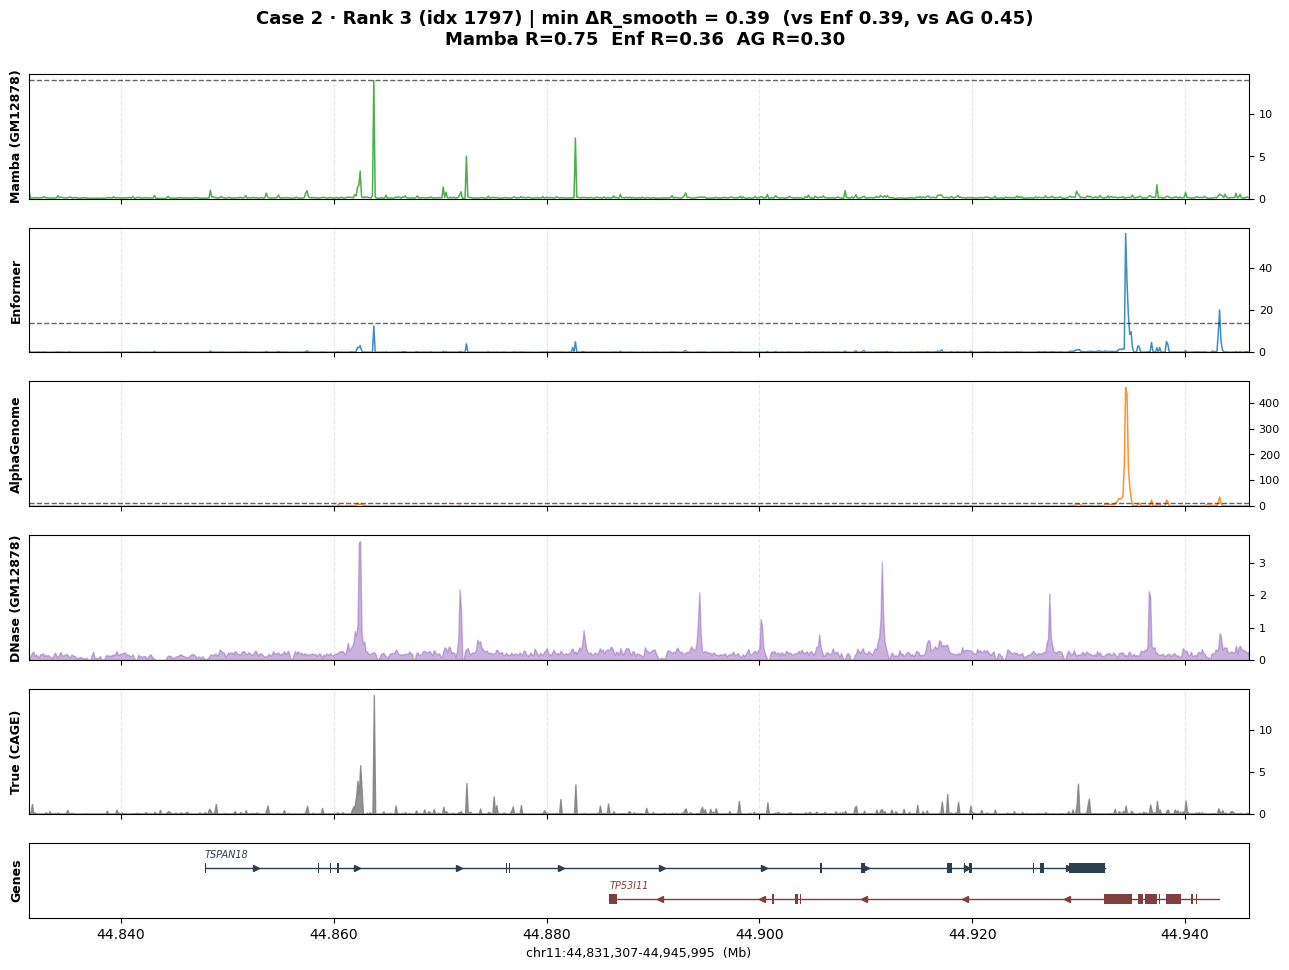

In [8]:
mamba_key    = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key       = 'alphagenome_cage_test_128bp.npy'

delta_enf = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag  = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_both = np.minimum(delta_enf, delta_ag)
ranked = np.where(np.isnan(delta_both), -np.inf, delta_both)
top = np.argsort(ranked)[-N_EXAMPLES:][::-1]

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, enformer_key, ag_key])
    title = (f'Case 2 · Rank {rank+1} (idx {idx}) | min ΔR_smooth = {delta_both[idx]:.2f}  '
             f'(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n'
             f'Mamba R={r(mamba_key, idx):.2f}  Enf R={r(enformer_key, idx):.2f}  AG R={r(ag_key, idx):.2f}')
    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title)
    plt.show()

## Case 3 — Enformer beats Mamba (GM12878)

Ranked by `ΔR_smooth = Enformer − Mamba` (largest first).

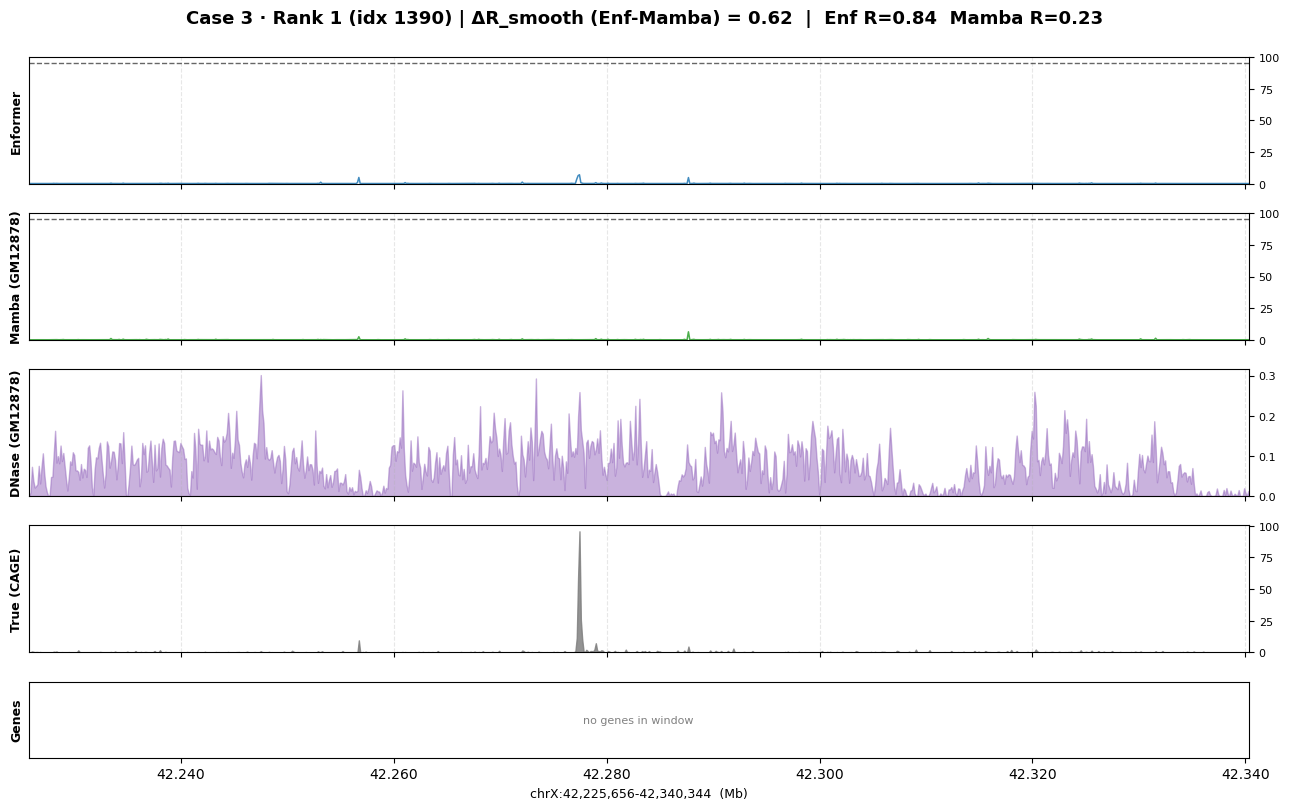

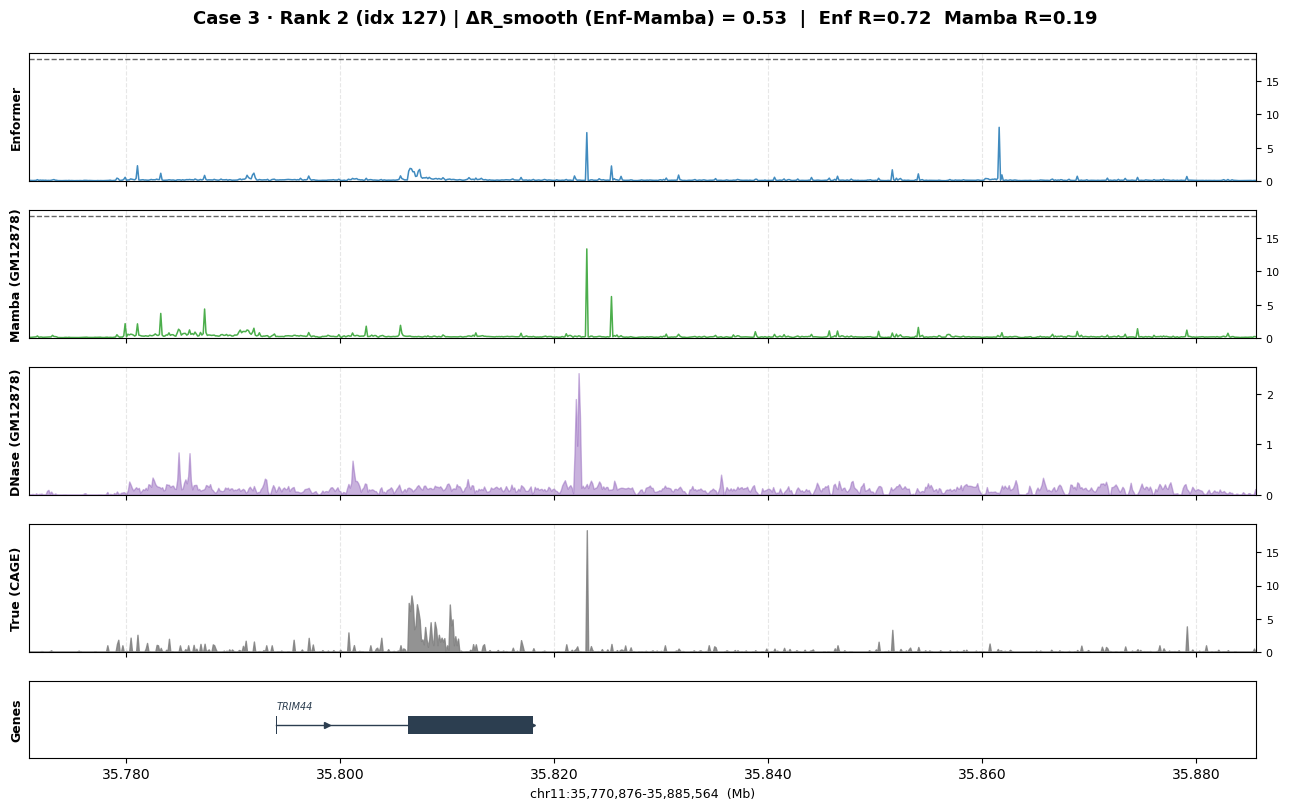

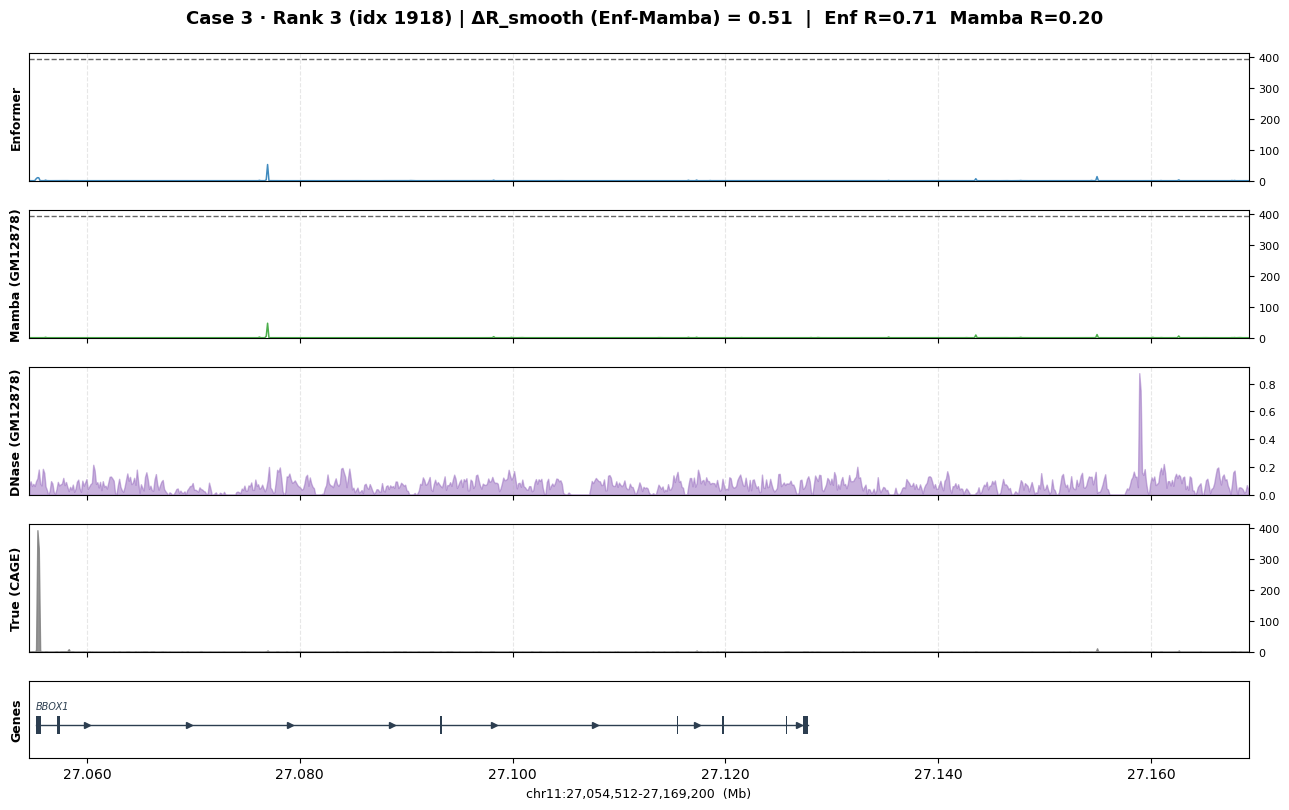

In [9]:
mamba_key    = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'

delta = pearson_smooth_results[enformer_key] - pearson_smooth_results[mamba_key]
ranked = np.where(np.isnan(delta), -np.inf, delta)
top = np.argsort(ranked)[-N_EXAMPLES:][::-1]

for rank, idx in enumerate(top):
    # list Enformer first so it is the top axis for this case
    tracks, truth, region = make_tracks(idx, [enformer_key, mamba_key])
    title = (f'Case 3 · Rank {rank+1} (idx {idx}) | ΔR_smooth (Enf-Mamba) = {delta[idx]:.2f}  '
             f'|  Enf R={r(enformer_key, idx):.2f}  Mamba R={r(mamba_key, idx):.2f}')
    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title)
    plt.show()

### Standalone reload for the filtered plots (run after a kernel restart)

Reloads **all** data the filtered-case cells need — predictions, targets, the ranking
metric, coordinates, DNase, gene annotation, the blacklist — so the blacklist and filtered-case cells below (§6–§8) run without re-running §1–§5. It also loads the **other cell types** from `labels.zarr` and builds a new
**average-across-cell-types CAGE** track: the mean over all 638 CAGE experiments at each
locus, i.e. the "generic" expression profile. Overlaying it tests the hypothesis that
Enformer/AlphaGenome place peaks at genes that are broadly expressed but silent in GM12878
(their peaks track this average rather than the GM12878-specific truth).

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

sys.path.insert(0, '/data1/lesliec/sarthak/caduceus')
from evals.plotting_utils import Track, GeneAnnotation, plot_tracks

# --- predictions + shared GM12878 CAGE target ---
MODEL_OUT = '/data1/lesliec/sarthak/data/joint_playground/model_out'
enformer_full = np.load('/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy', mmap_mode='r')
ALPHAGENOME_TRACK = 156
model_names = ['enformer', 'GM12878_no_mlm_predictions.npy', 'immune_CAGE_predictions.npy', 'alphagenome_cage_test_128bp.npy']
preds = {}
for m in model_names:
    if m == 'enformer':
        preds[m] = enformer_full[:, :, 5110]
    elif m == 'alphagenome_cage_test_128bp.npy':
        preds[m] = np.load(f'{MODEL_OUT}/{m}', mmap_mode='r')[:, :, ALPHAGENOME_TRACK]
    else:
        _a = np.load(f'{MODEL_OUT}/{m}'); preds[m] = _a[:, :, 0] if _a.ndim == 3 else _a
t1 = np.load(f'{MODEL_OUT}/GM12878_base_targets_conv.npy')

# --- ranking metric: smoothed-log Pearson ---
SMOOTH_SIGMA = 1.5
def smoothed_log_pearson(pred, true, sigma=SMOOTH_SIGMA):
    p = gaussian_filter1d(np.log1p(np.clip(pred, 0, None)), sigma=sigma)
    t = gaussian_filter1d(np.log1p(np.clip(true, 0, None)), sigma=sigma)
    if np.std(p) < 1e-8 or np.std(t) < 1e-8:
        return np.nan
    return pearsonr(p, t)[0]
pearson_smooth_results = {}
for name, arr in preds.items():
    pearson_smooth_results[name] = np.array(
        [smoothed_log_pearson(arr[i], t1[i]) for i in tqdm(range(arr.shape[0]), desc=name)])

# --- genomic coordinates of each test region's predicted window ---
BED_PATH = '/data1/lesliec/sarthak/data/DK_zarr/sequences_enformer.bed'
SEQ_LEN = 131072; PRED_LEN = 896 * 128; BIN = 128; CROP = (SEQ_LEN - PRED_LEN) // 2
_bed = pd.read_csv(BED_PATH, sep='\t', header=None)
_test_bed = _bed[_bed.iloc[:, -1] == 'test'].reset_index(drop=True)
def region_coords(idx):
    chrom = str(_test_bed.iloc[idx, 0]); start = int(_test_bed.iloc[idx, 1]) + CROP
    return chrom, start, start + PRED_LEN

# --- GM12878 DNase accessibility (per-chromosome, bp resolution) ---
DNASE_PATH = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz'
_dnase = np.load(DNASE_PATH); _dnase_cache = {}
def _dnase_chrom(c):
    if c not in _dnase_cache:
        _dnase_cache[c] = np.asarray(_dnase[c][0], dtype=np.float32)
    return _dnase_cache[c]
def dnase_profile(idx):
    c, s, e = region_coords(idx); seg = _dnase_chrom(c)[s:e]
    if len(seg) < PRED_LEN:
        seg = np.pad(seg, (0, PRED_LEN - len(seg)))
    return seg[:PRED_LEN].reshape(896, BIN).mean(axis=1)

# --- NEW: average CAGE across ALL cell types ("generic" expression) from labels.zarr ---
# labels.zarr['test'] is (1937, 896, 5313), index-aligned with t1; CAGE block = 4675:5313
# (638 cell-type experiments), GM12878 CAGE = global track 5110.
CAGE_START = 4675
_labels_test = zarr.open('/data1/lesliec/sarthak/data/enformer/data/labels.zarr', mode='r')['test']
def avg_cage_profile(idx):
    return np.asarray(_labels_test[idx, :, CAGE_START:]).mean(axis=1)

# --- gene annotation ---
ann = GeneAnnotation()

# --- blacklist: extended-524288 train windows overlapping >20% of a test region ---
CONTEXT = 524288; HALF_CTX = CONTEXT // 2; OVERLAP_FRAC = 0.20
_split_col = _bed.shape[1] - 1
_train_by_chrom = {}
for chrom, g in _bed[_bed[_split_col] == 'train'].groupby(0):
    ts = g[1].astype(int).to_numpy(); te2 = g[2].astype(int).to_numpy(); ce = (ts + te2) // 2
    _train_by_chrom[str(chrom)] = (ce - HALF_CTX, ce + HALF_CTX)
blacklisted = np.zeros(len(_test_bed), dtype=bool)
for i in range(len(_test_bed)):
    chrom = str(_test_bed.iloc[i, 0]); c = int(_test_bed.iloc[i, 1]); d = int(_test_bed.iloc[i, 2])
    if chrom not in _train_by_chrom:
        continue
    a, b = _train_by_chrom[chrom]
    ov = np.maximum(0, np.minimum(b, d) - np.maximum(a, c))
    if np.any(ov > OVERLAP_FRAC * (d - c)):
        blacklisted[i] = True
allowed = ~blacklisted
print(f'Blacklisted {blacklisted.sum()} / {len(blacklisted)} test regions; {allowed.sum()} allowed')

# --- selection + styling helpers ---
N_EXAMPLES = 3
def top_allowed(score, n=None):
    n = n or N_EXAMPLES
    ranked = np.where(np.isnan(score) | ~allowed, -np.inf, score)
    return np.argsort(ranked)[-n:][::-1]
def r(key, idx):
    return pearson_smooth_results[key][idx]

COLORS = {'GM12878_no_mlm_predictions.npy': '#2ca02c', 'enformer': '#1f77b4',
          'alphagenome_cage_test_128bp.npy': '#ff7f0e', 'immune_CAGE_predictions.npy': '#d62728'}
PRETTY = {'GM12878_no_mlm_predictions.npy': 'Mamba (GM12878)', 'enformer': 'Enformer',
          'alphagenome_cage_test_128bp.npy': 'AlphaGenome', 'immune_CAGE_predictions.npy': 'Mamba (immune)'}

def make_tracks(idx, model_keys, add_avg=True, add_dnase=True):
    chrom, start, end = region_coords(idx)
    common = dict(chrom=chrom, start=start, bin_size=BIN)
    tracks = [Track(np.asarray(preds[k][idx]), name=PRETTY[k], color=COLORS[k], **common)
              for k in model_keys]
    if add_avg:   # generic cross-cell-type expression (own scale via reference_exempt)
        tracks.append(Track(avg_cage_profile(idx), name='Avg CAGE (all CTs)', color='#111111',
                            style='fill', alpha=0.35, reference_exempt=True, **common))
    if add_dnase:
        tracks.append(Track(dnase_profile(idx), name='DNase (GM12878)', color='#9467bd',
                            style='fill', alpha=0.5, reference_exempt=True, **common))
    truth = Track(np.asarray(t1[idx]), name='True (CAGE)', is_truth=True, **common)
    return tracks, truth, (chrom, start, end)

alphagenome_cage_test_128bp.npy: 100%|██████████| 1937/1937 [00:01<00:00, 1235.61it/s]


Blacklisted 54 / 1937 test regions; 1883 allowed


## 6. Blacklist: test regions the 524288-context model saw at train time

This model reads a **524288 bp** input (each region's center ± 262144), larger than
Enformer/AlphaGenome. So while training on a **train** region, the model also reads the
flanking sequence of that 524288 window — which can overlap a **test** region. Supervision
is still only on the center 896 bins and the targets are identical across models, so this is
*unlabeled sequence exposure*, not label leakage — but for the cherry-picked "where Mamba
wins" panels below, any such advantage concentrates exactly on the highlighted examples, so
we filter them out as a robustness check.

**Rule:** extend every **train** region to 524288 bp (center ± 262144); blacklist a test
region if any extended train window overlaps **> 20%** of that test region's original
131072 bp bed interval (same chromosome).

In [2]:
CONTEXT   = 524288          # model input length
HALF_CTX  = CONTEXT // 2    # 262144
OVERLAP_FRAC = 0.20         # blacklist if an extended train window covers >20% of a test region

_split_col = _bed.shape[1] - 1
_train_bed = _bed[_bed[_split_col] == 'train']
print("splits:", _bed[_split_col].value_counts().to_dict())

# extended (524288) train intervals, grouped by chromosome
_train_by_chrom = {}
for chrom, g in _train_bed.groupby(0):
    ts = g[1].astype(int).to_numpy()
    te = g[2].astype(int).to_numpy()
    center = (ts + te) // 2
    _train_by_chrom[str(chrom)] = (center - HALF_CTX, center + HALF_CTX)  # (ext_start[], ext_end[])

# a test region (original 131072 bed interval) is blacklisted if any extended train
# window overlaps > OVERLAP_FRAC of it
blacklisted = np.zeros(len(_test_bed), dtype=bool)
for i in range(len(_test_bed)):
    chrom = str(_test_bed.iloc[i, 0])
    c, d = int(_test_bed.iloc[i, 1]), int(_test_bed.iloc[i, 2])
    length = d - c
    if chrom not in _train_by_chrom:
        continue
    a, b = _train_by_chrom[chrom]
    overlap = np.maximum(0, np.minimum(b, d) - np.maximum(a, c))
    if np.any(overlap > OVERLAP_FRAC * length):
        blacklisted[i] = True

allowed = ~blacklisted
print(f"Blacklisted {blacklisted.sum()} / {len(blacklisted)} test regions "
      f"({100 * blacklisted.mean():.1f}%);  {allowed.sum()} remain.")

def top_allowed(score, n=None):
    """Top-n region indices by `score`, restricted to non-blacklisted (allowed) regions."""
    n = n or N_EXAMPLES
    ranked = np.where(np.isnan(score) | ~allowed, -np.inf, score)
    return np.argsort(ranked)[-n:][::-1]

splits: {'train': 34021, 'valid': 2213, 'test': 1937}
Blacklisted 54 / 1937 test regions (2.8%);  1883 remain.


## 7. Case 2 (blacklist-filtered) — Mamba beats BOTH Enformer and AlphaGenome

Same ranking as Case 2, but only over non-blacklisted test regions.

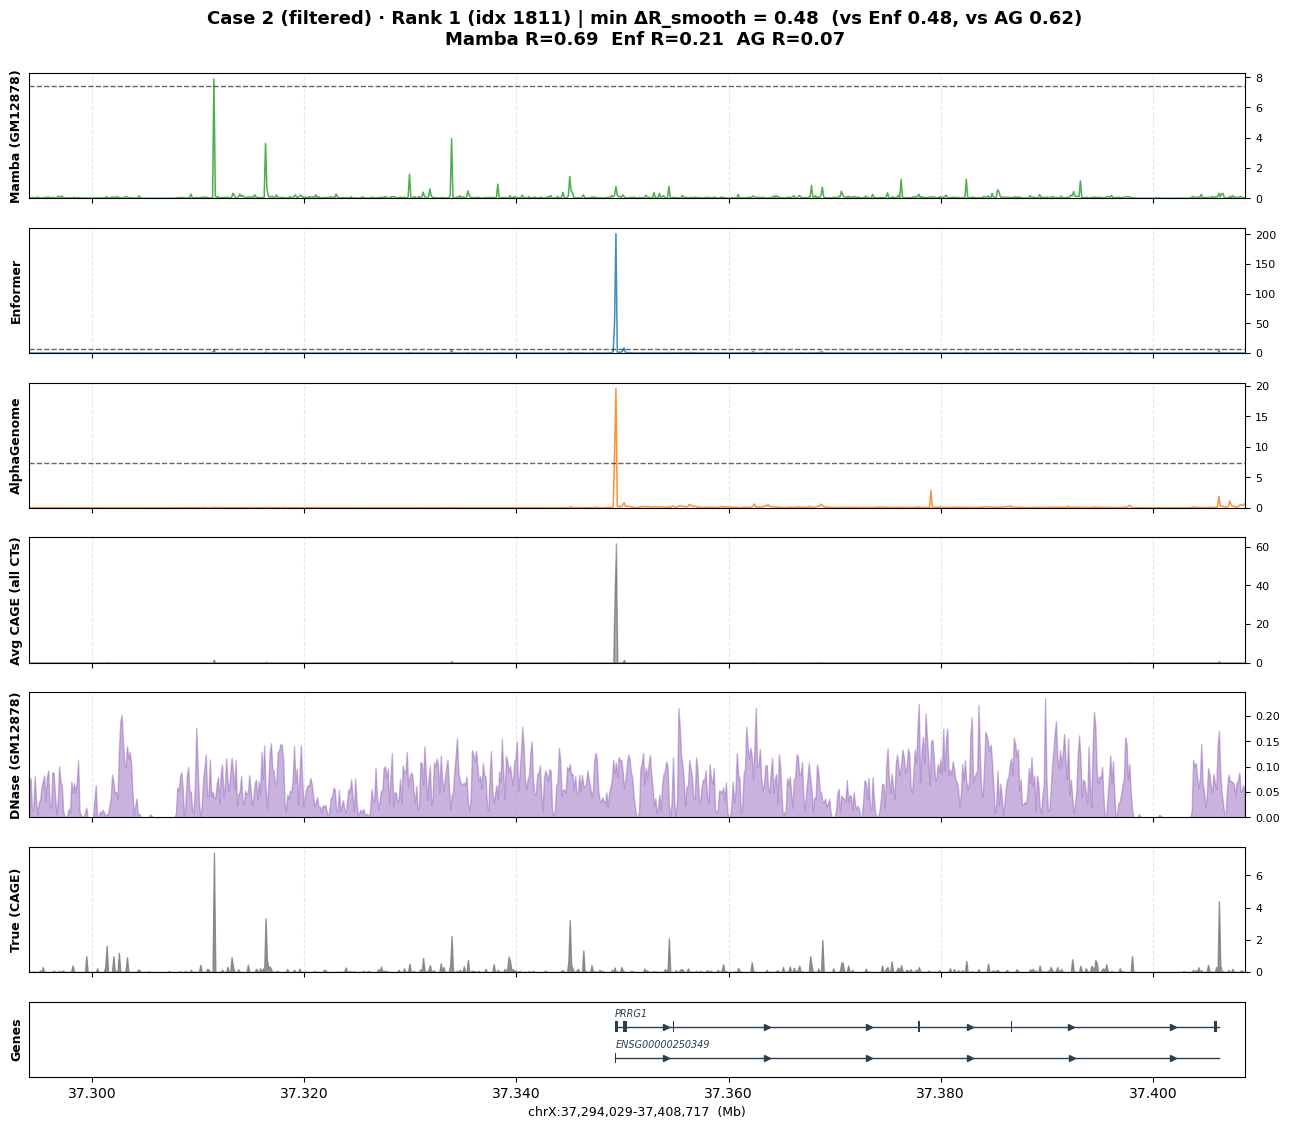

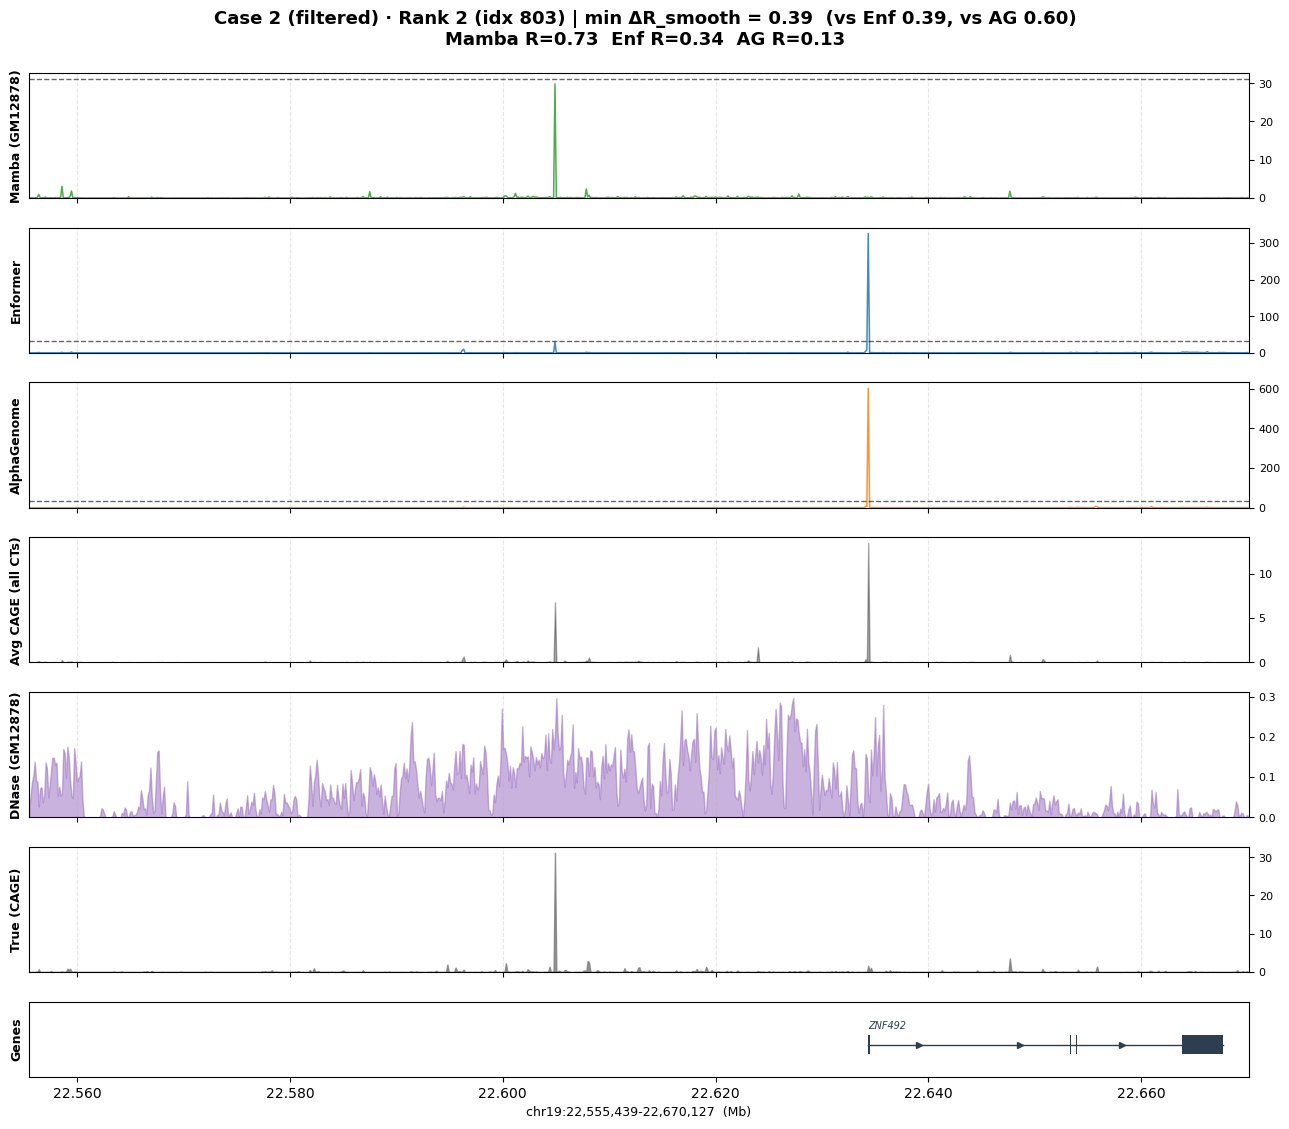

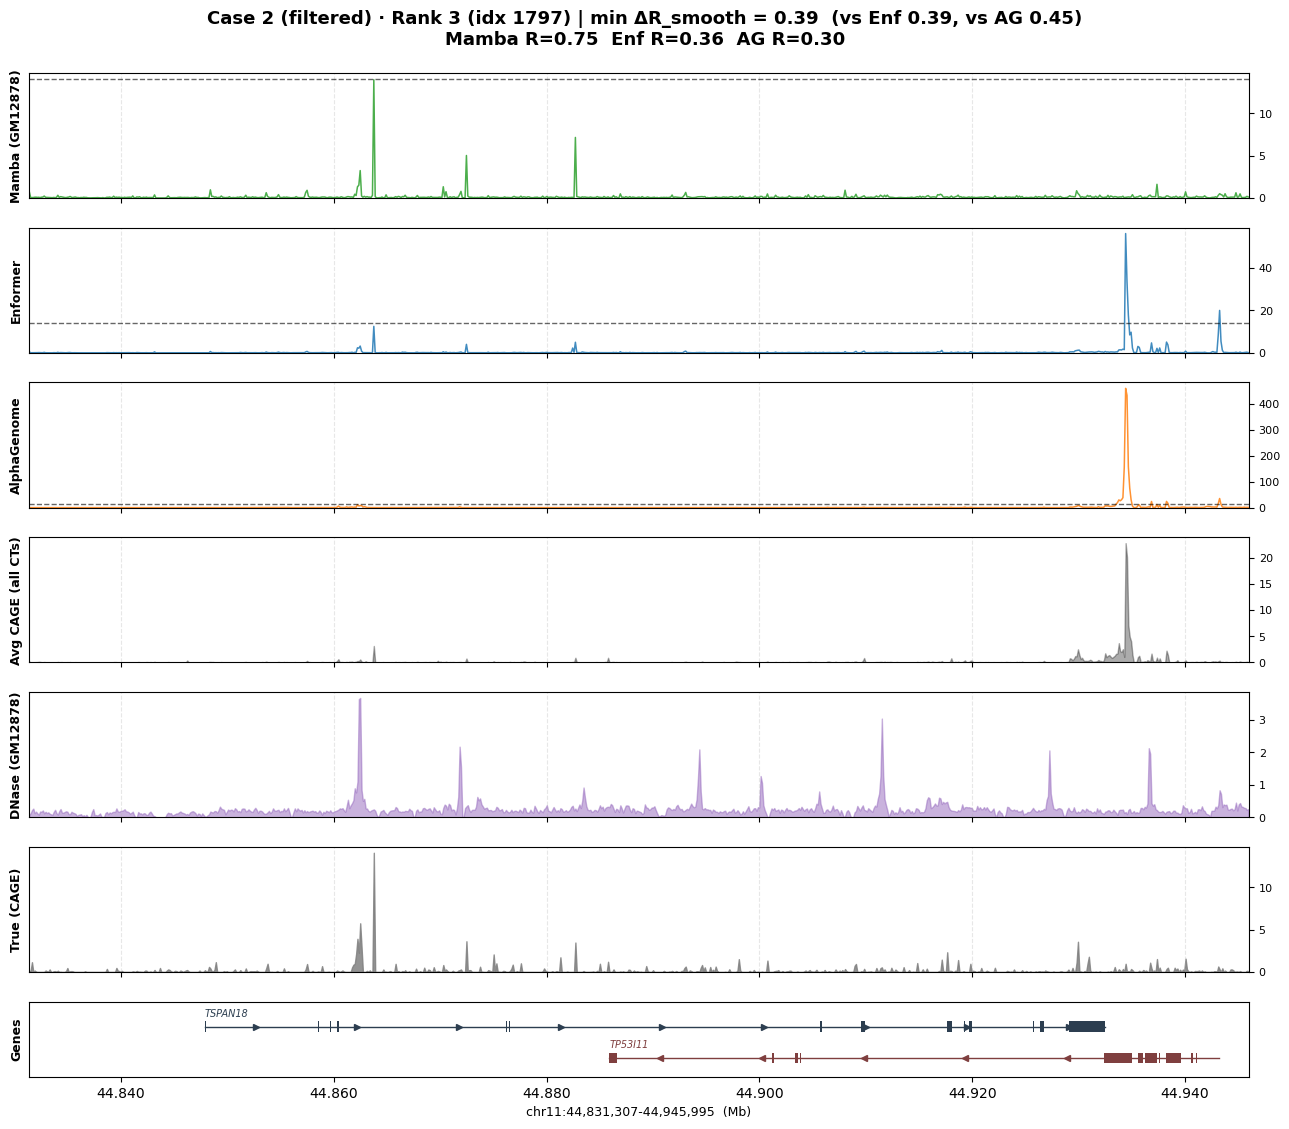

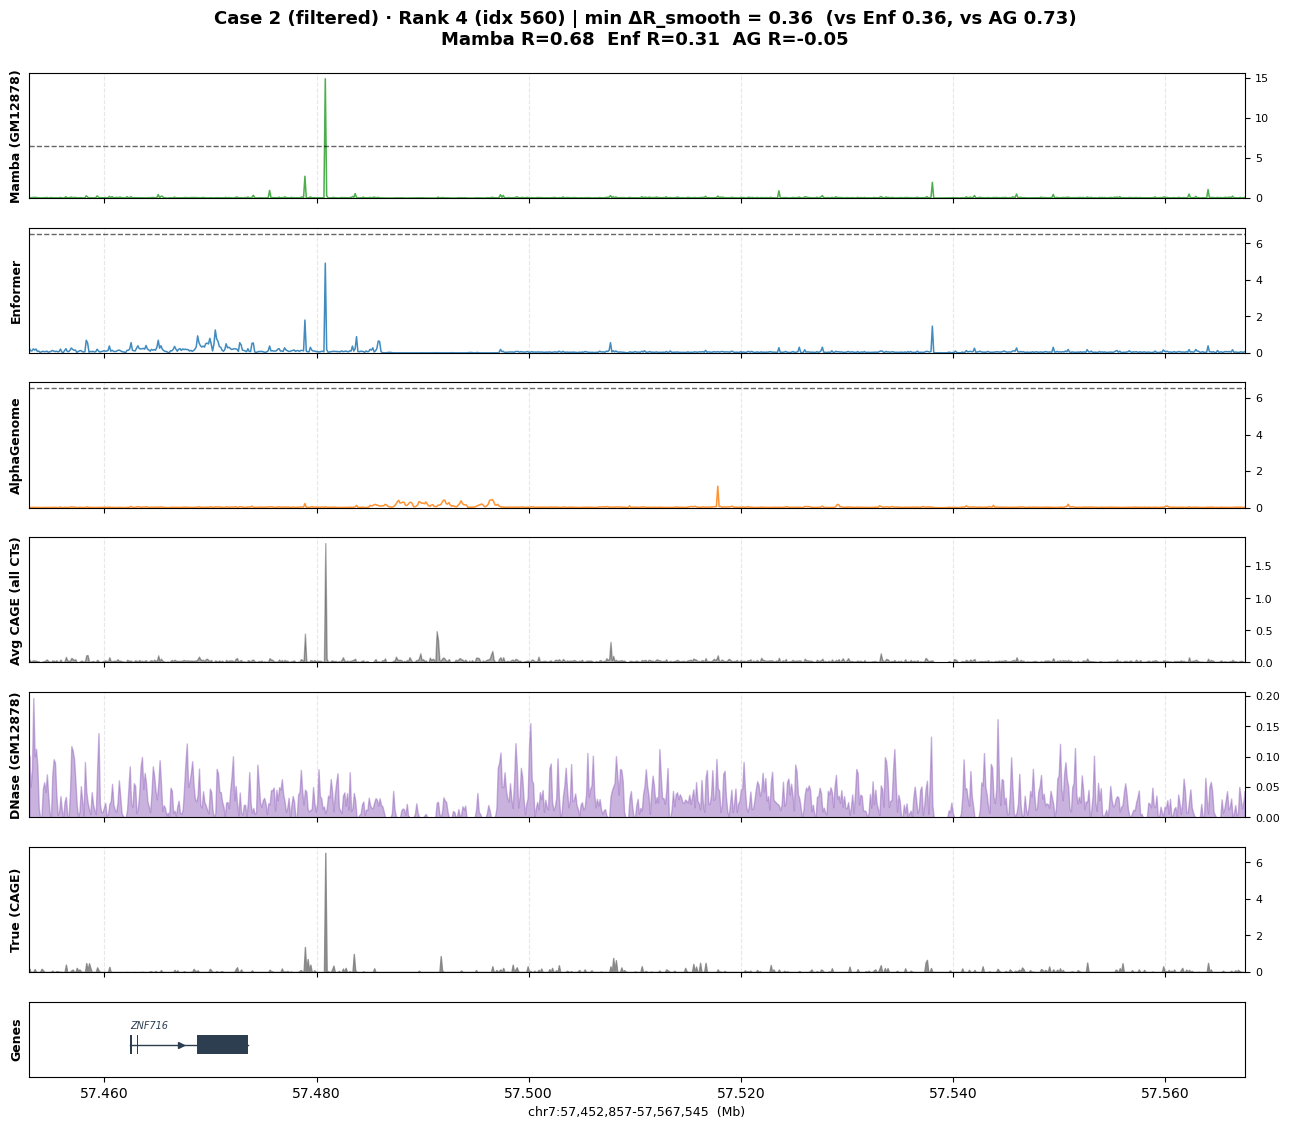

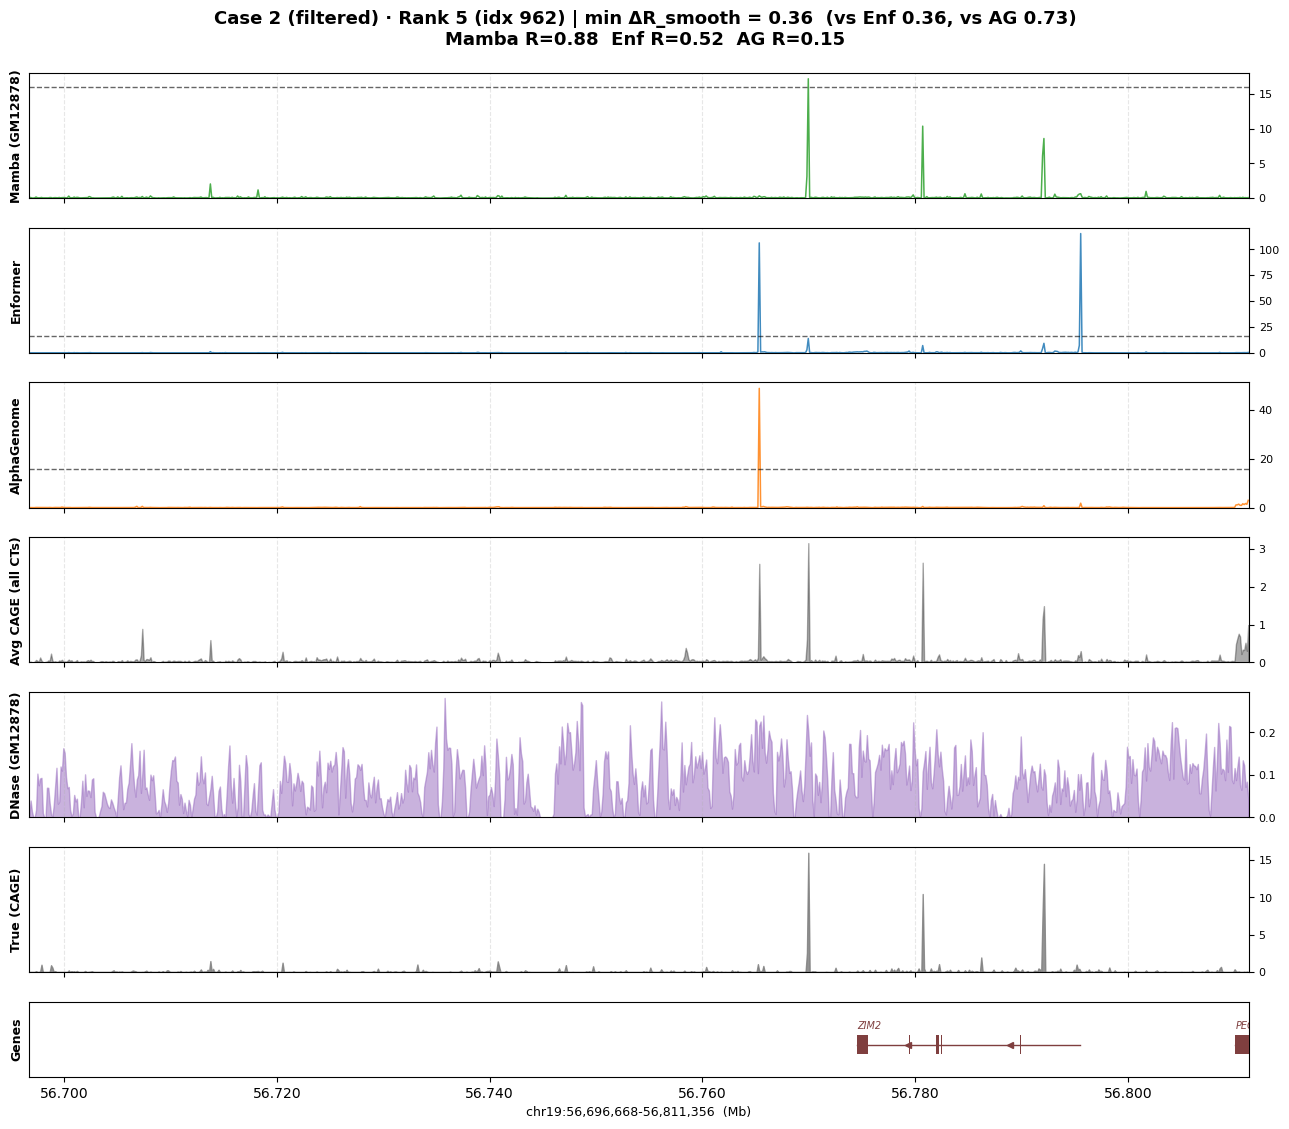

In [5]:
mamba_key    = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'
ag_key       = 'alphagenome_cage_test_128bp.npy'

delta_enf  = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag   = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_both = np.minimum(delta_enf, delta_ag)
top = top_allowed(delta_both,n=5)

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, enformer_key, ag_key])
    title = (f'Case 2 (filtered) · Rank {rank+1} (idx {idx}) | min \u0394R_smooth = {delta_both[idx]:.2f}  '
             f'(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n'
             f'Mamba R={r(mamba_key, idx):.2f}  Enf R={r(enformer_key, idx):.2f}  AG R={r(ag_key, idx):.2f}')
    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title)
    plt.show()

## 8. Case 2 (filtered) with Mamba (immune) added

Same regions and ranking as §7 (GM12878 Mamba beats both Enformer and AlphaGenome), but the
immune-cell-types Mamba model (`immune_CAGE_predictions.npy`) is added as an extra track, to
see whether it also avoids the generic false peaks.

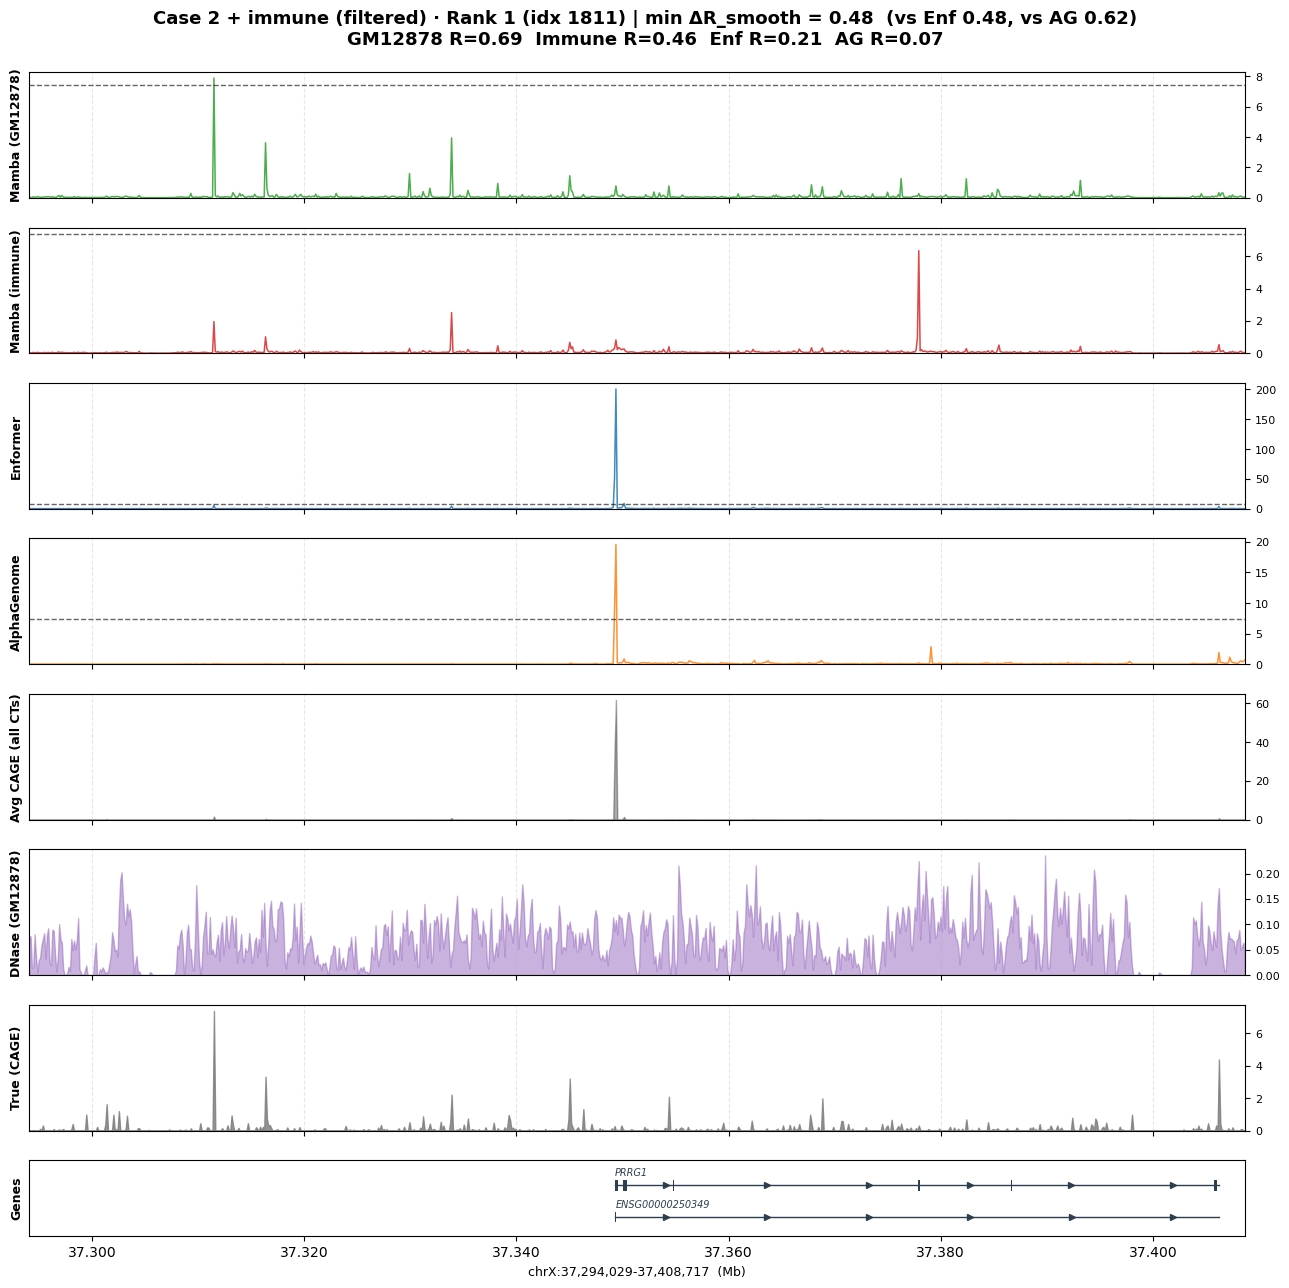

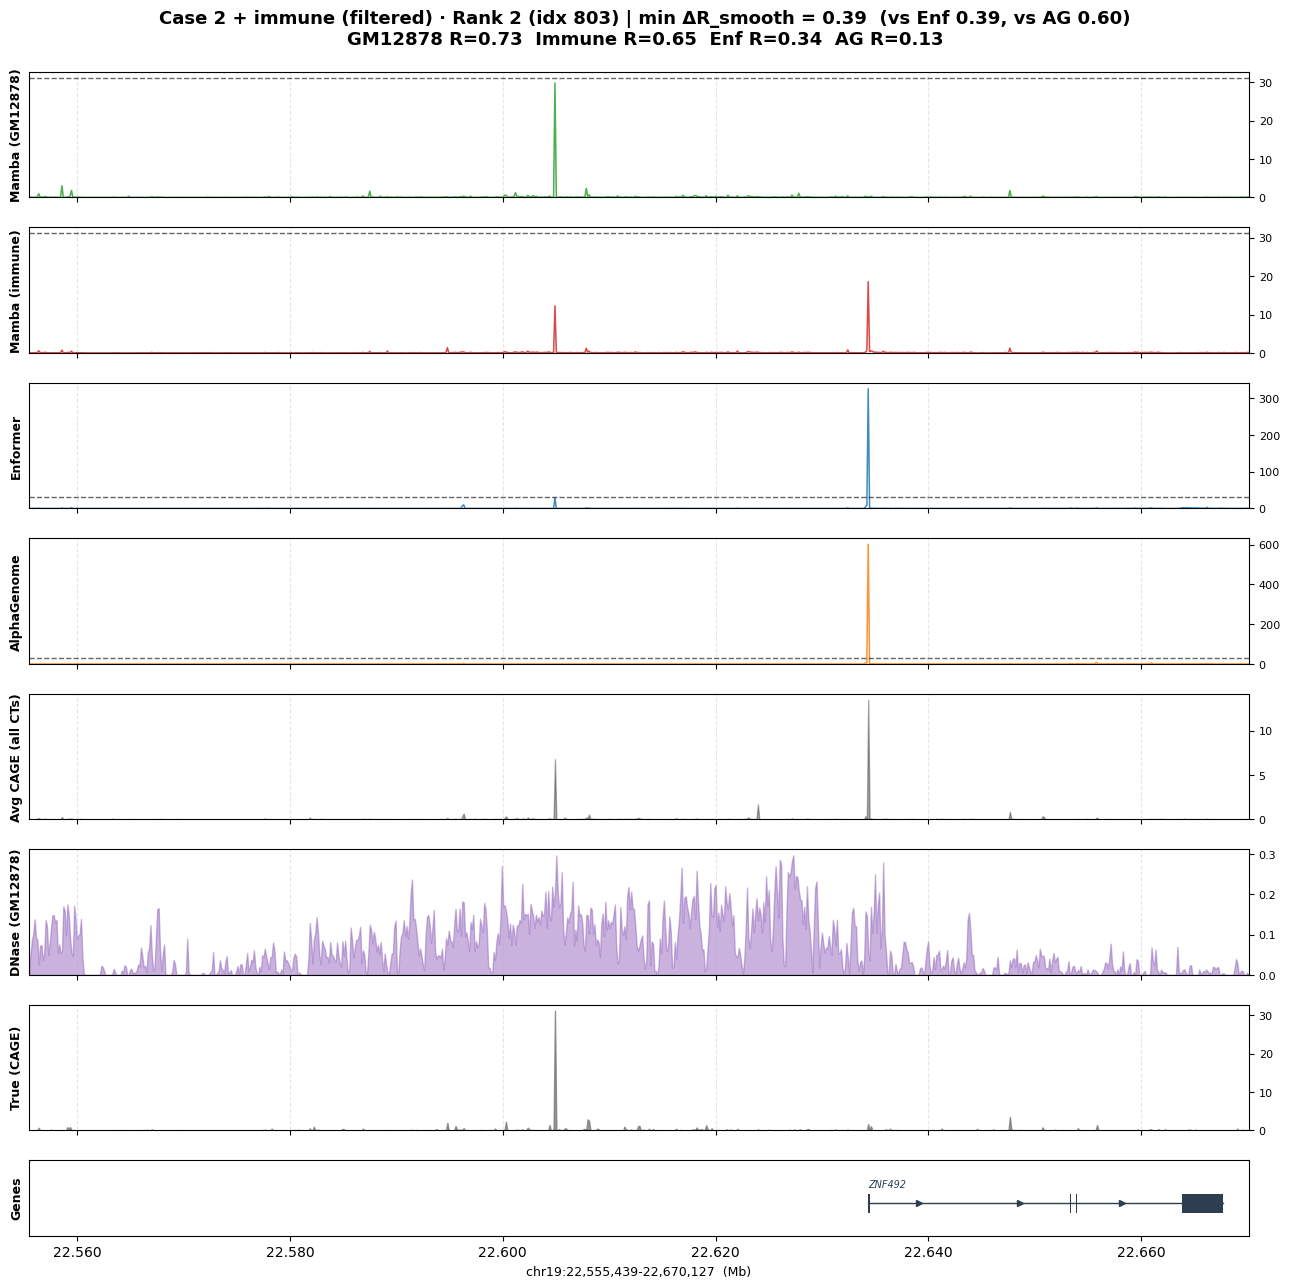

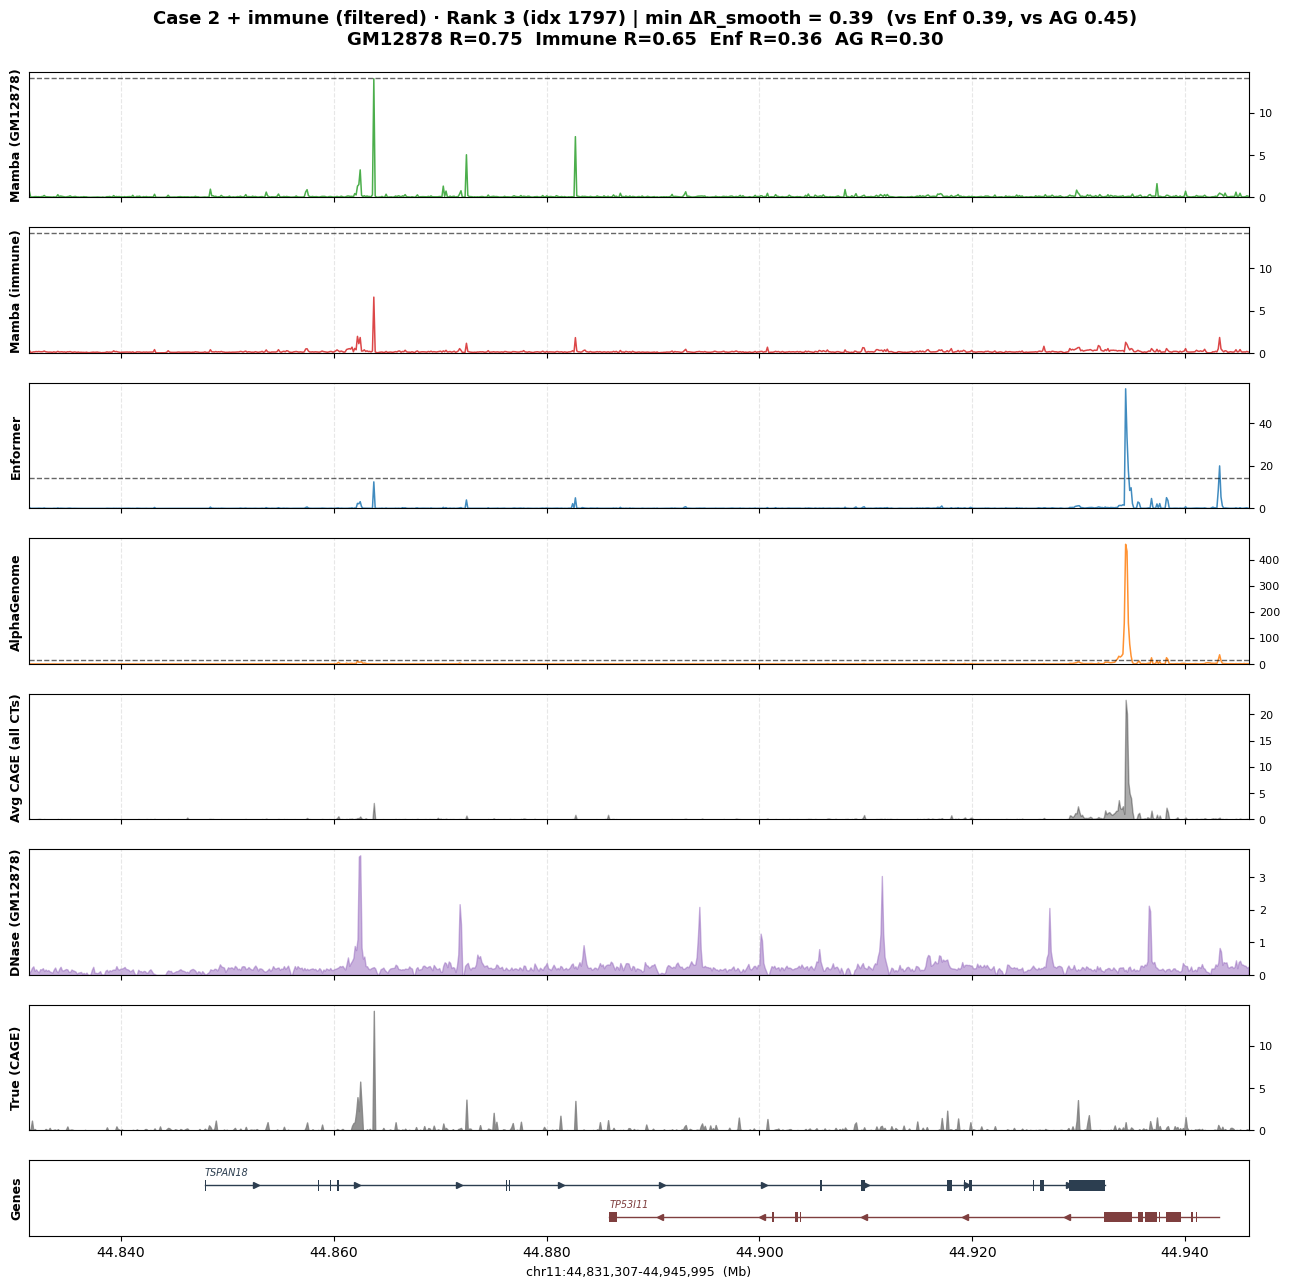

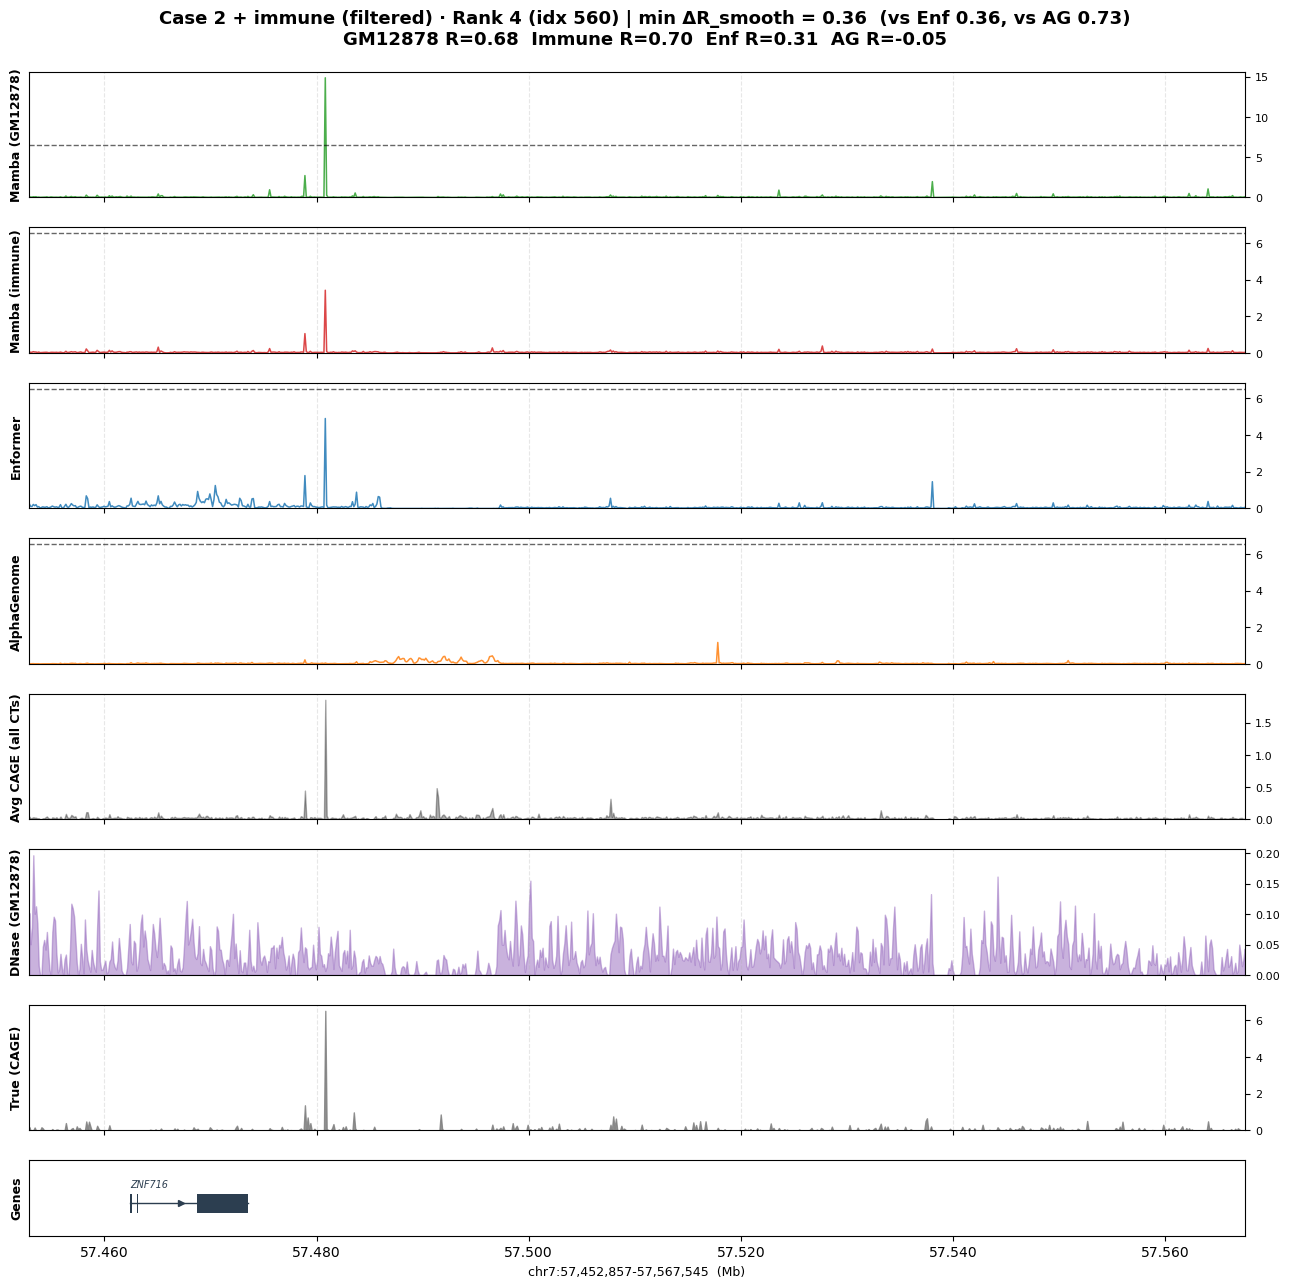

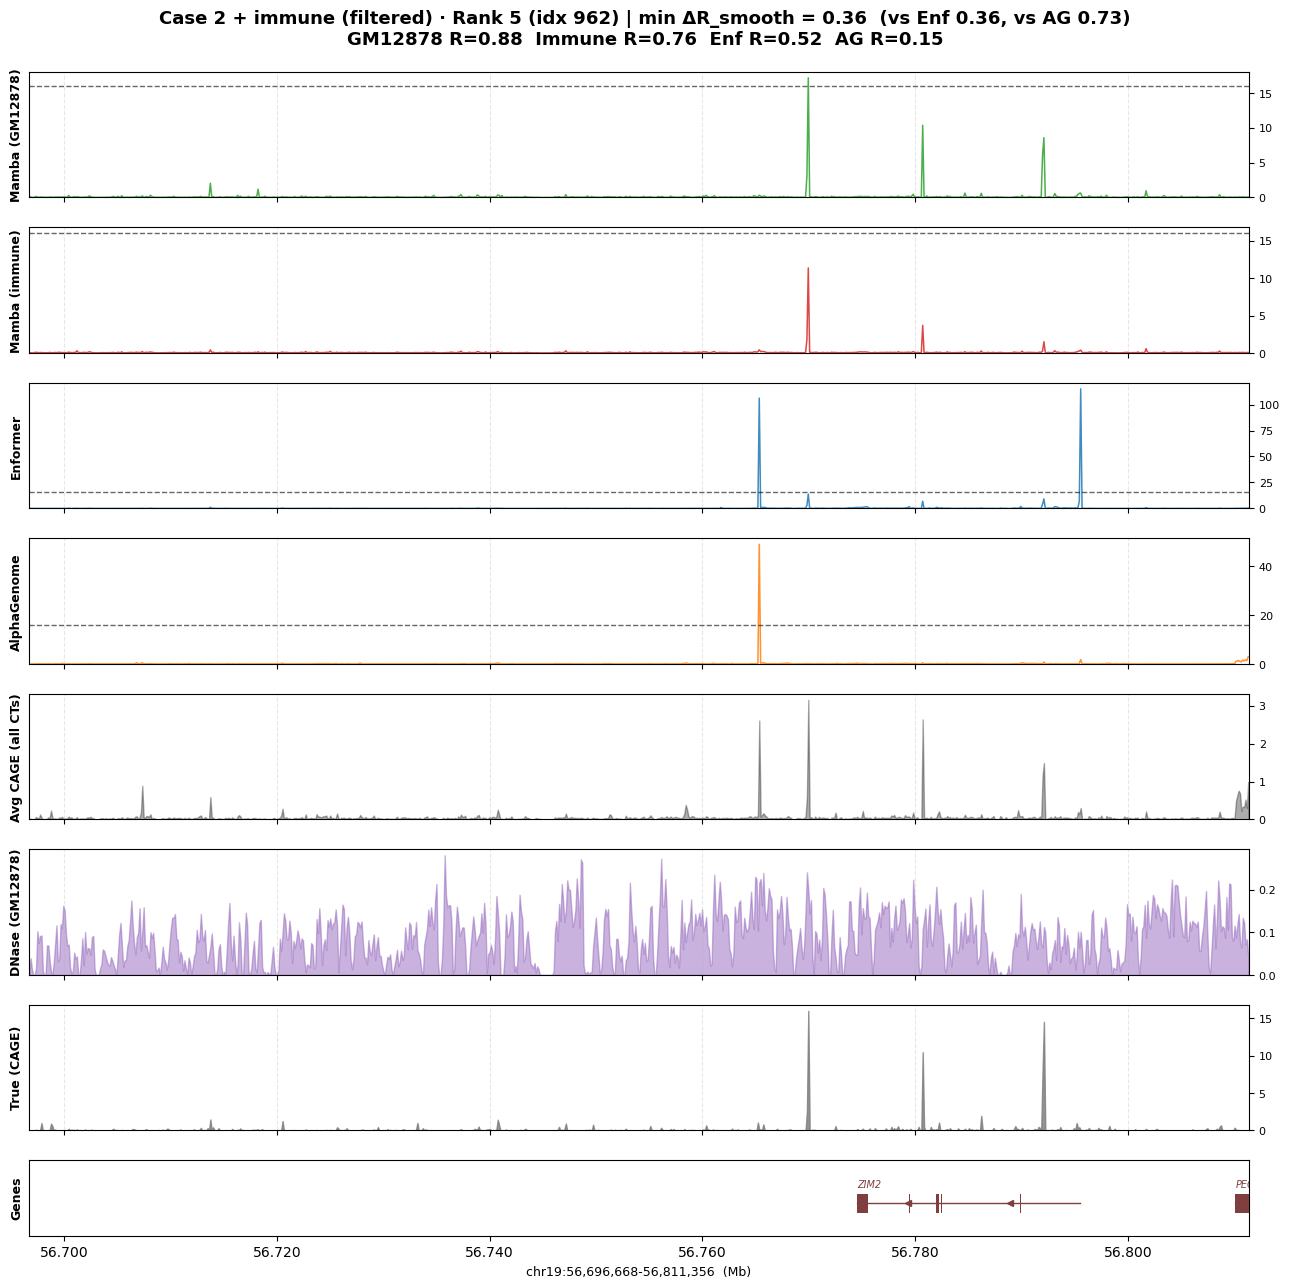

In [4]:
mamba_key    = 'GM12878_no_mlm_predictions.npy'
immune_key   = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'
ag_key       = 'alphagenome_cage_test_128bp.npy'

delta_enf  = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag   = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_both = np.minimum(delta_enf, delta_ag)
top = top_allowed(delta_both, n=5)

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, immune_key, enformer_key, ag_key])
    title = (f'Case 2 + immune (filtered) \u00b7 Rank {rank+1} (idx {idx}) | min \u0394R_smooth = {delta_both[idx]:.2f}  '
             f'(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n'
             f'GM12878 R={r(mamba_key, idx):.2f}  Immune R={r(immune_key, idx):.2f}  '
             f'Enf R={r(enformer_key, idx):.2f}  AG R={r(ag_key, idx):.2f}')
    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title)
    plt.show()

## 9. Case 1 (blacklist-filtered) — Mamba beats Enformer

Same ranking as Case 1, but only over non-blacklisted test regions.

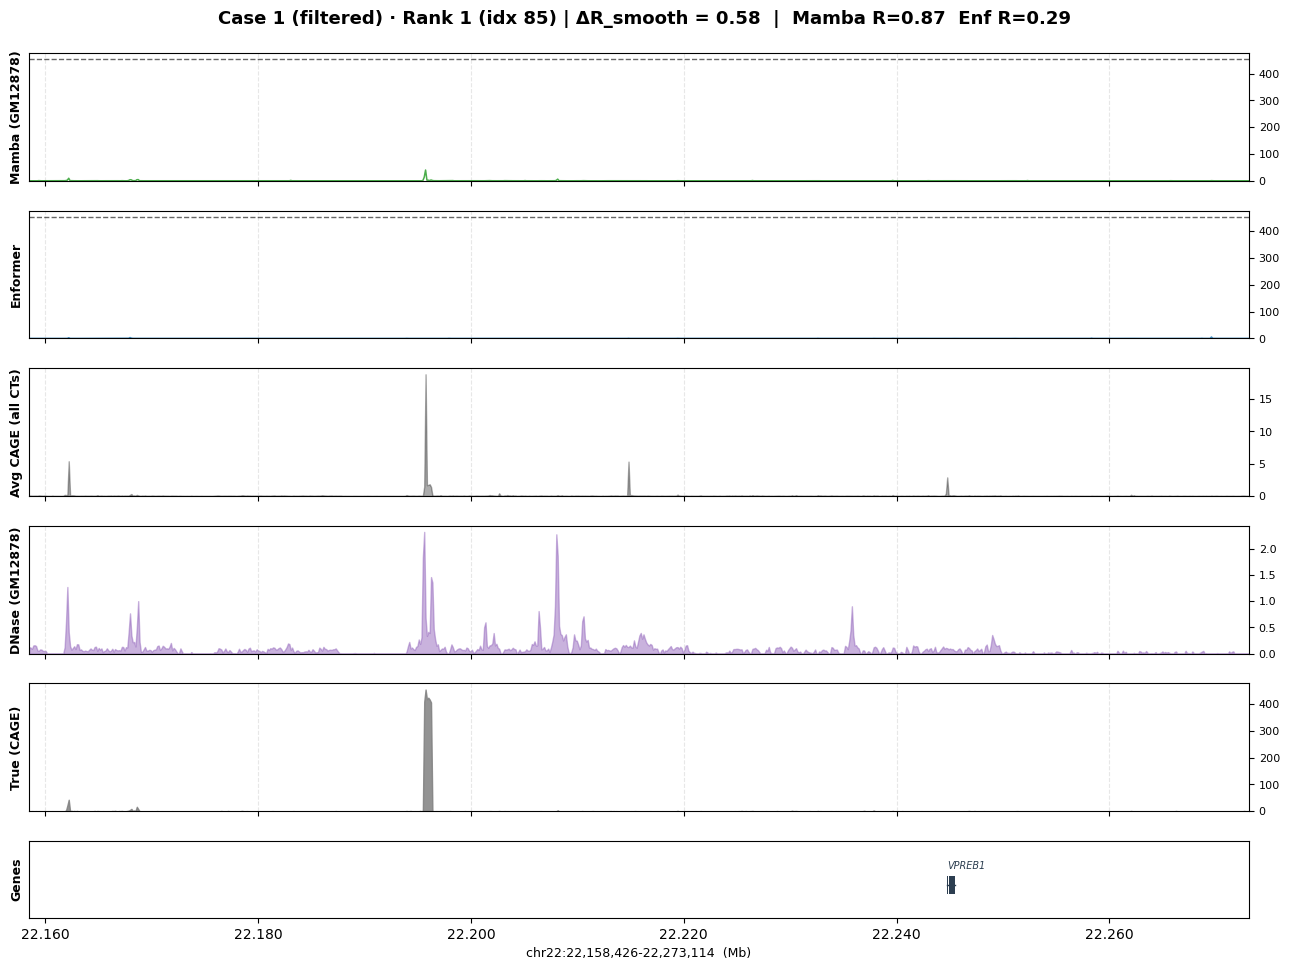

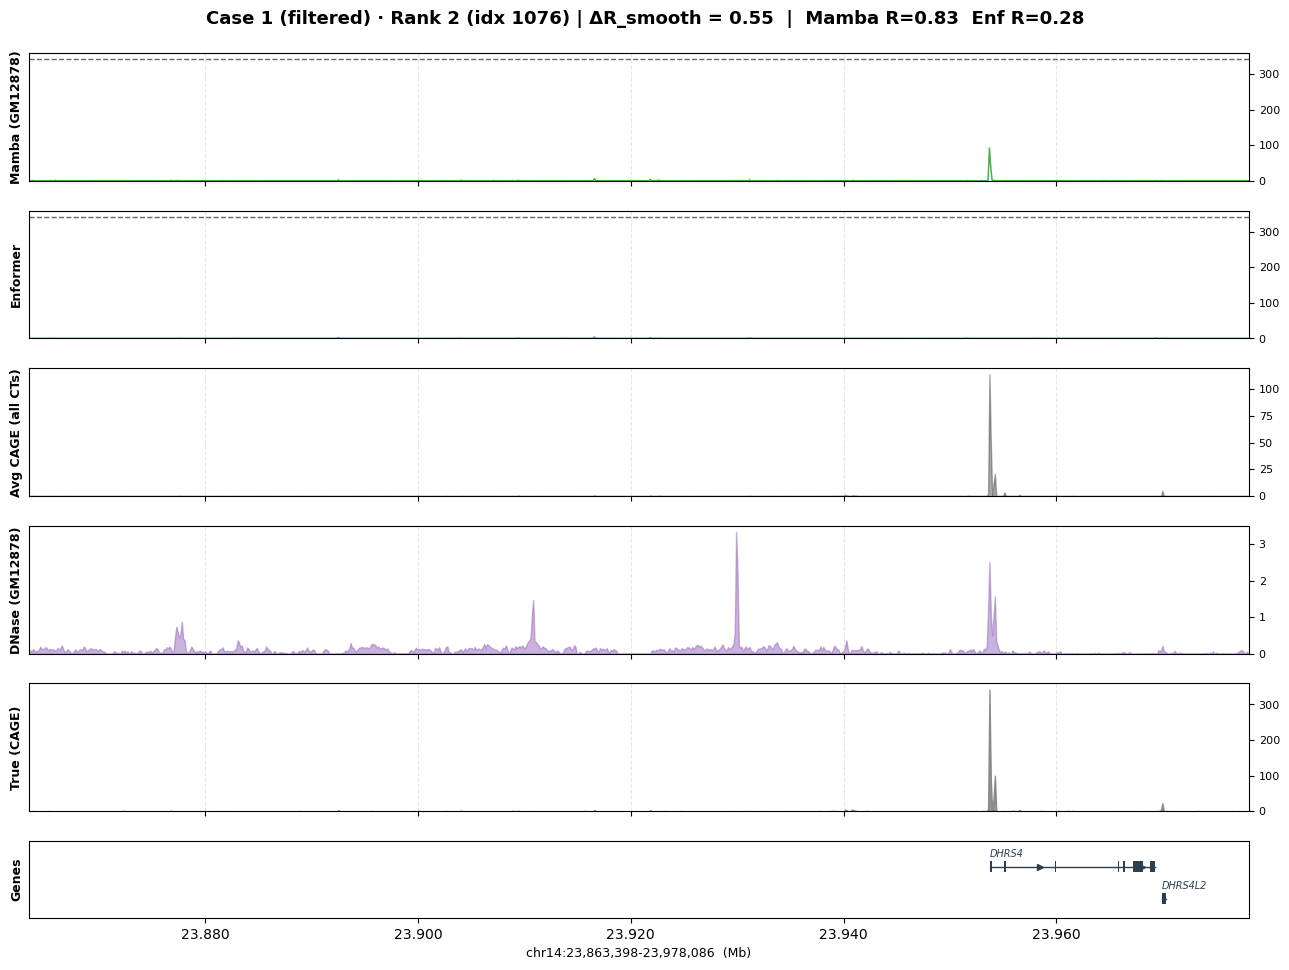

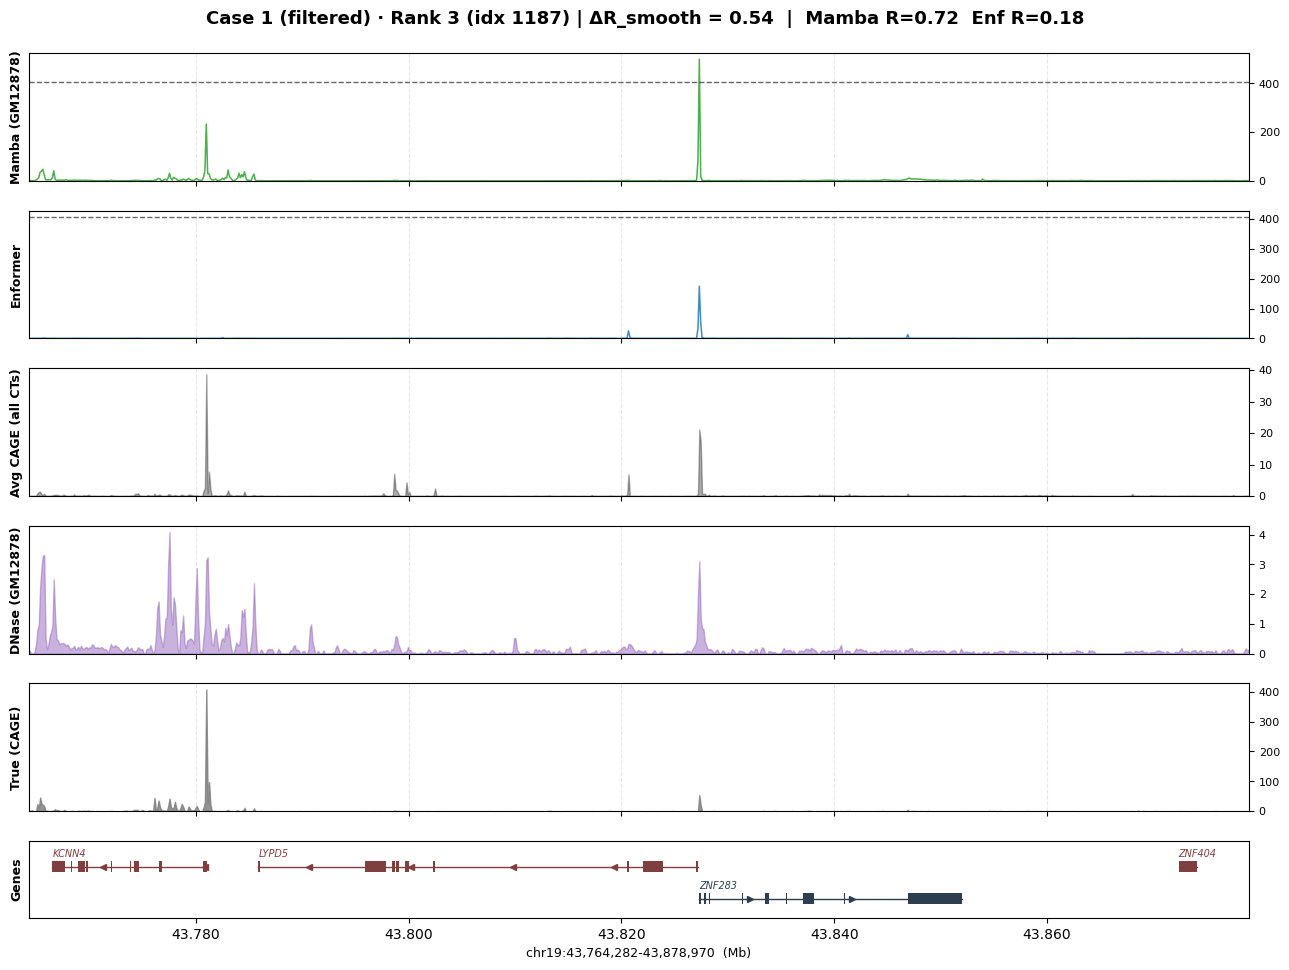

In [4]:
mamba_key    = 'GM12878_no_mlm_predictions.npy'
enformer_key = 'enformer'

delta = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
top = top_allowed(delta)

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, enformer_key])
    title = (f'Case 1 (filtered) · Rank {rank+1} (idx {idx}) | \u0394R_smooth = {delta[idx]:.2f}  '
             f'|  Mamba R={r(mamba_key, idx):.2f}  Enf R={r(enformer_key, idx):.2f}')
    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title)
    plt.show()

## 10. Case 2 (filtered) + immune, with a FANTOM5 enhancer track

Identical regions, ranking and tracks as §8, plus a **FANTOM5 enhancer** track showing where
eRNAs may be transcribed. Each enhancer in view is drawn as a block, labelled `eRNA`, with its
**FANTOM5 CAGE score** printed above the label (block opacity scales with that score on a log
scale). Source: the hg38 reprocessed enhancer atlas, `F5.hg38.enhancers.sorted.bed`
(63,285 enhancers; Dalby, Rennie & Andersson, doi:10.5281/zenodo.556775).

**§10.0 below is a self-contained reload** — run it after a kernel restart and everything §10
needs is loaded, including the enhancer BED. Each expensive load is guarded by an
`in globals()` check, so it is a no-op for anything §18 already put in memory and is cheap to
re-run.

Two caveats on reading this track:
- The score in column 5 of the BED is a **CAGE tag-count-derived score summed over FANTOM5
  libraries**, not a raw read count from any one experiment — treat it as relative enhancer
  transcription strength, not a count comparable to the CAGE target values.
- The atlas is **pan-cell-type**: these are enhancers transcribed in *some* FANTOM5 sample, not
  necessarily in GM12878. To restrict to GM12878, filter with FANTOM5's
  `F5.hg38.enhancers.expression.usage.matrix.gz`.

Enhancers are ~300 bp in a 114,688 bp window, so blocks are widened to stay visible; the exact
coordinates are printed under each figure. Across the 1,937 test regions there are on average
2.4 enhancers per window (median 1, max 27, and 31% of windows contain none).

In [5]:
# ---------------------------------------------------------------------------------
# §10.0 — standalone reload for §10. Loads EVERYTHING the §10 plotting cell needs
# (predictions, targets, ranking metric, coordinates, DNase, avg-CAGE, gene annotation,
# blacklist, helpers, and the FANTOM5 enhancer BED) so §10 runs after a kernel restart
# without re-running §1-§5 or §18.
#
# Every expensive load is guarded by an `in globals()` check, so this cell is cheap to
# re-run and is a no-op if §18 has already been executed in this session. Function and
# constant definitions are always refreshed (they cost nothing).
# ---------------------------------------------------------------------------------
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
from matplotlib.patches import Rectangle

sys.path.insert(0, '/data1/lesliec/sarthak/caduceus')
from evals.plotting_utils import Track, GeneAnnotation, plot_tracks

MODEL_OUT = '/data1/lesliec/sarthak/data/joint_playground/model_out'
ENFORMER_NPY = '/data1/lesliec/sarthak/data/enformer/data/model_out/enformer.npy'
BED_PATH = '/data1/lesliec/sarthak/data/DK_zarr/sequences_enformer.bed'
DNASE_PATH = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/GM12878_DNase.npz'
LABELS_ZARR = '/data1/lesliec/sarthak/data/enformer/data/labels.zarr'
ENH_BED = '/data1/lesliec/sarthak/data/references/F5.hg38.enhancers.sorted.bed'

ENFORMER_TRACK = 5110          # GM12878 CAGE in the Enformer output
ALPHAGENOME_TRACK = 156
CAGE_START = 4675              # labels.zarr CAGE block = 4675:5313 (638 experiments)
SEQ_LEN = 131072
PRED_LEN = 896 * 128           # 114688
BIN = 128
CROP = (SEQ_LEN - PRED_LEN) // 2
CONTEXT = 524288               # blacklist: model input length
HALF_CTX = CONTEXT // 2
OVERLAP_FRAC = 0.20
N_EXAMPLES = 3
ENH_COLOR = '#8c564b'

model_names = ['enformer', 'GM12878_no_mlm_predictions.npy',
               'immune_CAGE_predictions.npy', 'alphagenome_cage_test_128bp.npy']

# --- predictions + shared GM12878 CAGE target -------------------------------------
if 'preds' not in globals() or 't1' not in globals():
    enformer_full = np.load(ENFORMER_NPY, mmap_mode='r')
    preds = {}
    for m in model_names:
        if m == 'enformer':
            preds[m] = enformer_full[:, :, ENFORMER_TRACK]
        elif m == 'alphagenome_cage_test_128bp.npy':
            preds[m] = np.load(f'{MODEL_OUT}/{m}', mmap_mode='r')[:, :, ALPHAGENOME_TRACK]
        else:
            _a = np.load(f'{MODEL_OUT}/{m}')
            preds[m] = _a[:, :, 0] if _a.ndim == 3 else _a
    t1 = np.load(f'{MODEL_OUT}/GM12878_base_targets_conv.npy')
    print('loaded predictions + targets')
else:
    print('preds/t1 already in memory - skipped')

# --- ranking metric: smoothed-log Pearson (the slow part: 4 x 1937 correlations) ---
SMOOTH_SIGMA = 1.5


def smoothed_log_pearson(pred, true, sigma=SMOOTH_SIGMA):
    p = gaussian_filter1d(np.log1p(np.clip(pred, 0, None)), sigma=sigma)
    t = gaussian_filter1d(np.log1p(np.clip(true, 0, None)), sigma=sigma)
    if np.std(p) < 1e-8 or np.std(t) < 1e-8:
        return np.nan
    return pearsonr(p, t)[0]


if 'pearson_smooth_results' not in globals():
    pearson_smooth_results = {}
    for name, arr in preds.items():
        pearson_smooth_results[name] = np.array(
            [smoothed_log_pearson(arr[i], t1[i]) for i in tqdm(range(arr.shape[0]), desc=name)])
else:
    print('pearson_smooth_results already in memory - skipped')

# --- genomic coordinates of each test region's predicted window -------------------
if '_test_bed' not in globals():
    _bed = pd.read_csv(BED_PATH, sep='\t', header=None)
    _test_bed = _bed[_bed.iloc[:, -1] == 'test'].reset_index(drop=True)
    print(f'test regions: {len(_test_bed)}')
else:
    print('region BED already in memory - skipped')


def region_coords(idx):
    chrom = str(_test_bed.iloc[idx, 0])
    start = int(_test_bed.iloc[idx, 1]) + CROP
    return chrom, start, start + PRED_LEN


# --- GM12878 DNase accessibility (per-chromosome, bp resolution) ------------------
if '_dnase' not in globals():
    _dnase = np.load(DNASE_PATH)
    _dnase_cache = {}


def _dnase_chrom(c):
    if c not in _dnase_cache:
        _dnase_cache[c] = np.asarray(_dnase[c][0], dtype=np.float32)
    return _dnase_cache[c]


def dnase_profile(idx):
    c, s, e = region_coords(idx)
    seg = _dnase_chrom(c)[s:e]
    if len(seg) < PRED_LEN:
        seg = np.pad(seg, (0, PRED_LEN - len(seg)))
    return seg[:PRED_LEN].reshape(896, BIN).mean(axis=1)


# --- average CAGE across ALL cell types ("generic" expression) --------------------
if '_labels_test' not in globals():
    _labels_test = zarr.open(LABELS_ZARR, mode='r')['test']


def avg_cage_profile(idx):
    return np.asarray(_labels_test[idx, :, CAGE_START:]).mean(axis=1)


# --- gene annotation (GENCODE v49; parquet cache) ---------------------------------
if 'ann' not in globals():
    ann = GeneAnnotation()
    print('annotation rows:', len(ann.df))
else:
    print('gene annotation already in memory - skipped')

# --- blacklist: extended-524288 train windows overlapping >20% of a test region ---
if 'allowed' not in globals():
    if '_bed' not in globals():
        _bed = pd.read_csv(BED_PATH, sep='\t', header=None)
    _split_col = _bed.shape[1] - 1
    _train_by_chrom = {}
    for chrom, g in _bed[_bed[_split_col] == 'train'].groupby(0):
        ts = g[1].astype(int).to_numpy()
        te2 = g[2].astype(int).to_numpy()
        ce = (ts + te2) // 2
        _train_by_chrom[str(chrom)] = (ce - HALF_CTX, ce + HALF_CTX)
    blacklisted = np.zeros(len(_test_bed), dtype=bool)
    for i in range(len(_test_bed)):
        chrom = str(_test_bed.iloc[i, 0])
        c = int(_test_bed.iloc[i, 1])
        d = int(_test_bed.iloc[i, 2])
        if chrom not in _train_by_chrom:
            continue
        a, b = _train_by_chrom[chrom]
        ov = np.maximum(0, np.minimum(b, d) - np.maximum(a, c))
        if np.any(ov > OVERLAP_FRAC * (d - c)):
            blacklisted[i] = True
    allowed = ~blacklisted
    print(f'Blacklisted {blacklisted.sum()} / {len(blacklisted)} test regions; '
          f'{allowed.sum()} allowed')
else:
    print('blacklist already in memory - skipped')


# --- selection + styling helpers ---------------------------------------------------
def top_allowed(score, n=None):
    n = n or N_EXAMPLES
    ranked = np.where(np.isnan(score) | ~allowed, -np.inf, score)
    return np.argsort(ranked)[-n:][::-1]


def r(key, idx):
    return pearson_smooth_results[key][idx]


COLORS = {'GM12878_no_mlm_predictions.npy': '#2ca02c', 'enformer': '#1f77b4',
          'alphagenome_cage_test_128bp.npy': '#ff7f0e', 'immune_CAGE_predictions.npy': '#d62728'}
PRETTY = {'GM12878_no_mlm_predictions.npy': 'Mamba (GM12878)', 'enformer': 'Enformer',
          'alphagenome_cage_test_128bp.npy': 'AlphaGenome', 'immune_CAGE_predictions.npy': 'Mamba (immune)'}


def make_tracks(idx, model_keys, add_avg=True, add_dnase=True):
    chrom, start, end = region_coords(idx)
    common = dict(chrom=chrom, start=start, bin_size=BIN)
    tracks = [Track(np.asarray(preds[k][idx]), name=PRETTY[k], color=COLORS[k], **common)
              for k in model_keys]
    if add_avg:   # generic cross-cell-type expression (own scale via reference_exempt)
        tracks.append(Track(avg_cage_profile(idx), name='Avg CAGE (all CTs)', color='#111111',
                            style='fill', alpha=0.35, reference_exempt=True, **common))
    if add_dnase:
        tracks.append(Track(dnase_profile(idx), name='DNase (GM12878)', color='#9467bd',
                            style='fill', alpha=0.5, reference_exempt=True, **common))
    truth = Track(np.asarray(t1[idx]), name='True (CAGE)', is_truth=True, **common)
    return tracks, truth, (chrom, start, end)


# --- FANTOM5 enhancer atlas (hg38 reprocessed set) --------------------------------
if '_enh_by_chrom' not in globals():
    _enh = pd.read_csv(ENH_BED, sep='\t', header=None, usecols=[0, 1, 2, 4],
                       names=['chrom', 'start', 'end', 'score'])
    _enh_by_chrom = {c: (g['start'].to_numpy(), g['end'].to_numpy(), g['score'].to_numpy())
                     for c, g in _enh.groupby('chrom')}
    print(f'FANTOM5 enhancers: {len(_enh):,} across {len(_enh_by_chrom)} chromosomes')
else:
    print('FANTOM5 enhancer BED already in memory - skipped')

print('\n§10.0 reload complete - §10 below is ready to run.')

preds/t1 already in memory - skipped
pearson_smooth_results already in memory - skipped
region BED already in memory - skipped
gene annotation already in memory - skipped
blacklist already in memory - skipped
FANTOM5 enhancer BED already in memory - skipped

§10.0 reload complete - §10 below is ready to run.


rank 1 (idx 1811)  chrX:37,294,029-37,408,717  -> 1 FANTOM5 enhancer(s)
    chrX:37,349,833-37,350,173  (340 bp)  score=62


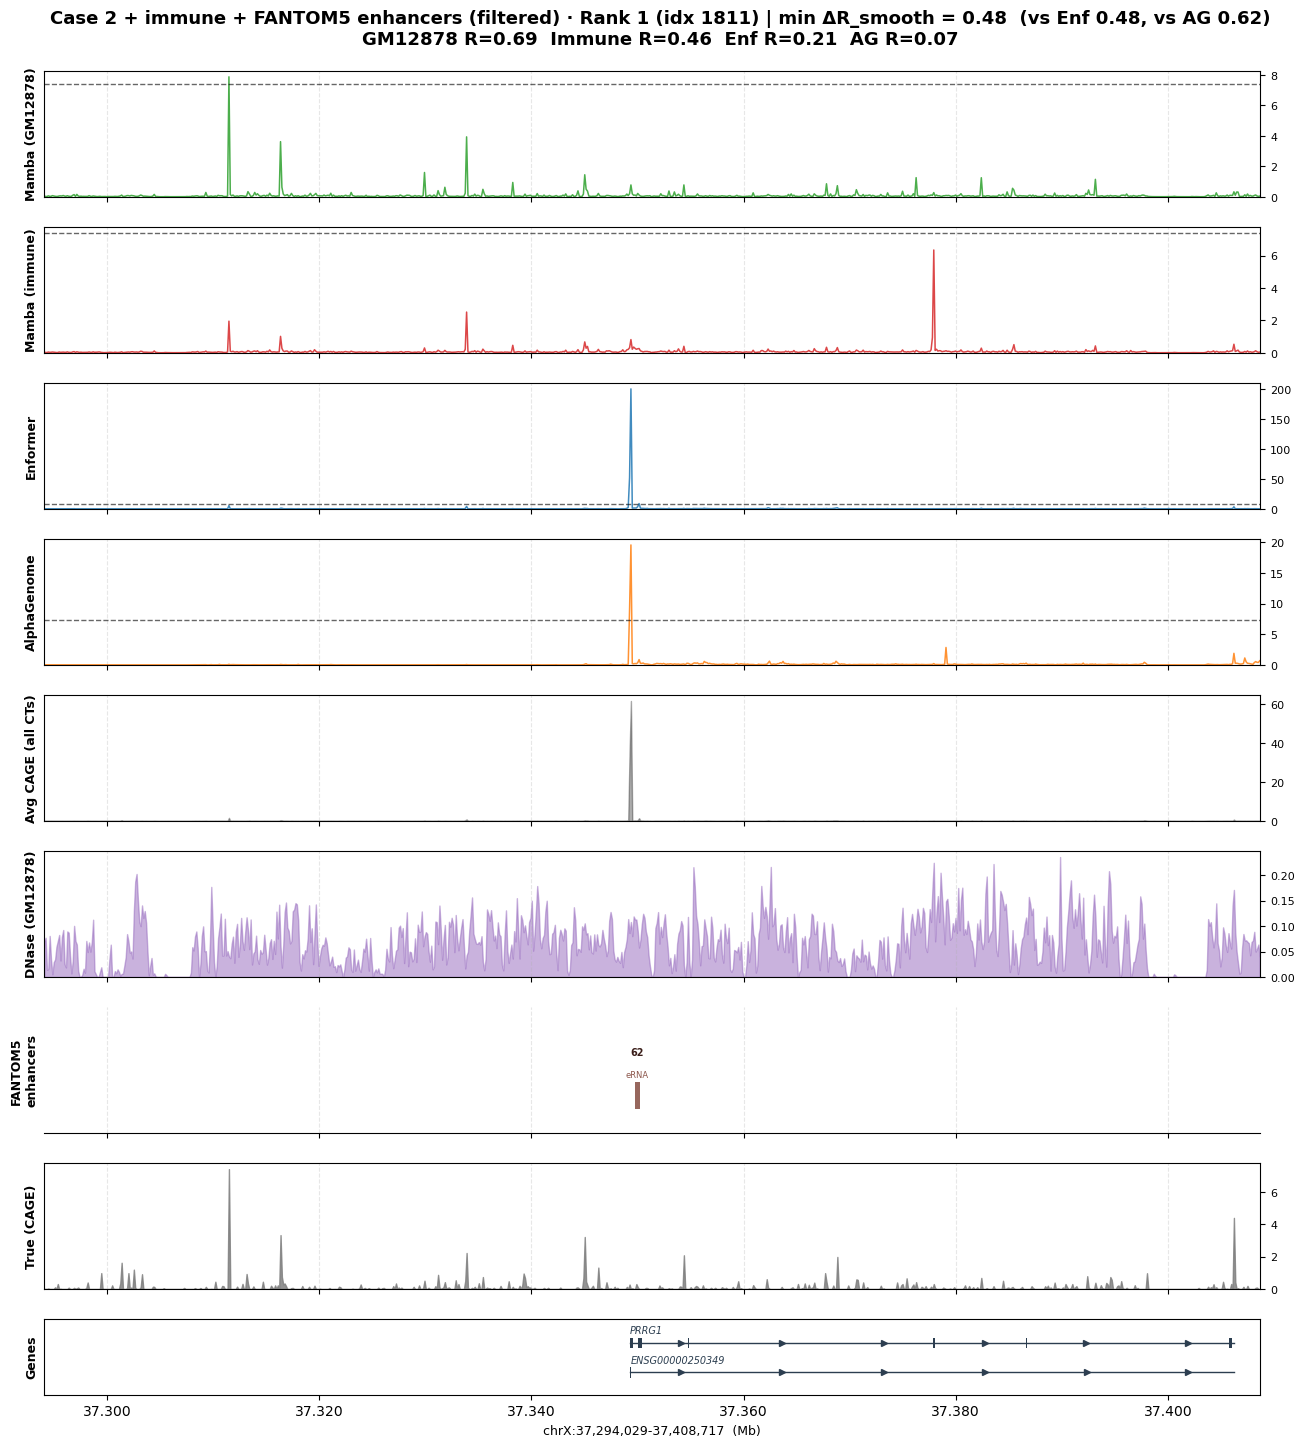

rank 2 (idx 803)  chr19:22,555,439-22,670,127  -> 0 FANTOM5 enhancer(s)


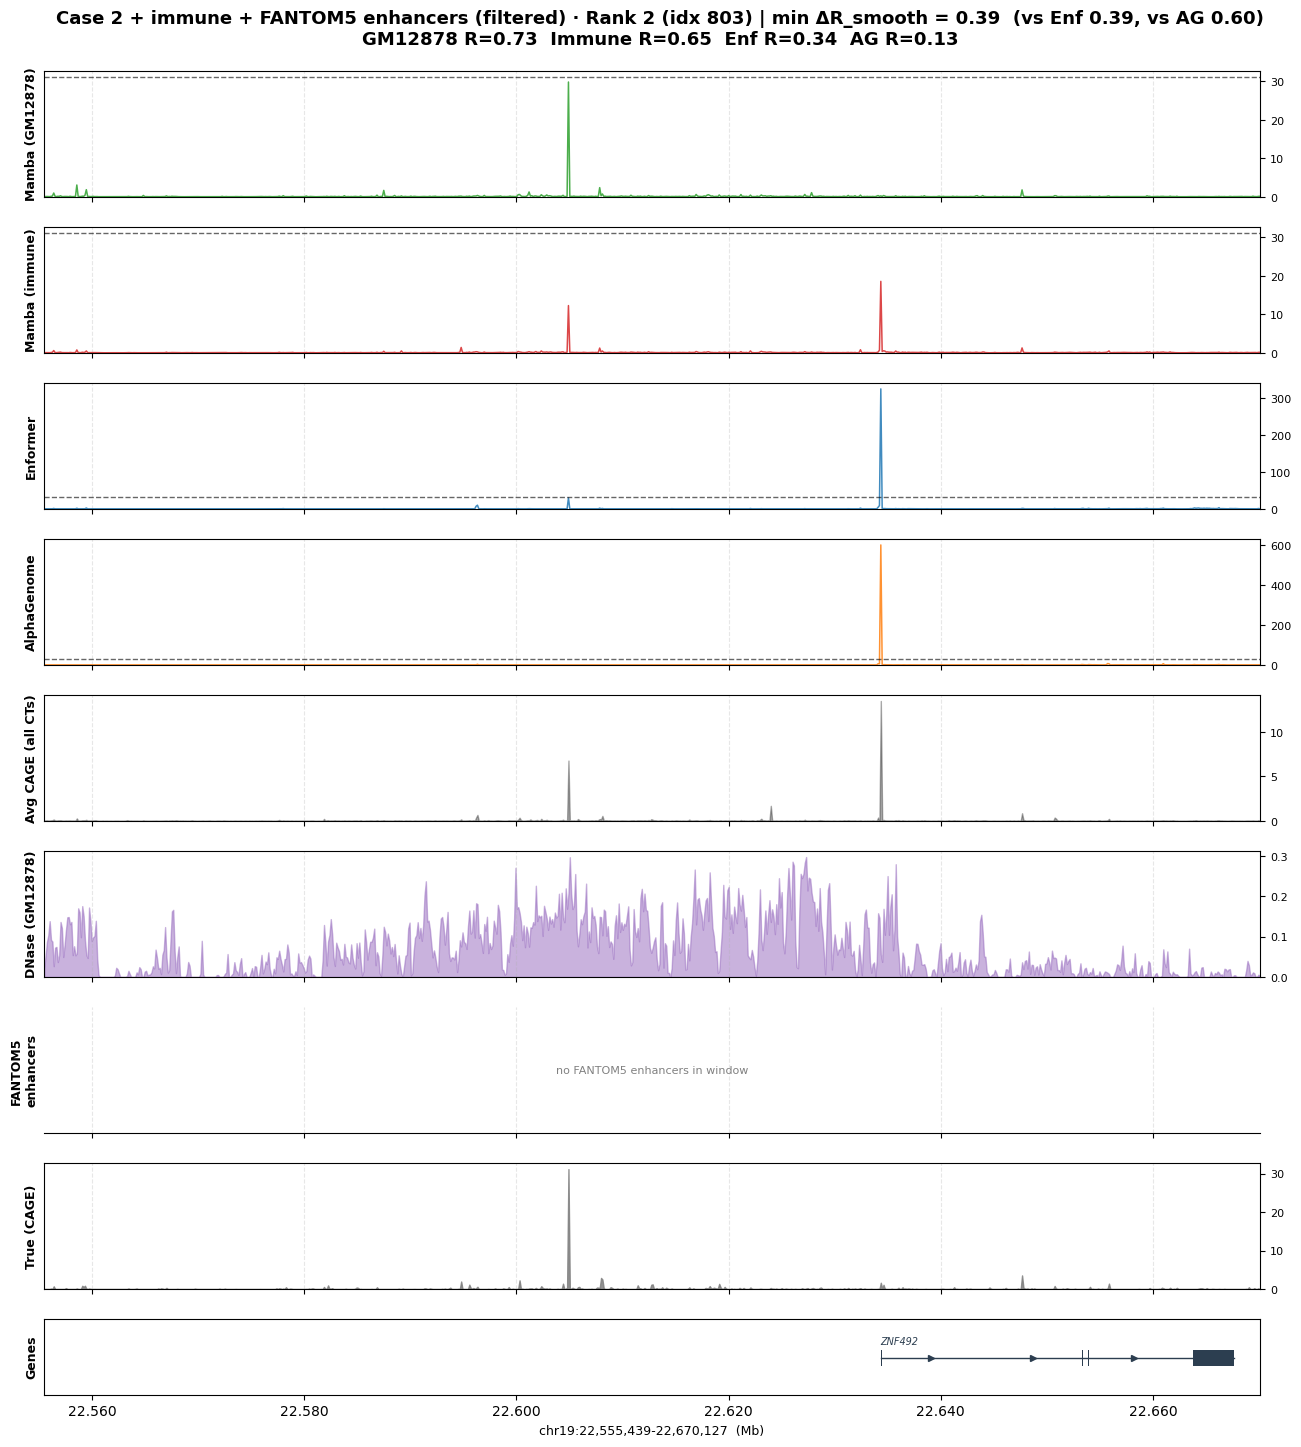

rank 3 (idx 1797)  chr11:44,831,307-44,945,995  -> 5 FANTOM5 enhancer(s)
    chr11:44,861,229-44,861,483  (254 bp)  score=22
    chr11:44,862,258-44,862,617  (359 bp)  score=198
    chr11:44,863,385-44,863,576  (191 bp)  score=9
    chr11:44,916,812-44,917,035  (223 bp)  score=7
    chr11:44,941,646-44,941,931  (285 bp)  score=4


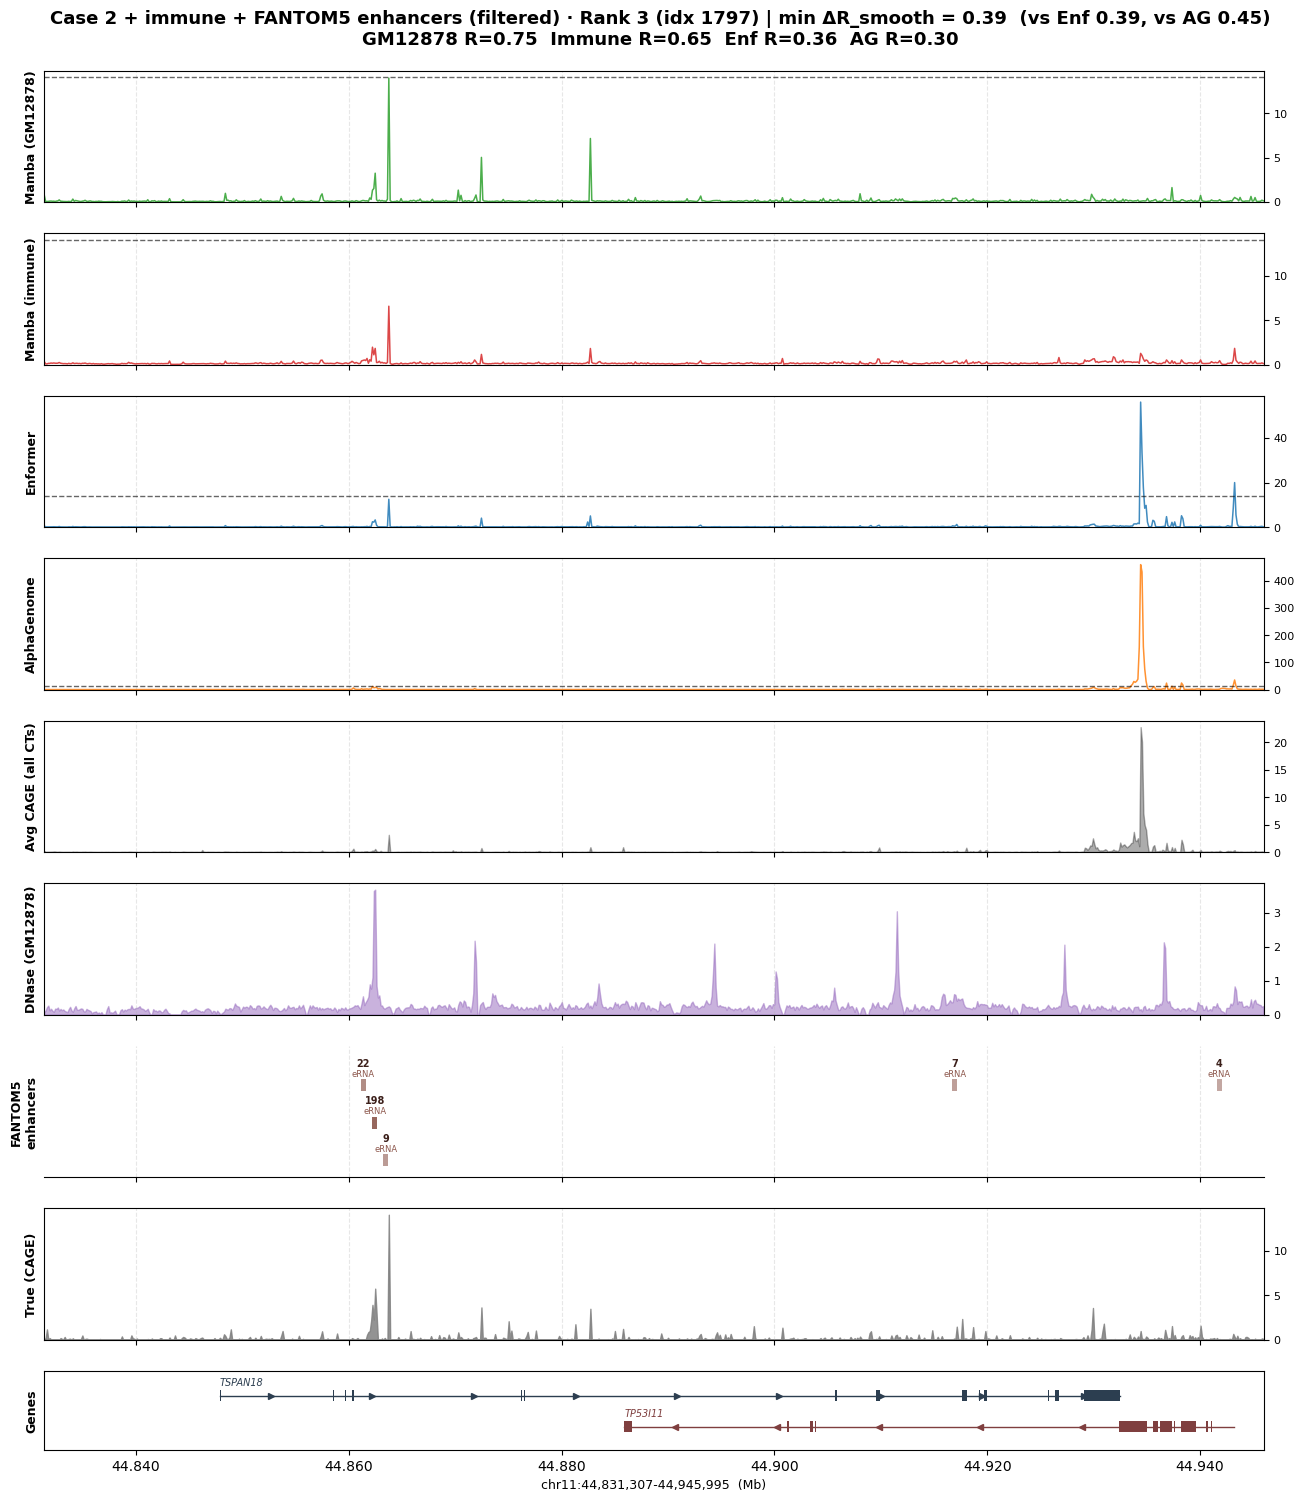

rank 4 (idx 560)  chr7:57,452,857-57,567,545  -> 1 FANTOM5 enhancer(s)
    chr7:57,517,846-57,518,077  (231 bp)  score=4


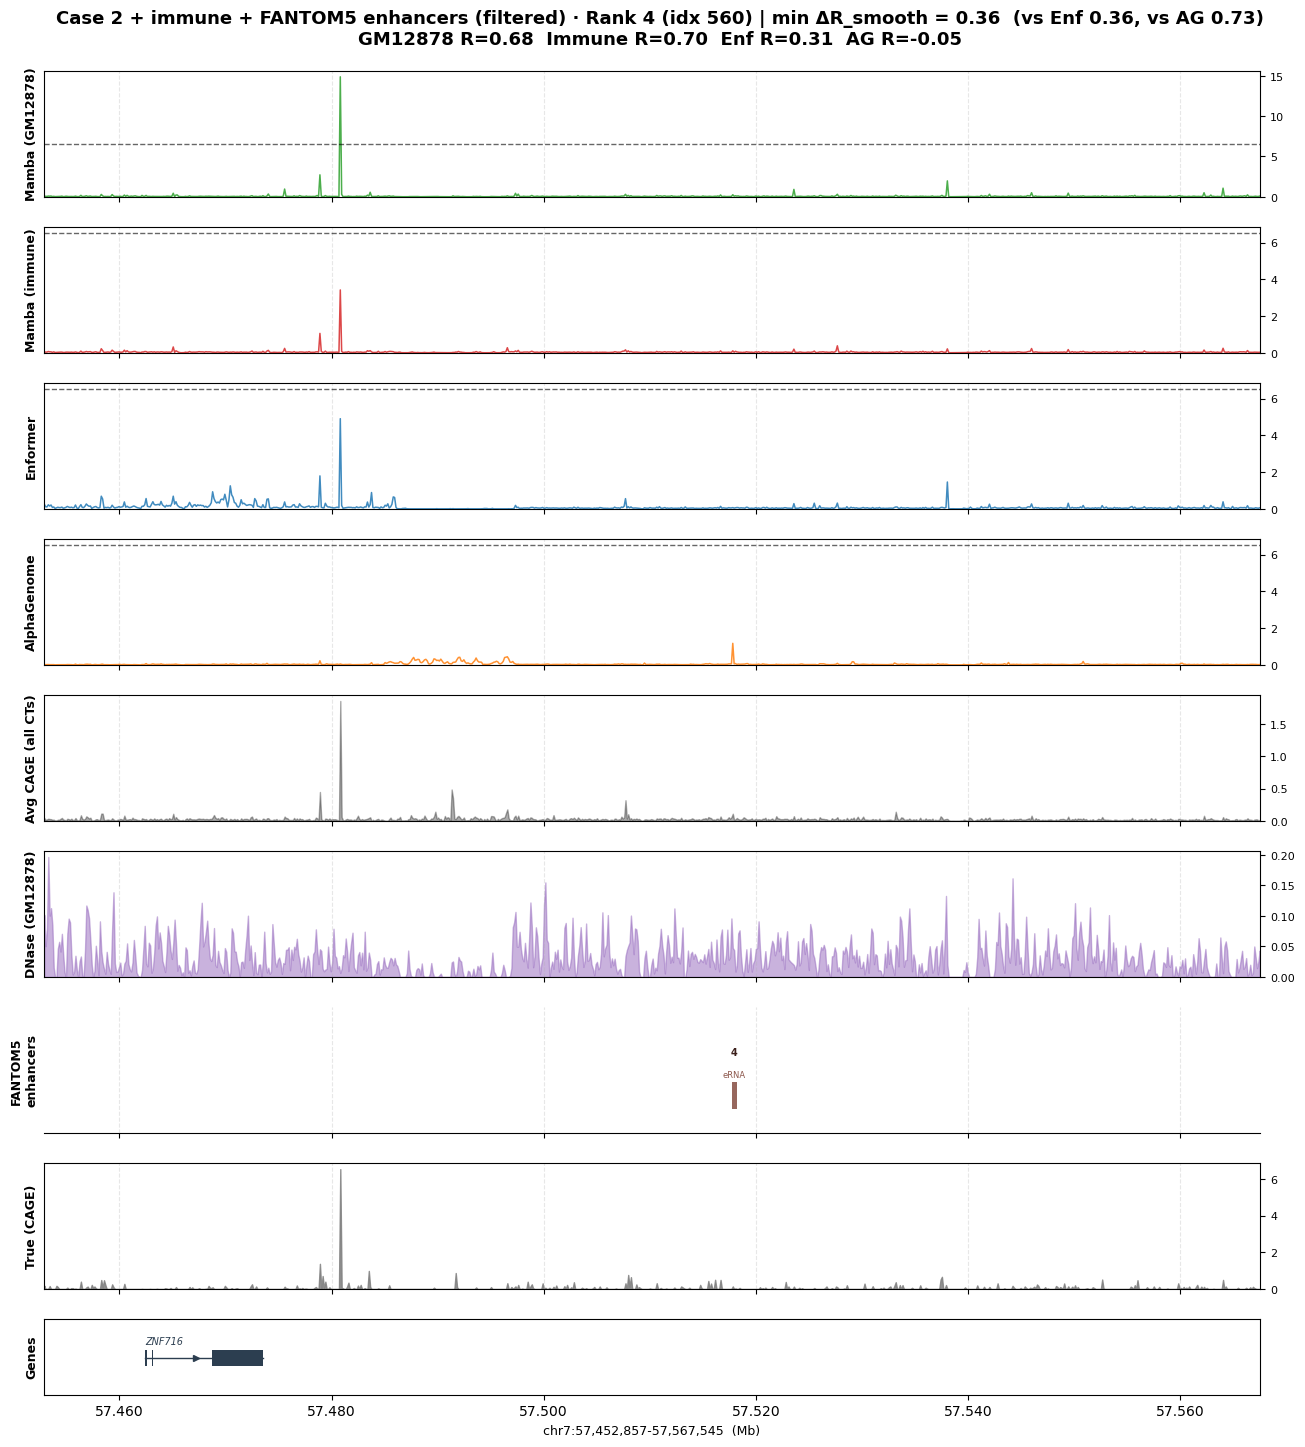

rank 5 (idx 962)  chr19:56,696,668-56,811,356  -> 0 FANTOM5 enhancer(s)


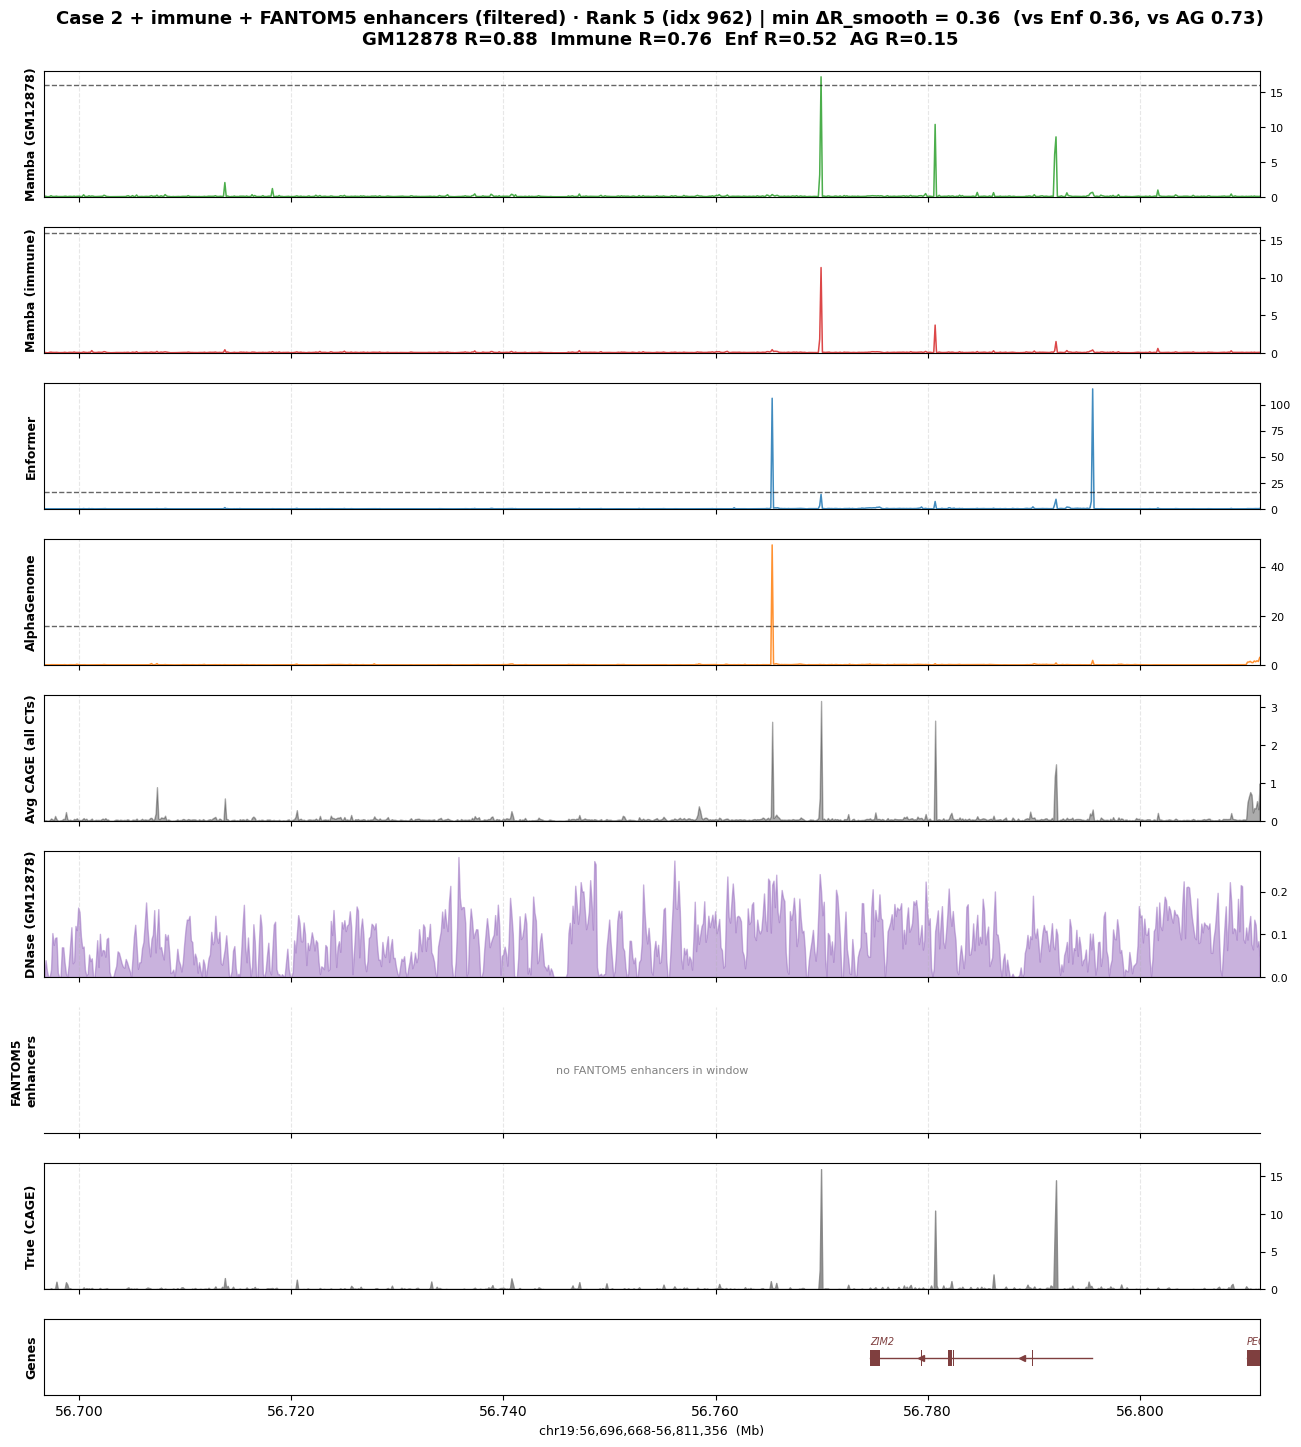

In [3]:
# ---------------------------------------------------------------------------------
# §10 = §8 (Case 2 filtered + Mamba immune) with a FANTOM5 enhancer track added.
# Run §10.0 above first (or §18) so preds / make_tracks / ann / top_allowed exist.
# ---------------------------------------------------------------------------------
from matplotlib.patches import Rectangle

# FANTOM5 enhancer atlas, hg38 reprocessed set (Dalby, Rennie & Andersson;
# doi:10.5281/zenodo.556775). BED12: the 2 blocks are the merged transcription-initiation
# regions on the + and - strands -- the bidirectional CAGE signature of an eRNA. Column 5
# is the CAGE-derived score summed over FANTOM5 libraries (the number printed above each
# block); it is a tag-count-derived score, not a raw per-sample read count.
ENH_BED = '/data1/lesliec/sarthak/data/references/F5.hg38.enhancers.sorted.bed'
ENH_COLOR = '#8c564b'

if '_enh_by_chrom' not in globals():          # already loaded by §10.0 -> skip the re-read
    _enh = pd.read_csv(ENH_BED, sep='\t', header=None, usecols=[0, 1, 2, 4],
                       names=['chrom', 'start', 'end', 'score'])
    _enh_by_chrom = {c: (g['start'].to_numpy(), g['end'].to_numpy(), g['score'].to_numpy())
                     for c, g in _enh.groupby('chrom')}
    print(f'FANTOM5 enhancers: {len(_enh):,} across {len(_enh_by_chrom)} chromosomes')


def enhancers_in(chrom, start, end, min_score=0):
    """FANTOM5 enhancers overlapping [start, end) -> sorted list of (start, end, score)."""
    if chrom not in _enh_by_chrom:
        return []
    s, e, sc = _enh_by_chrom[chrom]
    m = (s < end) & (e > start) & (sc >= min_score)
    return sorted(zip(s[m].tolist(), e[m].tolist(), sc[m].tolist()))


def enh_layout(chrom, xlim, min_score=0, min_frac=0.004, gap_frac=0.06):
    """Records in view plus their packed row indices. Enhancers are ~300 bp in a 114 kb
    window, so blocks are widened to `min_frac` of the span to stay visible (the printed
    coordinates remain exact). Returns (recs, rows, n_rows, min_w)."""
    recs = enhancers_in(chrom, int(xlim[0]), int(xlim[1]), min_score=min_score)
    span = xlim[1] - xlim[0]
    min_w = span * min_frac
    rows, row_end = [], []
    for s, e, _ in recs:                       # greedy packing on the drawn extent
        x0 = (s + e) / 2 - max(e - s, min_w) / 2
        placed = next((i for i, le in enumerate(row_end) if x0 > le + span * gap_frac), None)
        if placed is None:
            placed = len(row_end)
            row_end.append(x0 + max(e - s, min_w))
        else:
            row_end[placed] = x0 + max(e - s, min_w)
        rows.append(placed)
    return recs, rows, (max(rows) + 1 if rows else 0), min_w


def draw_enhancer_track(ax, chrom, xlim, min_score=0, label='eRNA', **kw):
    """Draw FANTOM5 enhancers in view as blocks on `ax`, each with its label and, above
    that, the CAGE score. Returns the records drawn."""
    ax.set_xlim(xlim)
    ax.set_yticks([])
    ax.set_ylabel('FANTOM5\nenhancers', fontsize=9, weight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    for side in ('left', 'right', 'top'):
        ax.spines[side].set_visible(False)

    recs, rows, n_rows, min_w = enh_layout(chrom, xlim, min_score=min_score, **kw)
    if not recs:
        ax.text(0.5, 0.5, 'no FANTOM5 enhancers in window', transform=ax.transAxes,
                ha='center', va='center', fontsize=8, color='gray')
        ax.set_ylim(0, 1)
        return recs

    log_max = np.log1p(max(r[2] for r in recs))
    show_label = n_rows <= 3        # dense loci: score only, the repeated label just crowds

    for (s, e, sc), row in zip(recs, rows):
        y = n_rows - 1 - row
        w = max(e - s, min_w)
        x0 = (s + e) / 2 - w / 2
        # opacity on a log scale: scores span ~1 to ~2e4 with a median near 9
        alpha = 0.35 + 0.55 * (np.log1p(sc) / log_max if log_max > 0 else 1.0)
        ax.add_patch(Rectangle((x0, y - 0.16), w, 0.32, facecolor=ENH_COLOR,
                               edgecolor='none', alpha=alpha, zorder=3))
        xc = min(max((s + e) / 2, xlim[0]), xlim[1])
        if show_label:
            ax.text(xc, y + 0.19, label, fontsize=6, color=ENH_COLOR,
                    ha='center', va='bottom', clip_on=True, zorder=4)      # label
        ax.text(xc, y + (0.45 if show_label else 0.19), f'{int(sc):,}', fontsize=7,
                weight='bold', color='#3b1f1a',
                ha='center', va='bottom', clip_on=True, zorder=4)          # score above it
    ax.set_ylim(-0.45, n_rows - 1 + 1.05)
    return recs


mamba_key    = 'GM12878_no_mlm_predictions.npy'
immune_key   = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'
ag_key       = 'alphagenome_cage_test_128bp.npy'

delta_enf  = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag   = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_both = np.minimum(delta_enf, delta_ag)
top = top_allowed(delta_both, n=5)

ENH_MIN_SCORE = 0        # raise (e.g. 50) to show only strongly-transcribed enhancers

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, immune_key, enformer_key, ag_key])
    chrom, start, end = region

    # Empty placeholder Track: reserves an axis in the stack (last signal axis, directly
    # above the truth axis and the gene track). The blocks are drawn onto that axis after
    # plot_tracks returns, which is why the values are all zero and alpha is 0.
    enh_slot = len(tracks)
    tracks.append(Track(np.zeros(896), name='FANTOM5 enhancers', color=ENH_COLOR,
                        style='fill', alpha=0.0, reference_exempt=True,
                        chrom=chrom, start=start, bin_size=BIN))

    title = (f'Case 2 + immune + FANTOM5 enhancers (filtered) · Rank {rank+1} (idx {idx}) | '
             f'min ΔR_smooth = {delta_both[idx]:.2f}  '
             f'(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n'
             f'GM12878 R={r(mamba_key, idx):.2f}  Immune R={r(immune_key, idx):.2f}  '
             f'Enf R={r(enformer_key, idx):.2f}  AG R={r(ag_key, idx):.2f}')

    # plot_tracks fixes equal heights for every signal axis, so buy the whole figure some
    # extra height when the enhancer rows stack up (dense loci reach 5-6 rows).
    n_rows = enh_layout(chrom, (start, end), min_score=ENH_MIN_SCORE)[2]
    n_signal_axes = len(tracks) + 1
    figsize = (13, 1.6 * n_signal_axes + 1.7 + 0.55 * max(0, n_rows - 2))

    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title, figsize=figsize)
    recs = draw_enhancer_track(axes[enh_slot], chrom, (start, end), min_score=ENH_MIN_SCORE)

    print(f'rank {rank+1} (idx {idx})  {chrom}:{start:,}-{end:,}  '
          f'-> {len(recs)} FANTOM5 enhancer(s)')
    for s, e, sc in recs:
        print(f'    {chrom}:{s:,}-{e:,}  ({e-s} bp)  score={int(sc):,}')
    plt.show()

## 11. §10 + a GRO-cap bidirectional-peak track (GM12878)

Same regions, ranking and tracks as §10, plus a separate **GRO-cap** track from
`ENCFF187MUG.bed`. Run §10 first — this cell reuses its enhancer helpers and needs no data
reload.

`ENCFF187MUG` is ENCODE output type **"bidirectional peaks"**, assay **GRO-cap**, biosample
**GM12878**, assembly **GRCh38** (experiment `ENCSR719WNF`) — so unlike the pan-cell-type
FANTOM5 atlas, this track *is* matched to the CAGE target and the DNase track. It captures the
same divergent-initiation signature the FANTOM5 enhancer calls are built on, which makes it an
orthogonal, cell-type-matched check on where eRNA transcription actually initiates.

32,657 peaks genome-wide; 12,071 carry a Stringent call. Solid blocks are Stringent, pale
outlined blocks are Relaxed-only; flip `GC_STRINGENT_ONLY = True` to drop the latter. Per
114,688 bp test window there are 1.6 peaks on average (median 0, max 32, 61% of windows empty).

The declared format is `bed3+`, so columns past 3 are not formally specified. Observed:

| col | content |
|-----|---------|
| 4 | confidence class(es), comma-joined: `Relaxed` / `Stringent(pval)` / `Stringent(qval)` |
| 5, 6 | the two divergent TSS peak positions, both always inside `[start, end)` |

Column 6 is the left/upstream position in 96.8% of records (median 7 bp from `start`), but
ENCODE does not document which position is the plus- vs minus-strand TSS, so the cell only
treats them as an ordered pair (`tss_left` / `tss_right`) and prints both under each figure.
**There is no score column**, so unlike the FANTOM5 track there is no read-like number to print
above each block — the confidence class is shown instead.

GRO-cap bidirectional peaks: 32,657 (12,071 with a Stringent call) across 27 contigs
rank 1 (idx 1811)  chrX:37,294,029-37,408,717  -> 1 FANTOM5 enhancer(s), 0 GRO-cap peak(s)
    FANTOM5  chrX:37,349,833-37,350,173  (340 bp)  score=62


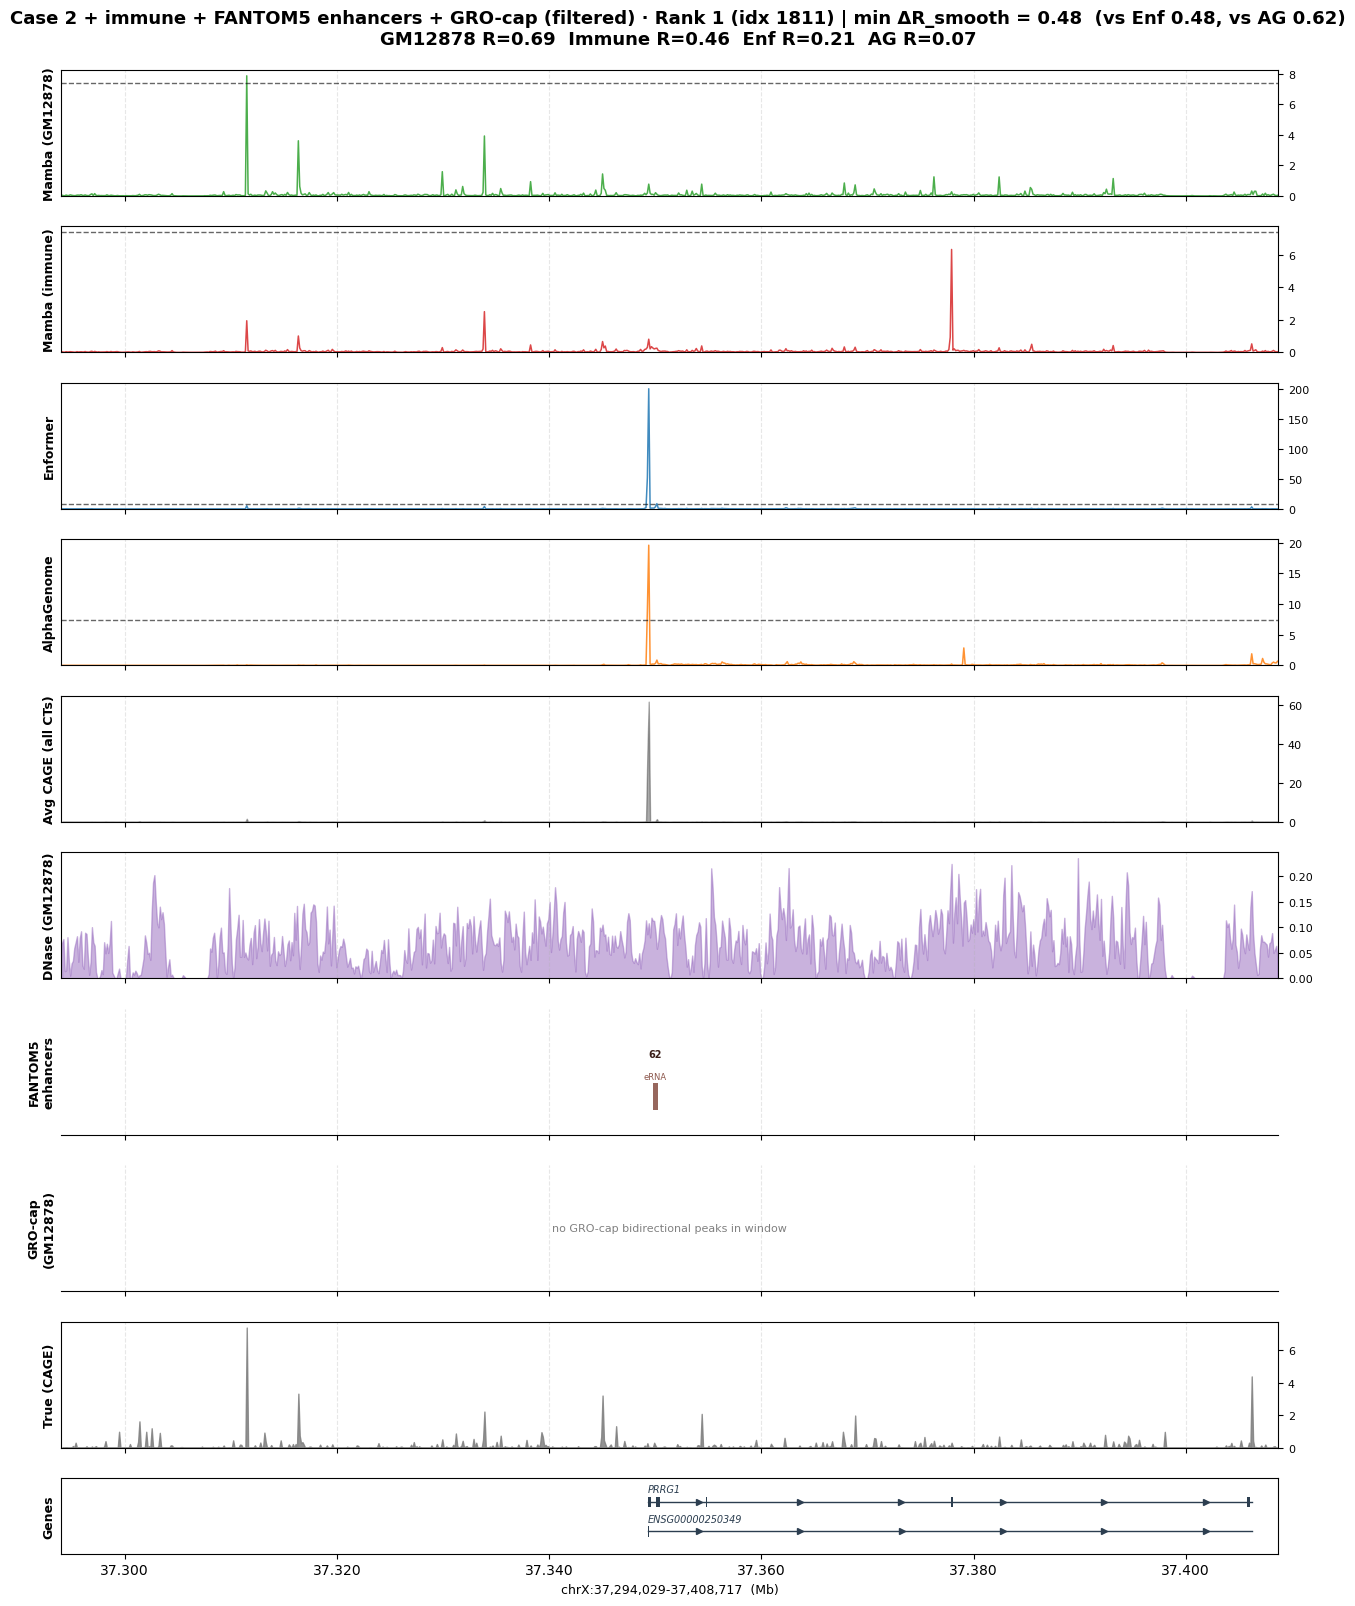

rank 2 (idx 803)  chr19:22,555,439-22,670,127  -> 0 FANTOM5 enhancer(s), 0 GRO-cap peak(s)


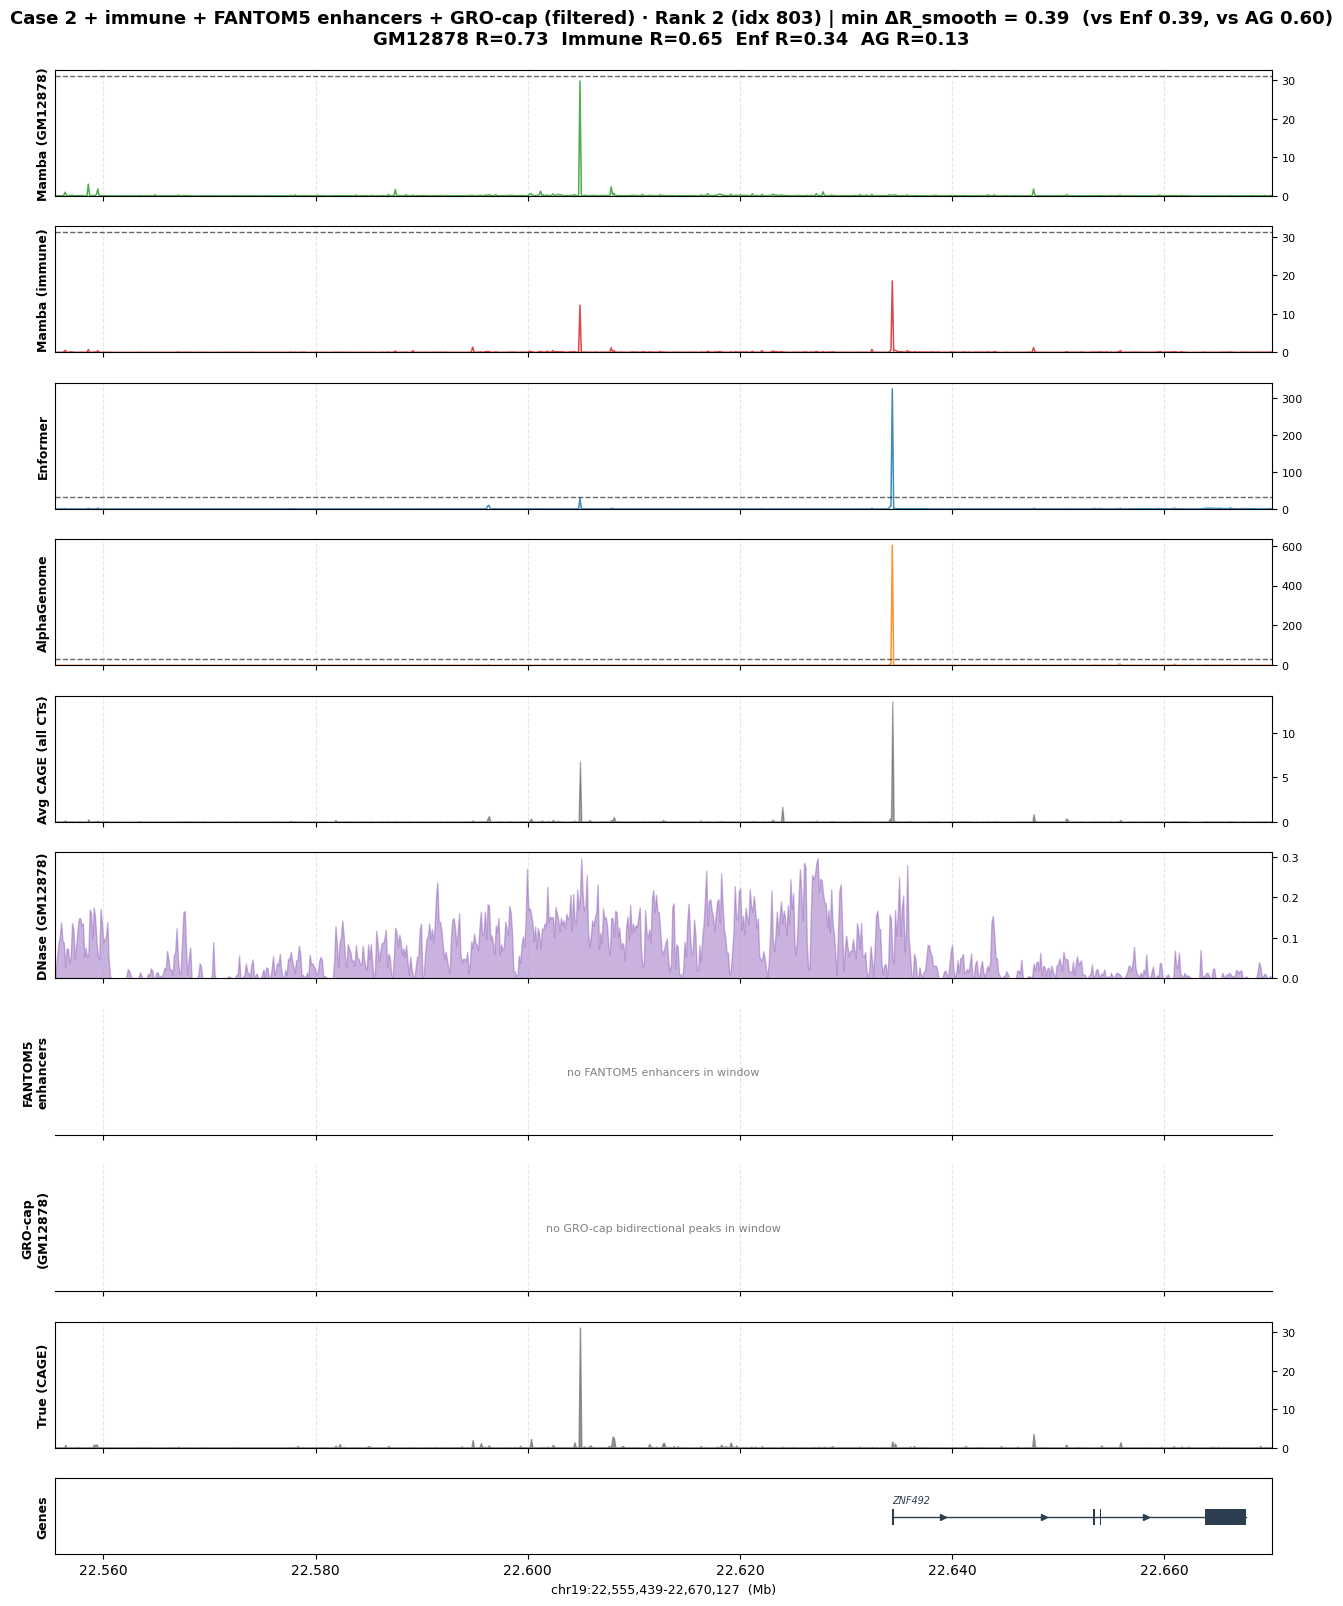

rank 3 (idx 1797)  chr11:44,831,307-44,945,995  -> 5 FANTOM5 enhancer(s), 0 GRO-cap peak(s)
    FANTOM5  chr11:44,861,229-44,861,483  (254 bp)  score=22
    FANTOM5  chr11:44,862,258-44,862,617  (359 bp)  score=198
    FANTOM5  chr11:44,863,385-44,863,576  (191 bp)  score=9
    FANTOM5  chr11:44,916,812-44,917,035  (223 bp)  score=7
    FANTOM5  chr11:44,941,646-44,941,931  (285 bp)  score=4


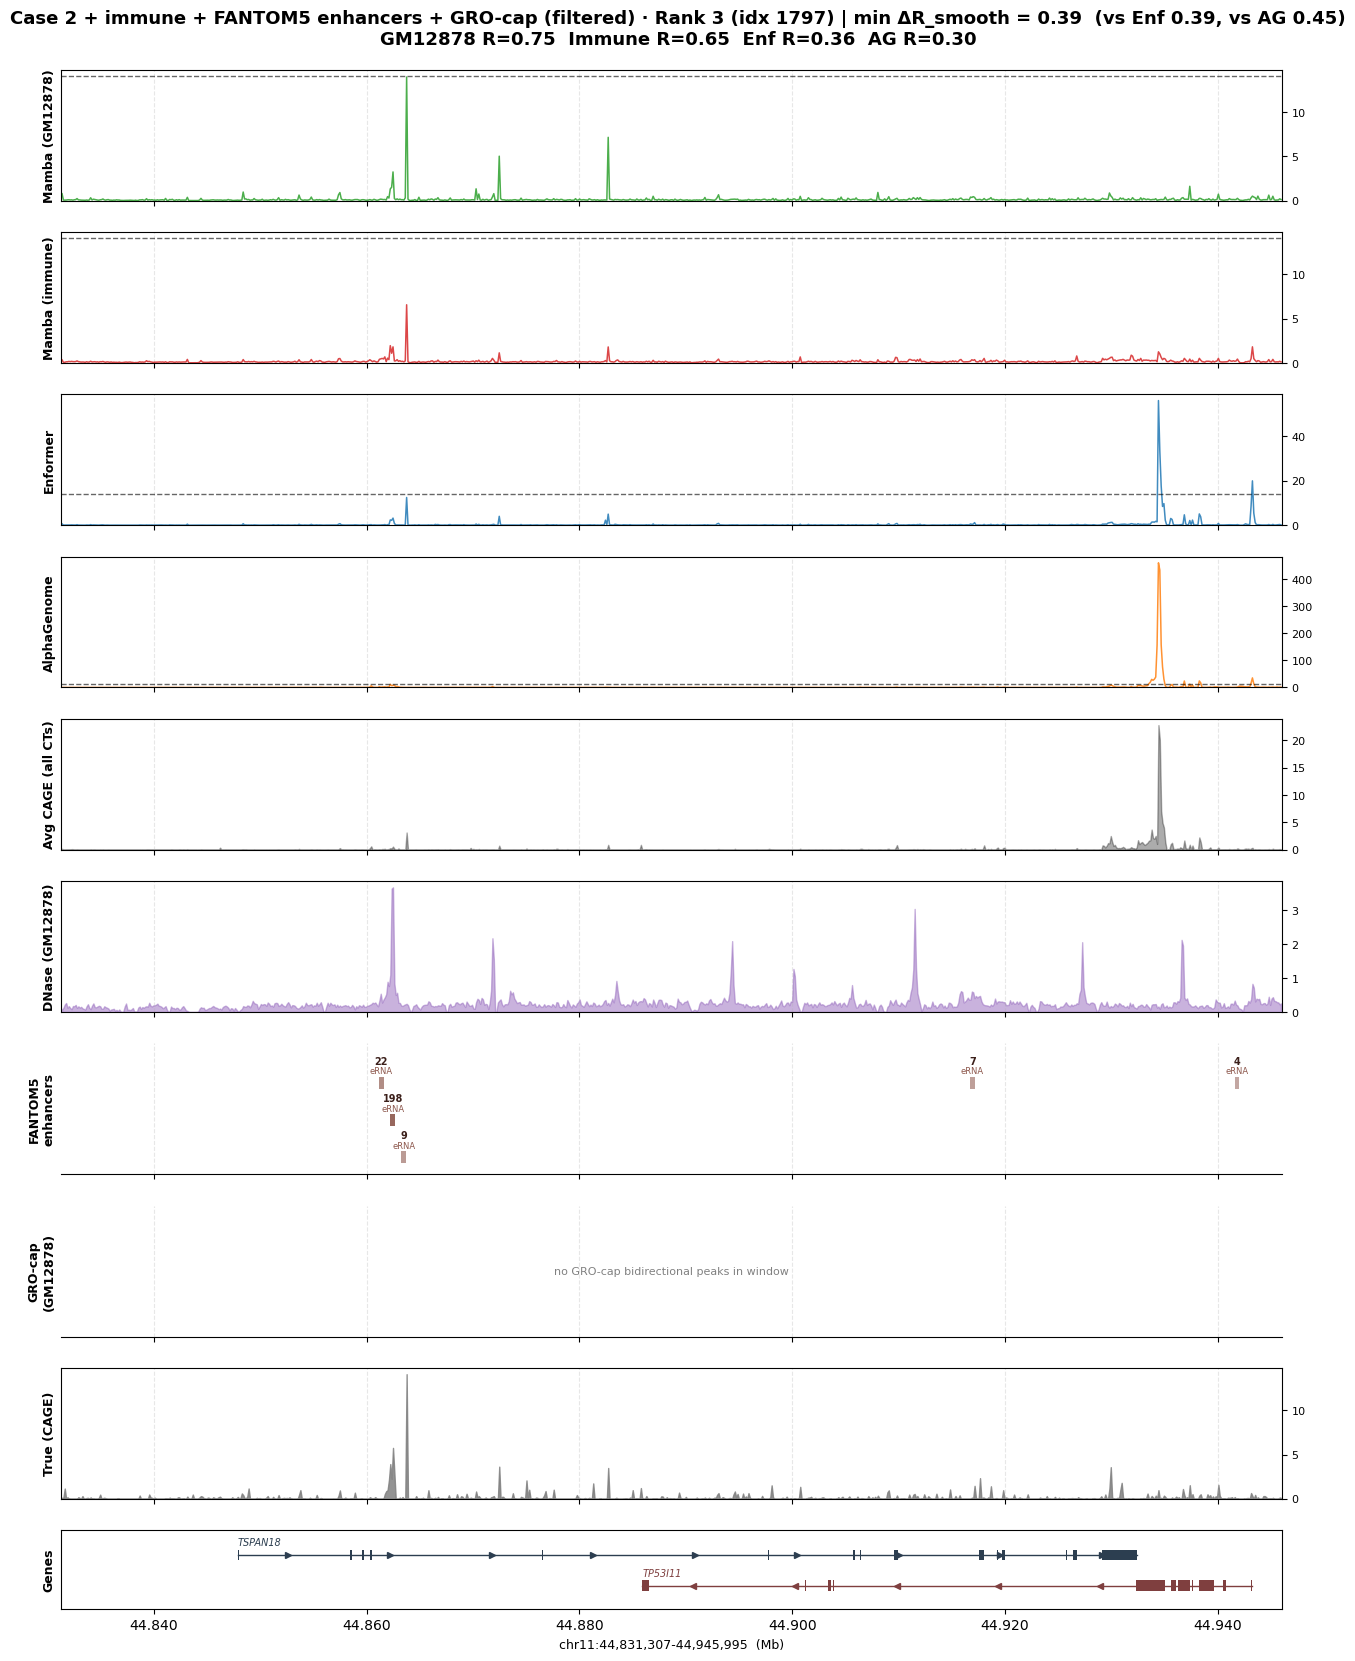

rank 4 (idx 560)  chr7:57,452,857-57,567,545  -> 1 FANTOM5 enhancer(s), 0 GRO-cap peak(s)
    FANTOM5  chr7:57,517,846-57,518,077  (231 bp)  score=4


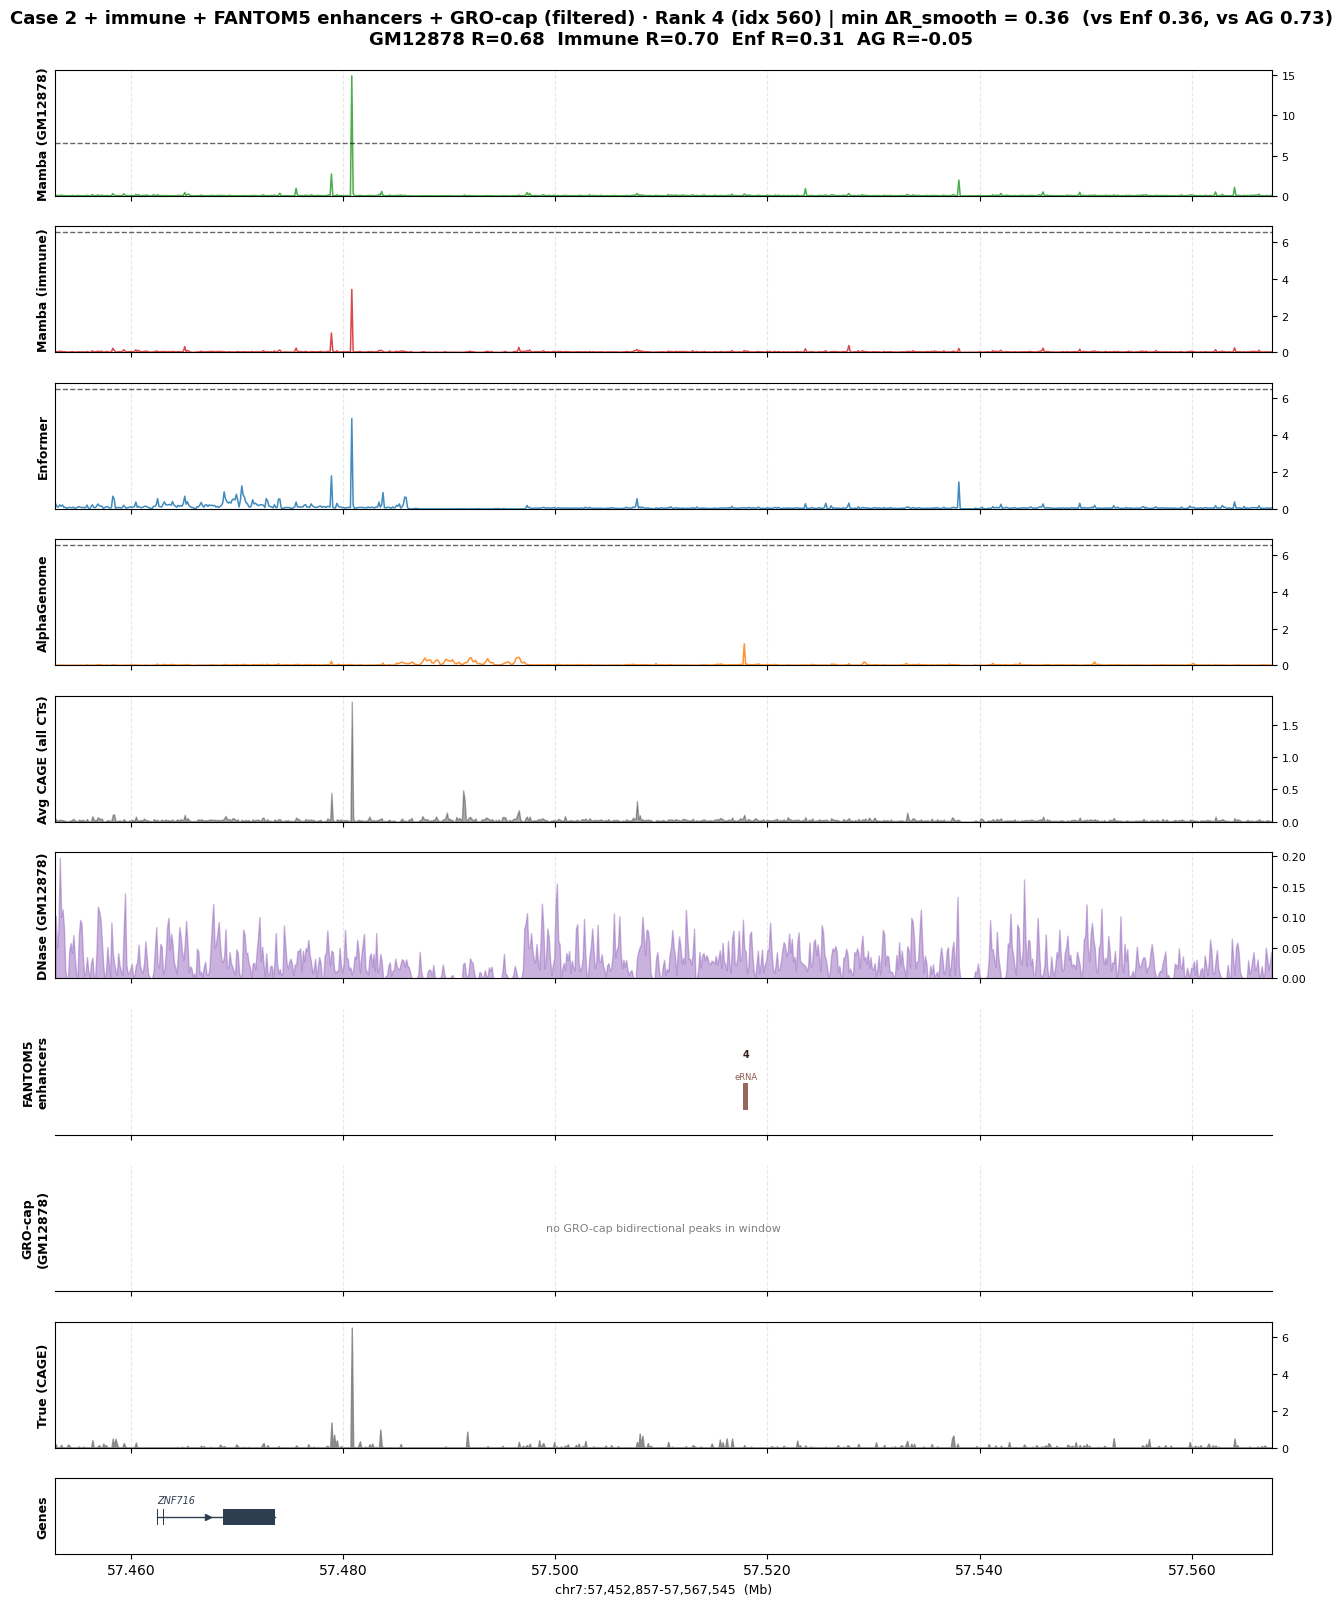

rank 5 (idx 962)  chr19:56,696,668-56,811,356  -> 0 FANTOM5 enhancer(s), 0 GRO-cap peak(s)


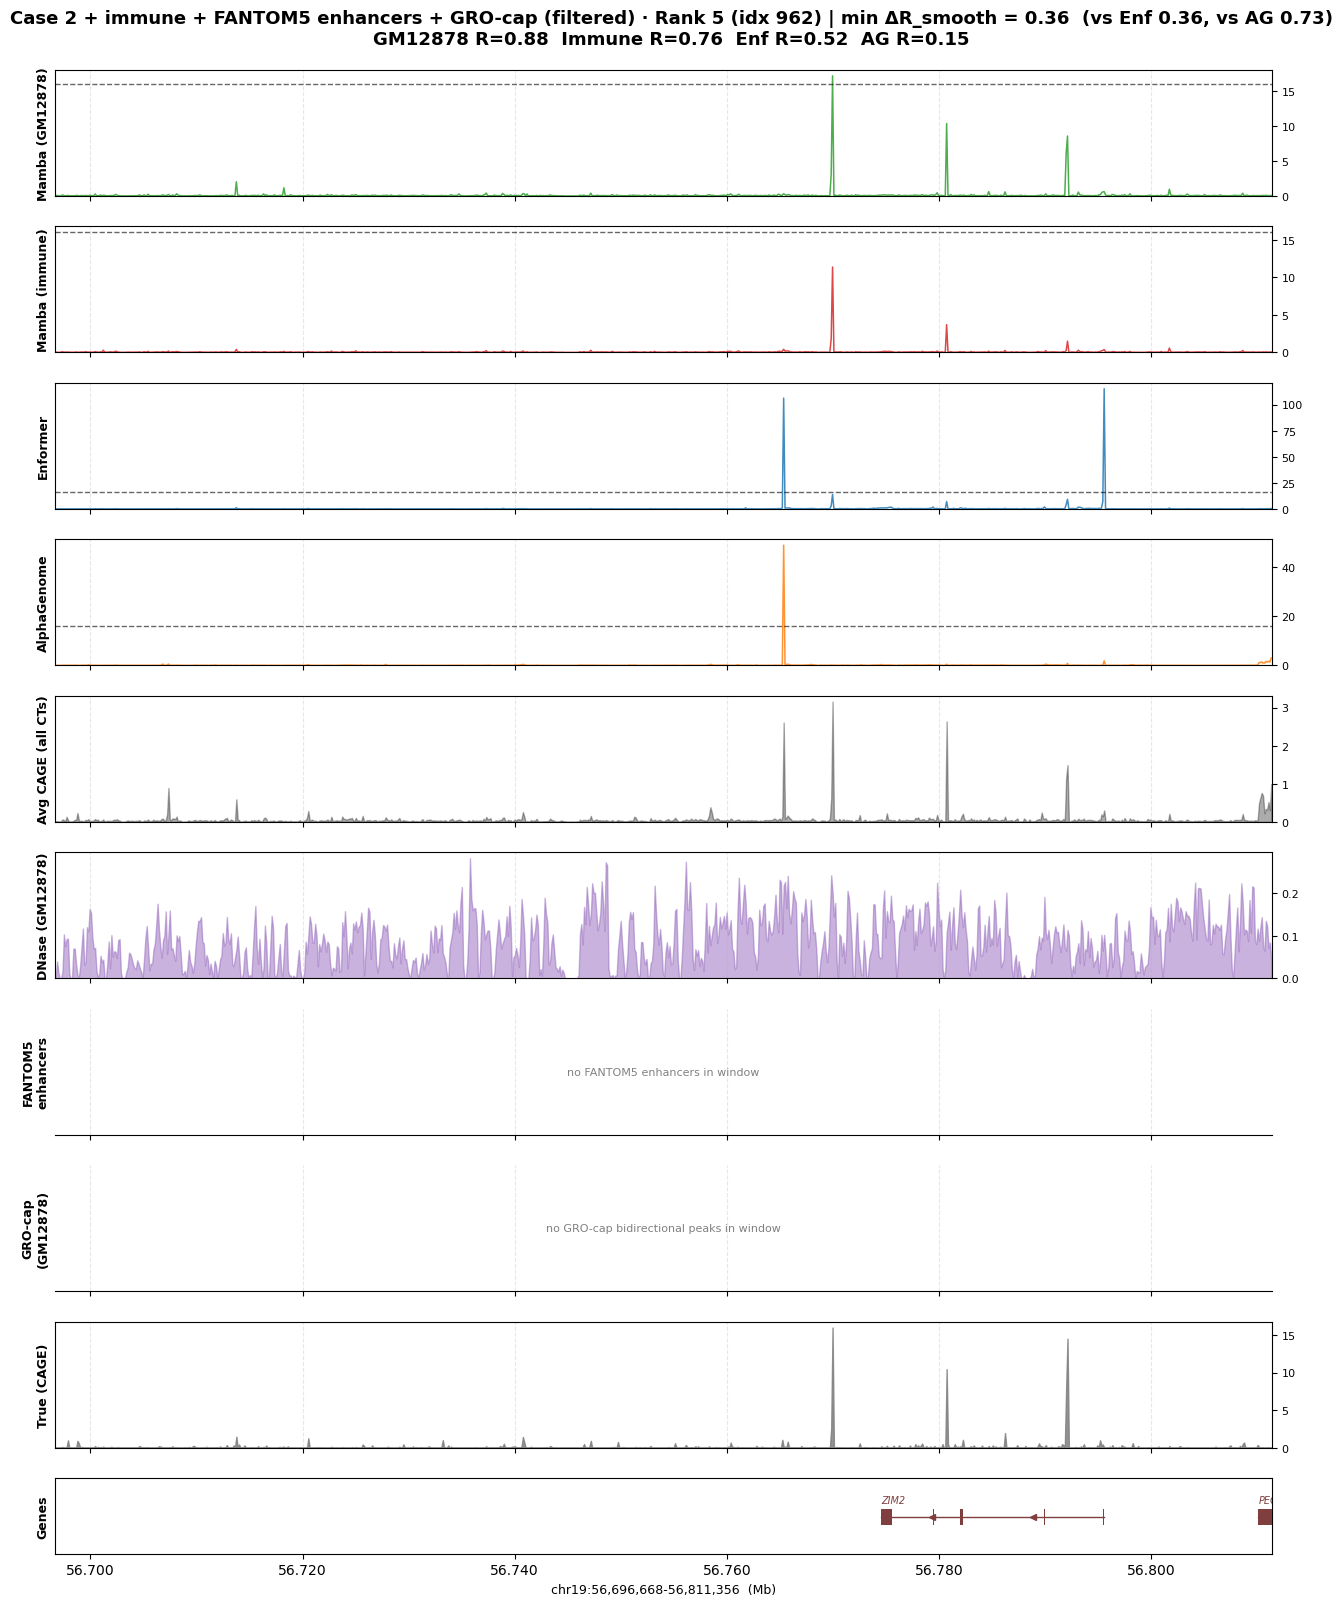

In [3]:
# ---------------------------------------------------------------------------------
# §11 = §10 plus a GRO-cap bidirectional-peak track (GM12878).
# Run §10 first -- this cell reuses its enhancer helpers (enh_layout, draw_enhancer_track)
# and whatever §10.0/§18 already put in memory. No data reload here.
#
# ENCFF187MUG = ENCODE GRO-cap "bidirectional peaks", GM12878, GRCh38 (expt ENCSR719WNF).
# Same cell type as the CAGE target and the DNase track, and the same divergent-initiation
# signature the FANTOM5 enhancer calls are built on -- so this is an orthogonal, GM12878-
# specific check on where eRNA transcription actually initiates.
#
# Declared format is bed3+, so columns beyond 3 are not formally specified. Observed:
#   col4 = confidence class(es), comma-joined: Relaxed / Stringent(pval) / Stringent(qval)
#   col5, col6 = the two divergent TSS peak positions, both always inside [start, end)
#                (col6 is the left/upstream one in 96.8% of records, median 7 bp from start)
# There is NO score column, so unlike the FANTOM5 track there is no read-like number to
# print above each block -- the confidence class is shown instead.
# ---------------------------------------------------------------------------------
from matplotlib.patches import Rectangle

GROCAP_BED = '/data1/lesliec/sarthak/data/DK_zarr/raw_files/ENCFF187MUG.bed'
GC_COLOR = '#0e7c7b'

if '_gc_by_chrom' not in globals():
    _gc = pd.read_csv(GROCAP_BED, sep='\t', header=None, usecols=[0, 1, 2, 3, 4, 5],
                      names=['chrom', 'start', 'end', 'cls', 'tss_a', 'tss_b'])
    _gc['stringent'] = _gc['cls'].str.contains('Stringent')
    # tss_left/tss_right = the two divergent TSS positions, ordered on the genome
    _gc['tss_left'] = _gc[['tss_a', 'tss_b']].min(axis=1)
    _gc['tss_right'] = _gc[['tss_a', 'tss_b']].max(axis=1)
    _gc_by_chrom = {c: (x['start'].to_numpy(), x['end'].to_numpy(), x['stringent'].to_numpy(),
                        x['tss_left'].to_numpy(), x['tss_right'].to_numpy())
                    for c, x in _gc.groupby('chrom')}
    print(f'GRO-cap bidirectional peaks: {len(_gc):,} '
          f'({_gc["stringent"].sum():,} with a Stringent call) across {len(_gc_by_chrom)} contigs')
else:
    print('GRO-cap BED already in memory - skipped')


def grocap_in(chrom, start, end, stringent_only=False):
    """GRO-cap peaks overlapping [start, end) -> sorted list of
    (start, end, stringent, tss_left, tss_right)."""
    if chrom not in _gc_by_chrom:
        return []
    s, e, sg, tl, tr = _gc_by_chrom[chrom]
    m = (s < end) & (e > start)
    if stringent_only:
        m = m & sg
    return sorted(zip(s[m].tolist(), e[m].tolist(), sg[m].tolist(),
                      tl[m].tolist(), tr[m].tolist()))


def gc_layout(chrom, xlim, stringent_only=False, min_frac=0.004, gap_frac=0.05):
    """Peaks in view plus packed row indices (same widening/packing as the enhancer track)."""
    recs = grocap_in(chrom, int(xlim[0]), int(xlim[1]), stringent_only=stringent_only)
    span = xlim[1] - xlim[0]
    min_w = span * min_frac
    rows, row_end = [], []
    for s, e, *_ in recs:
        x0 = (s + e) / 2 - max(e - s, min_w) / 2
        placed = next((i for i, le in enumerate(row_end) if x0 > le + span * gap_frac), None)
        if placed is None:
            placed = len(row_end)
            row_end.append(x0 + max(e - s, min_w))
        else:
            row_end[placed] = x0 + max(e - s, min_w)
        rows.append(placed)
    return recs, rows, (max(rows) + 1 if rows else 0), min_w


def draw_grocap_track(ax, chrom, xlim, stringent_only=False, **kw):
    """Draw GRO-cap bidirectional peaks on `ax`: solid block = has a Stringent call,
    pale/outlined block = Relaxed only. Returns the records drawn."""
    ax.set_xlim(xlim)
    ax.set_yticks([])
    ax.set_ylabel('GRO-cap\n(GM12878)', fontsize=9, weight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    for side in ('left', 'right', 'top'):
        ax.spines[side].set_visible(False)

    recs, rows, n_rows, min_w = gc_layout(chrom, xlim, stringent_only=stringent_only, **kw)
    if not recs:
        ax.text(0.5, 0.5, 'no GRO-cap bidirectional peaks in window', transform=ax.transAxes,
                ha='center', va='center', fontsize=8, color='gray')
        ax.set_ylim(0, 1)
        return recs

    show_label = n_rows <= 3
    for (s, e, sg, tl, tr), row in zip(recs, rows):
        y = n_rows - 1 - row
        w = max(e - s, min_w)
        x0 = (s + e) / 2 - w / 2
        if sg:
            ax.add_patch(Rectangle((x0, y - 0.16), w, 0.32, facecolor=GC_COLOR,
                                   edgecolor='none', alpha=0.9, zorder=3))
        else:
            ax.add_patch(Rectangle((x0, y - 0.16), w, 0.32, facecolor=GC_COLOR,
                                   edgecolor=GC_COLOR, lw=0.8, alpha=0.28, zorder=3))
        if show_label:
            xc = min(max((s + e) / 2, xlim[0]), xlim[1])
            ax.text(xc, y + 0.19, 'stringent' if sg else 'relaxed', fontsize=6,
                    color=GC_COLOR, ha='center', va='bottom', clip_on=True, zorder=4)
    ax.set_ylim(-0.45, n_rows - 1 + (0.85 if show_label else 0.55))
    ax.legend(handles=[Rectangle((0, 0), 1, 1, facecolor=GC_COLOR, alpha=0.9),
                       Rectangle((0, 0), 1, 1, facecolor=GC_COLOR, edgecolor=GC_COLOR, alpha=0.28)],
              labels=['Stringent', 'Relaxed only'], fontsize=6, loc='upper right',
              frameon=False, ncol=2, handlelength=1.2, borderaxespad=0.1)
    return recs


mamba_key    = 'GM12878_no_mlm_predictions.npy'
immune_key   = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'
ag_key       = 'alphagenome_cage_test_128bp.npy'

delta_enf  = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag   = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_both = np.minimum(delta_enf, delta_ag)
top = top_allowed(delta_both, n=5)

ENH_MIN_SCORE = 0        # raise (e.g. 50) to show only strongly-transcribed enhancers
GC_STRINGENT_ONLY = False  # True -> drop the 20,586 Relaxed-only peaks

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, immune_key, enformer_key, ag_key])
    chrom, start, end = region

    # two empty placeholder Tracks reserve the last two signal axes (FANTOM5 enhancers,
    # then GRO-cap), sitting directly above the truth axis and the gene track.
    enh_slot = len(tracks)
    tracks.append(Track(np.zeros(896), name='FANTOM5 enhancers', color=ENH_COLOR,
                        style='fill', alpha=0.0, reference_exempt=True,
                        chrom=chrom, start=start, bin_size=BIN))
    gc_slot = len(tracks)
    tracks.append(Track(np.zeros(896), name='GRO-cap', color=GC_COLOR,
                        style='fill', alpha=0.0, reference_exempt=True,
                        chrom=chrom, start=start, bin_size=BIN))

    title = (f'Case 2 + immune + FANTOM5 enhancers + GRO-cap (filtered) · '
             f'Rank {rank+1} (idx {idx}) | min ΔR_smooth = {delta_both[idx]:.2f}  '
             f'(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n'
             f'GM12878 R={r(mamba_key, idx):.2f}  Immune R={r(immune_key, idx):.2f}  '
             f'Enf R={r(enformer_key, idx):.2f}  AG R={r(ag_key, idx):.2f}')

    # plot_tracks gives every signal axis equal height, so pad the figure when either
    # interval track packs onto extra rows.
    enh_rows = enh_layout(chrom, (start, end), min_score=ENH_MIN_SCORE)[2]
    gc_rows = gc_layout(chrom, (start, end), stringent_only=GC_STRINGENT_ONLY)[2]
    n_signal_axes = len(tracks) + 1
    figsize = (13, 1.6 * n_signal_axes + 1.7
               + 0.55 * max(0, enh_rows - 2) + 0.55 * max(0, gc_rows - 2))

    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title, figsize=figsize)
    enh_recs = draw_enhancer_track(axes[enh_slot], chrom, (start, end),
                                   min_score=ENH_MIN_SCORE)
    gc_recs = draw_grocap_track(axes[gc_slot], chrom, (start, end),
                                stringent_only=GC_STRINGENT_ONLY)

    print(f'rank {rank+1} (idx {idx})  {chrom}:{start:,}-{end:,}  '
          f'-> {len(enh_recs)} FANTOM5 enhancer(s), {len(gc_recs)} GRO-cap peak(s)')
    for s, e, sc in enh_recs:
        print(f'    FANTOM5  {chrom}:{s:,}-{e:,}  ({e-s} bp)  score={int(sc):,}')
    for s, e, sg, tl, tr in gc_recs:
        print(f'    GRO-cap  {chrom}:{s:,}-{e:,}  ({e-s} bp)  '
              f'{"Stringent" if sg else "Relaxed"}  TSS pair {tl:,} / {tr:,}')
    plt.show()

## 12. §11 with GRO-cap as bigWig signal instead of peak calls

Same regions, ranking and tracks as §11, but the GRO-cap track is now the **actual stranded
signal** rather than the BED peak calls. Run §10 first (enhancer helpers); no data reload needed.

Both bigWigs come from the same experiment as §11's BED — `ENCSR719WNF`, GRO-cap, GM12878,
GRCh38:

| file | output_type | observed value range |
|------|-------------|----------------------|
| `ENCFF799JUK` | plus strand signal of unique reads | all positive, `1 .. 28252` |
| `ENCFF368RBW` | minus strand counterpart | all negative, `-32958 .. 0` |

**ENCODE stores the minus strand as negative numbers**, so a literal `plus + minus` would
largely cancel rather than combine. This cell takes **`|plus| + |minus|`** — total unique-read
5'-end depth per bp — then mean-pools 128 bp → 896 bins, the same pooling `dnase_profile` uses,
so it aligns with the CAGE tracks. Bases with no coverage read back as `NaN` and are treated
as 0.

Unlike the FANTOM5 score, these values *are* read counts (unique reads). Only ~2.2 Mb of the
genome is covered in each file, so the track is very sparse and spiky: per 114,688 bp test
window the median summed signal is 0.6, and 49 of 1,937 windows are completely empty.

As a check on the `|plus| + |minus|` combination, 78.4% of the summed signal in the first 40
peak-containing test windows falls inside §11's called bidirectional peaks — the remainder is
sub-threshold signal that did not make a peak call, which is what you'd expect.

GRO-cap plus  bigWig: 24 contigs, covered 2,218,983 bp, range [1, 28252]
GRO-cap minus bigWig: 24 contigs, covered 2,205,824 bp, range [-32958, 0]
rank 1 (idx 1811)  chrX:37,294,029-37,408,717  -> 1 FANTOM5 enhancer(s); GRO-cap signal in 5/896 bins, max 0.0, total 7 reads
    FANTOM5  chrX:37,349,833-37,350,173  (340 bp)  score=62


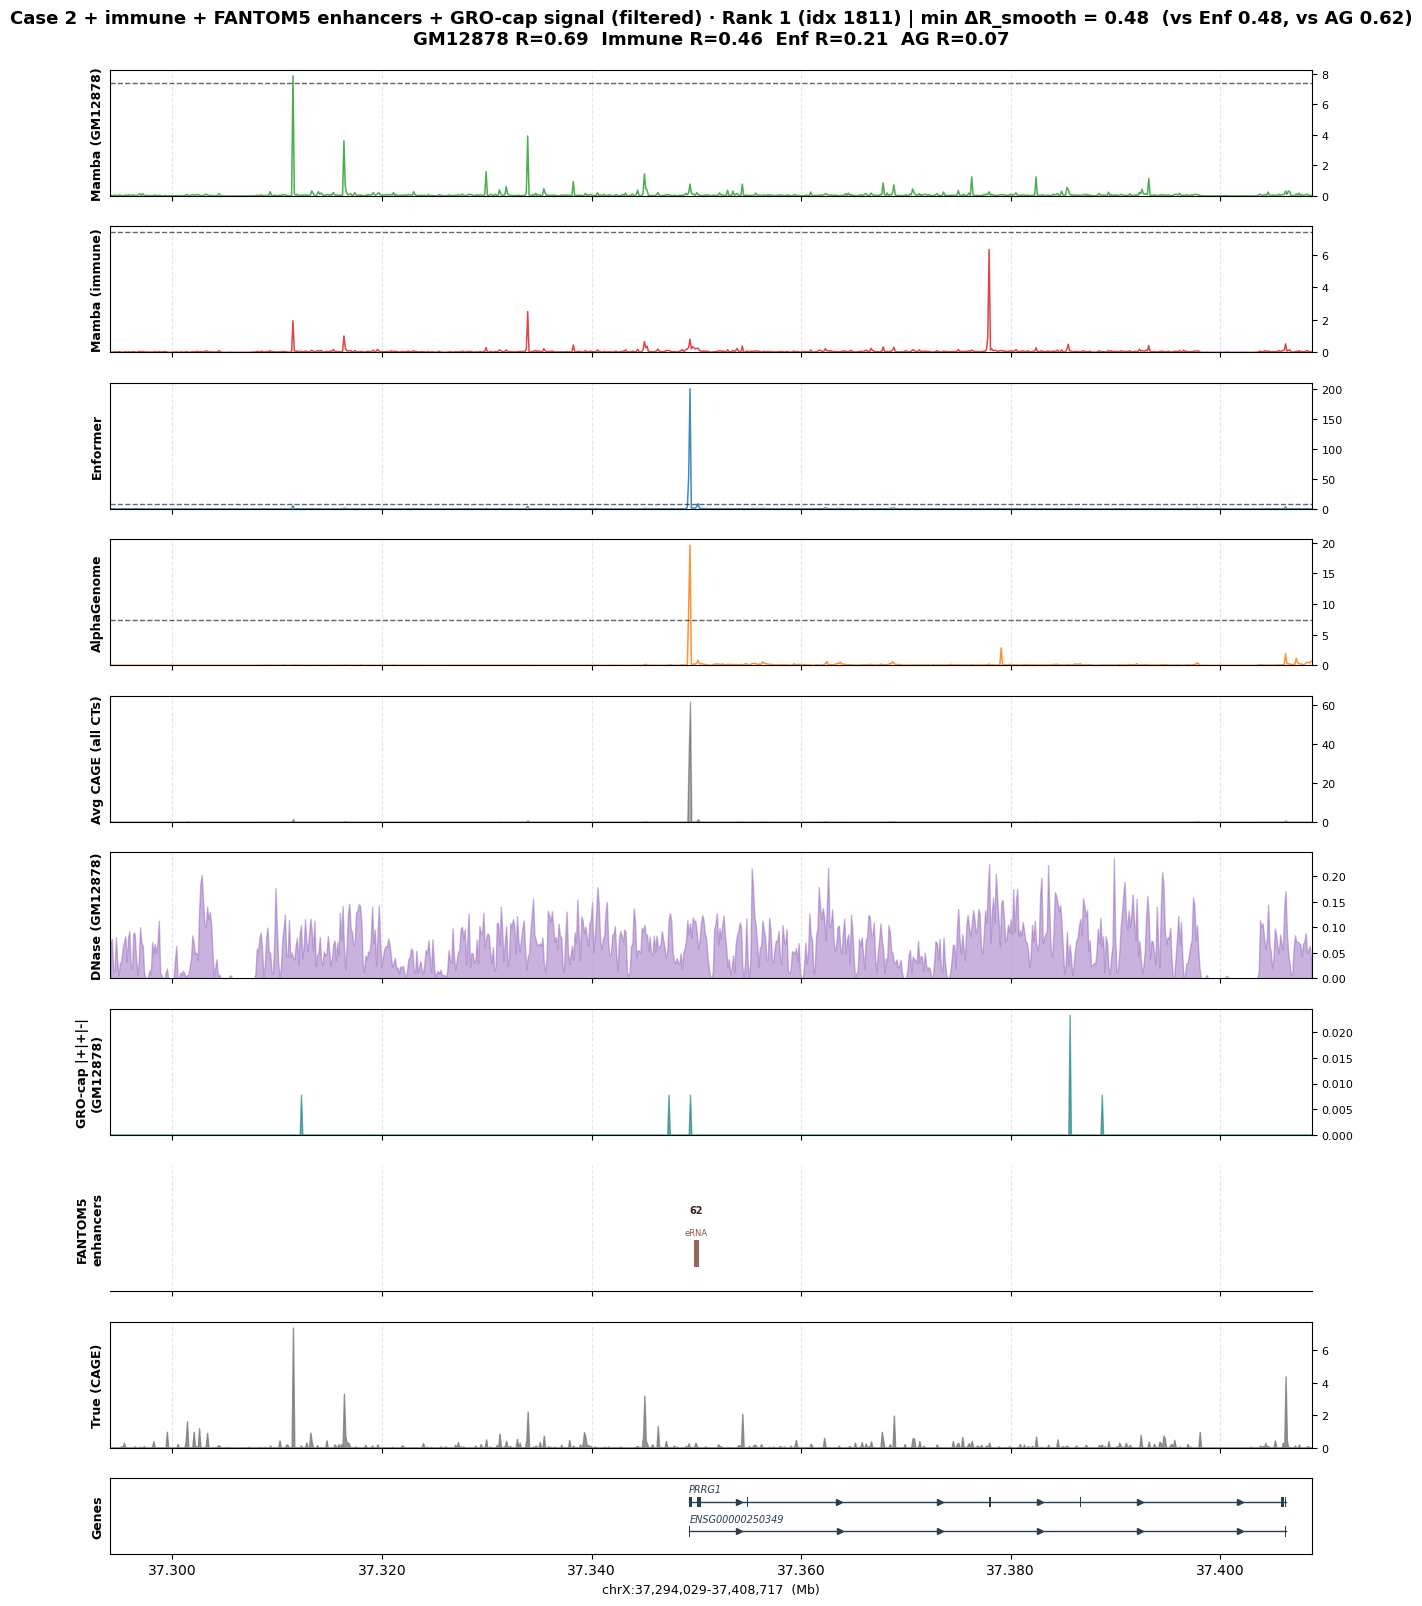

rank 2 (idx 803)  chr19:22,555,439-22,670,127  -> 0 FANTOM5 enhancer(s); GRO-cap signal in 3/896 bins, max 0.0, total 9 reads


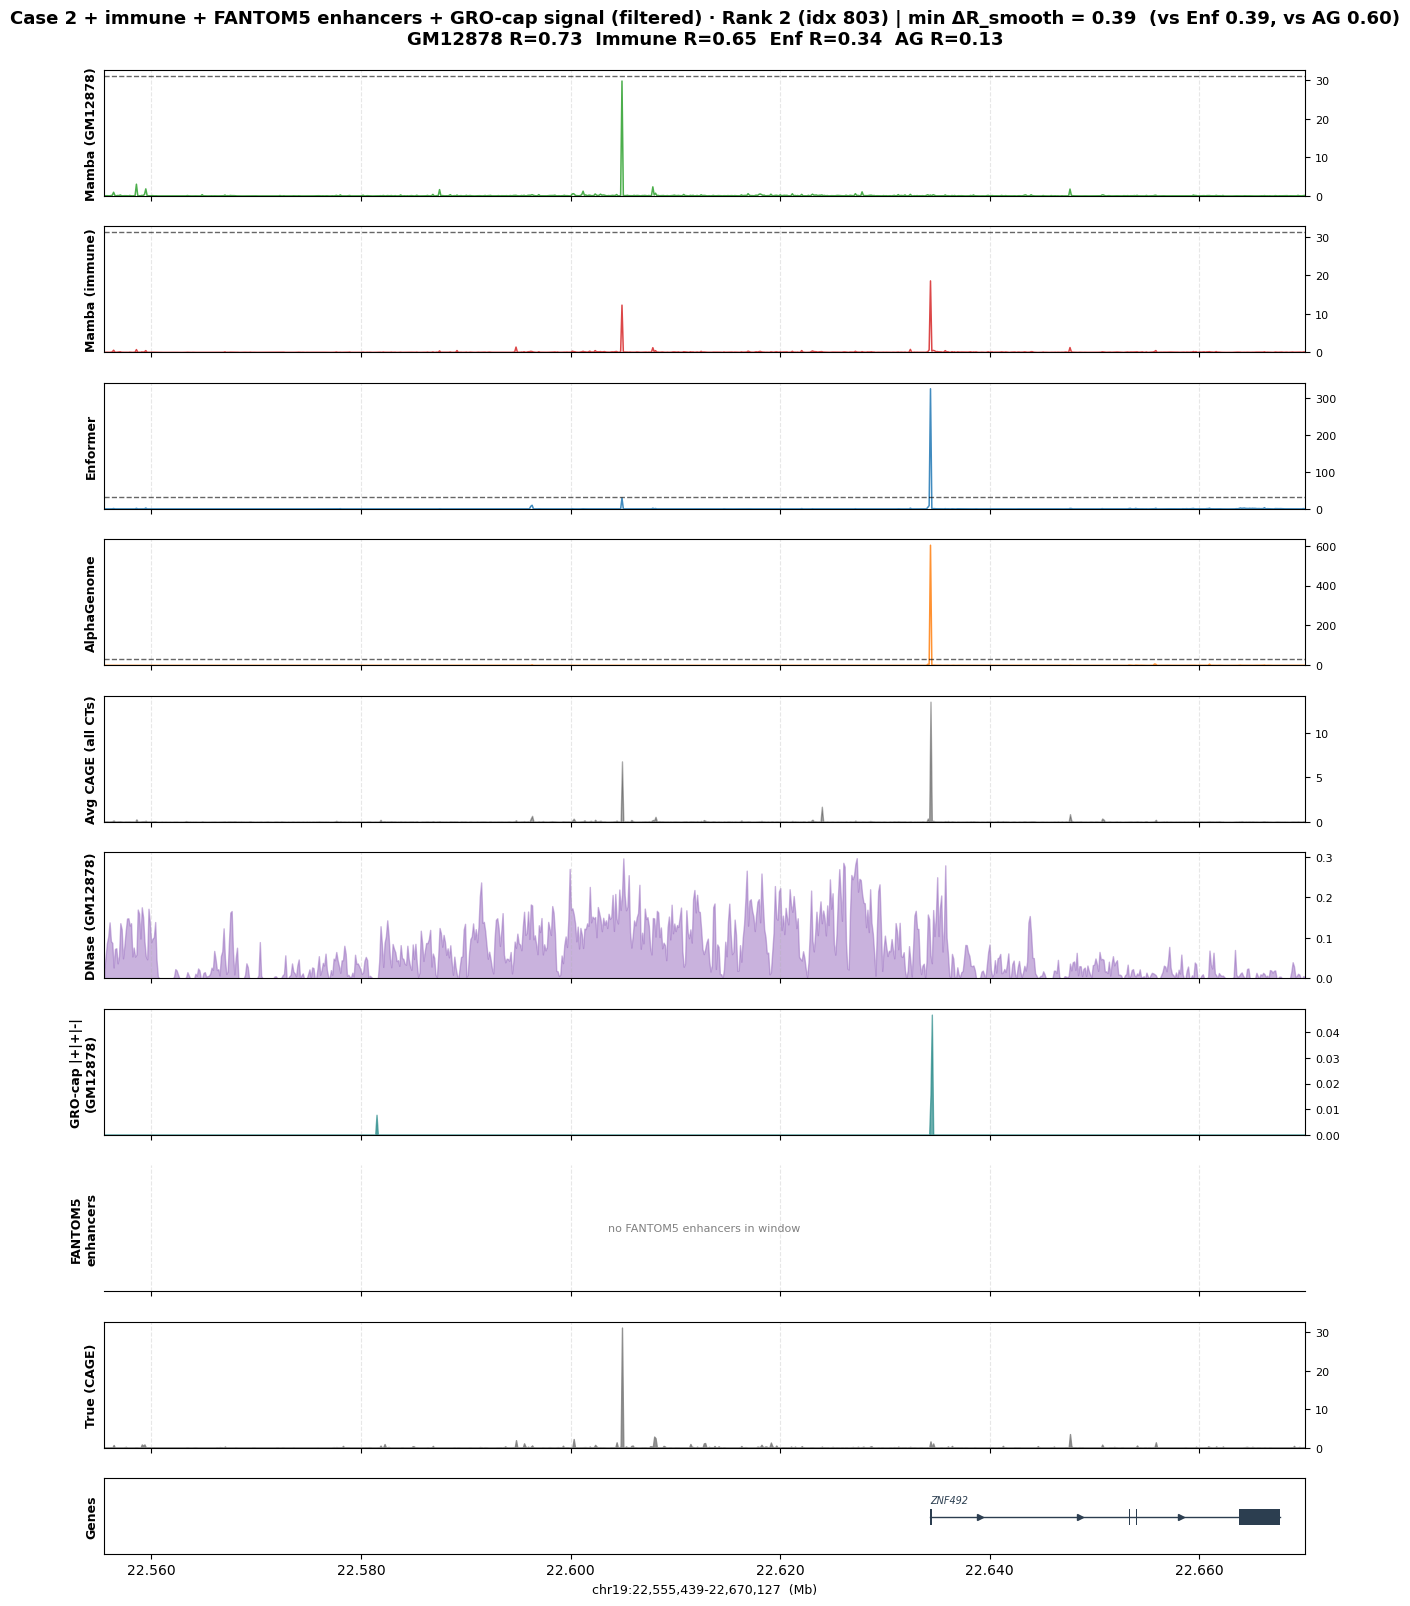

rank 3 (idx 1797)  chr11:44,831,307-44,945,995  -> 5 FANTOM5 enhancer(s); GRO-cap signal in 37/896 bins, max 0.4, total 208 reads
    FANTOM5  chr11:44,861,229-44,861,483  (254 bp)  score=22
    FANTOM5  chr11:44,862,258-44,862,617  (359 bp)  score=198
    FANTOM5  chr11:44,863,385-44,863,576  (191 bp)  score=9
    FANTOM5  chr11:44,916,812-44,917,035  (223 bp)  score=7
    FANTOM5  chr11:44,941,646-44,941,931  (285 bp)  score=4


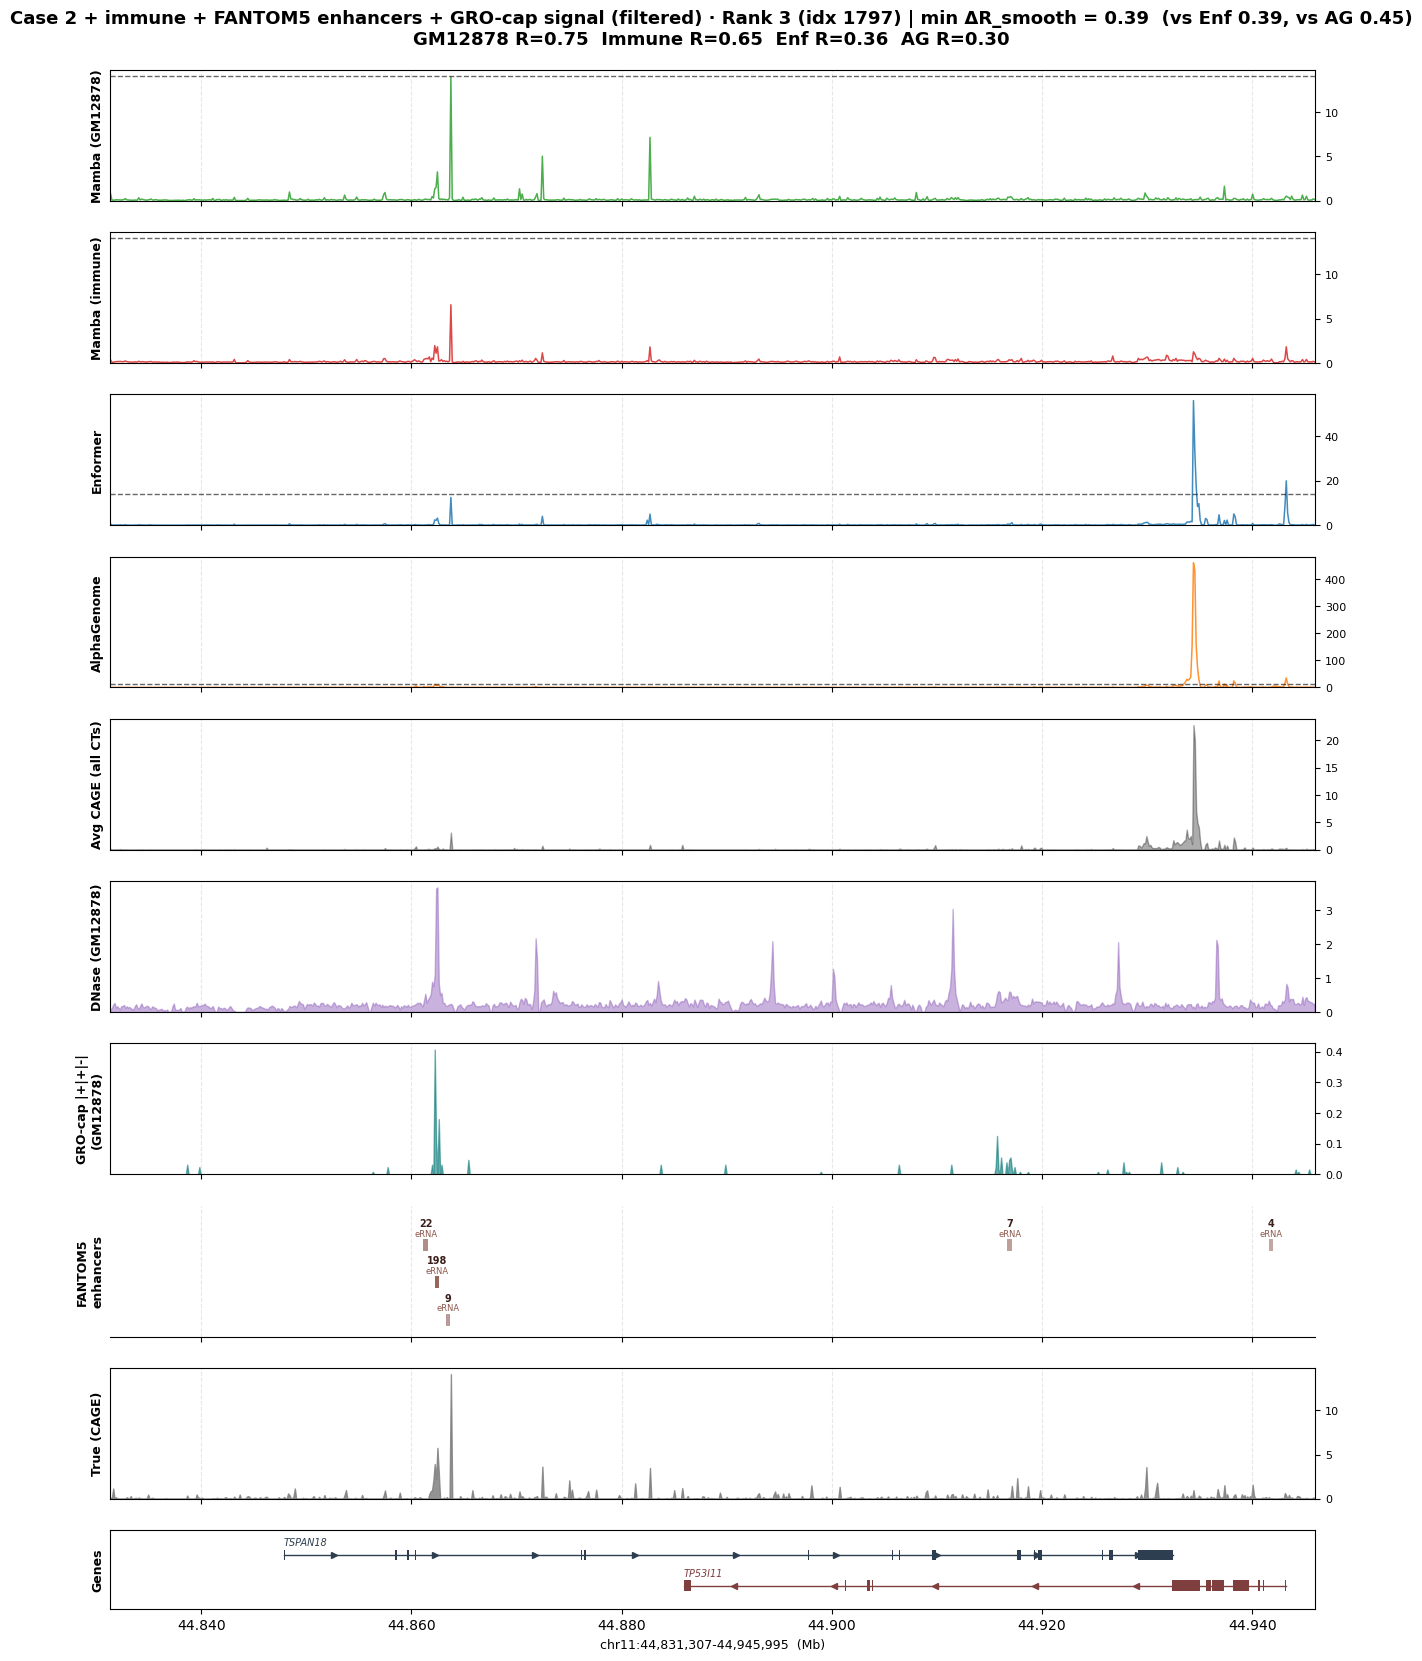

rank 4 (idx 560)  chr7:57,452,857-57,567,545  -> 1 FANTOM5 enhancer(s); GRO-cap signal in 1/896 bins, max 0.0, total 1 reads
    FANTOM5  chr7:57,517,846-57,518,077  (231 bp)  score=4


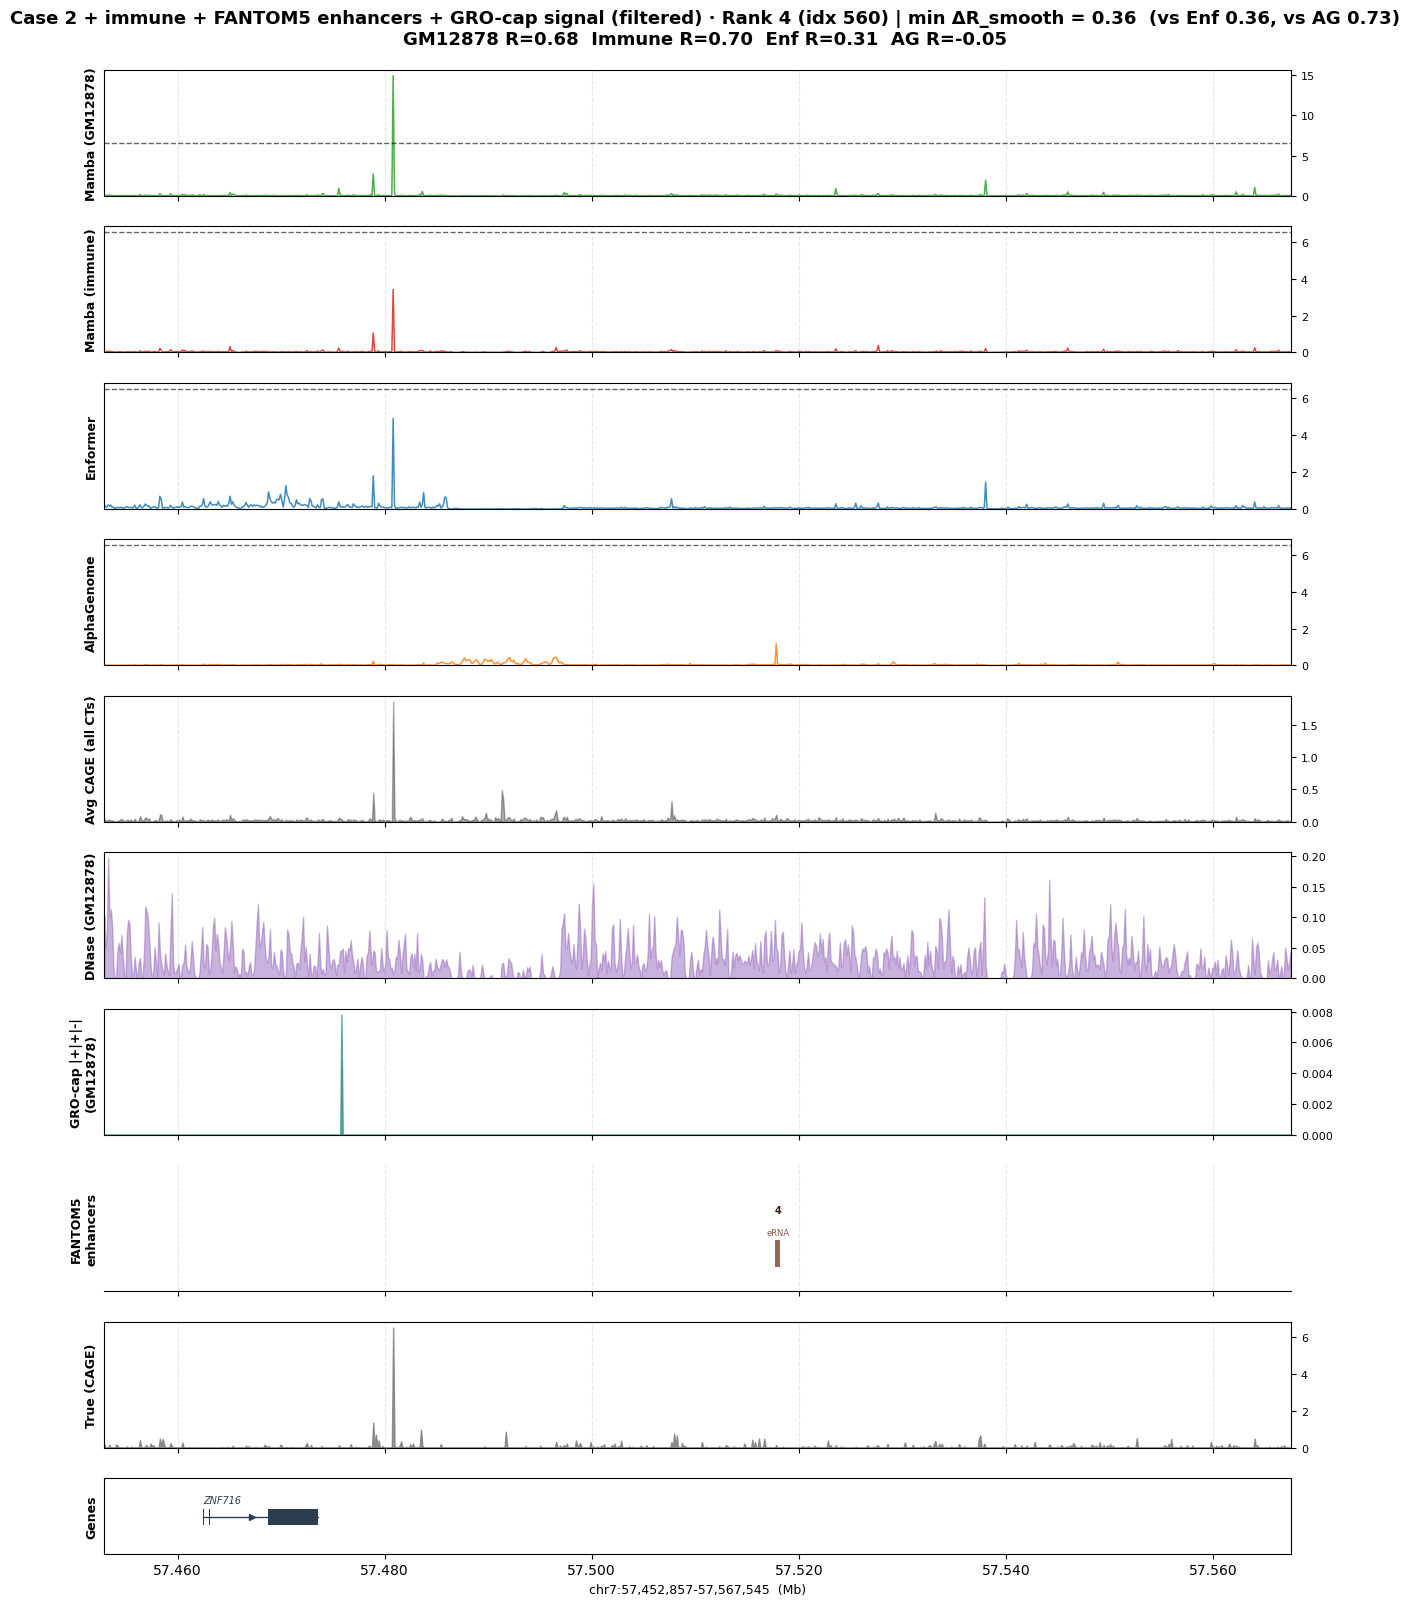

rank 5 (idx 962)  chr19:56,696,668-56,811,356  -> 0 FANTOM5 enhancer(s); GRO-cap signal in 3/896 bins, max 0.0, total 3 reads


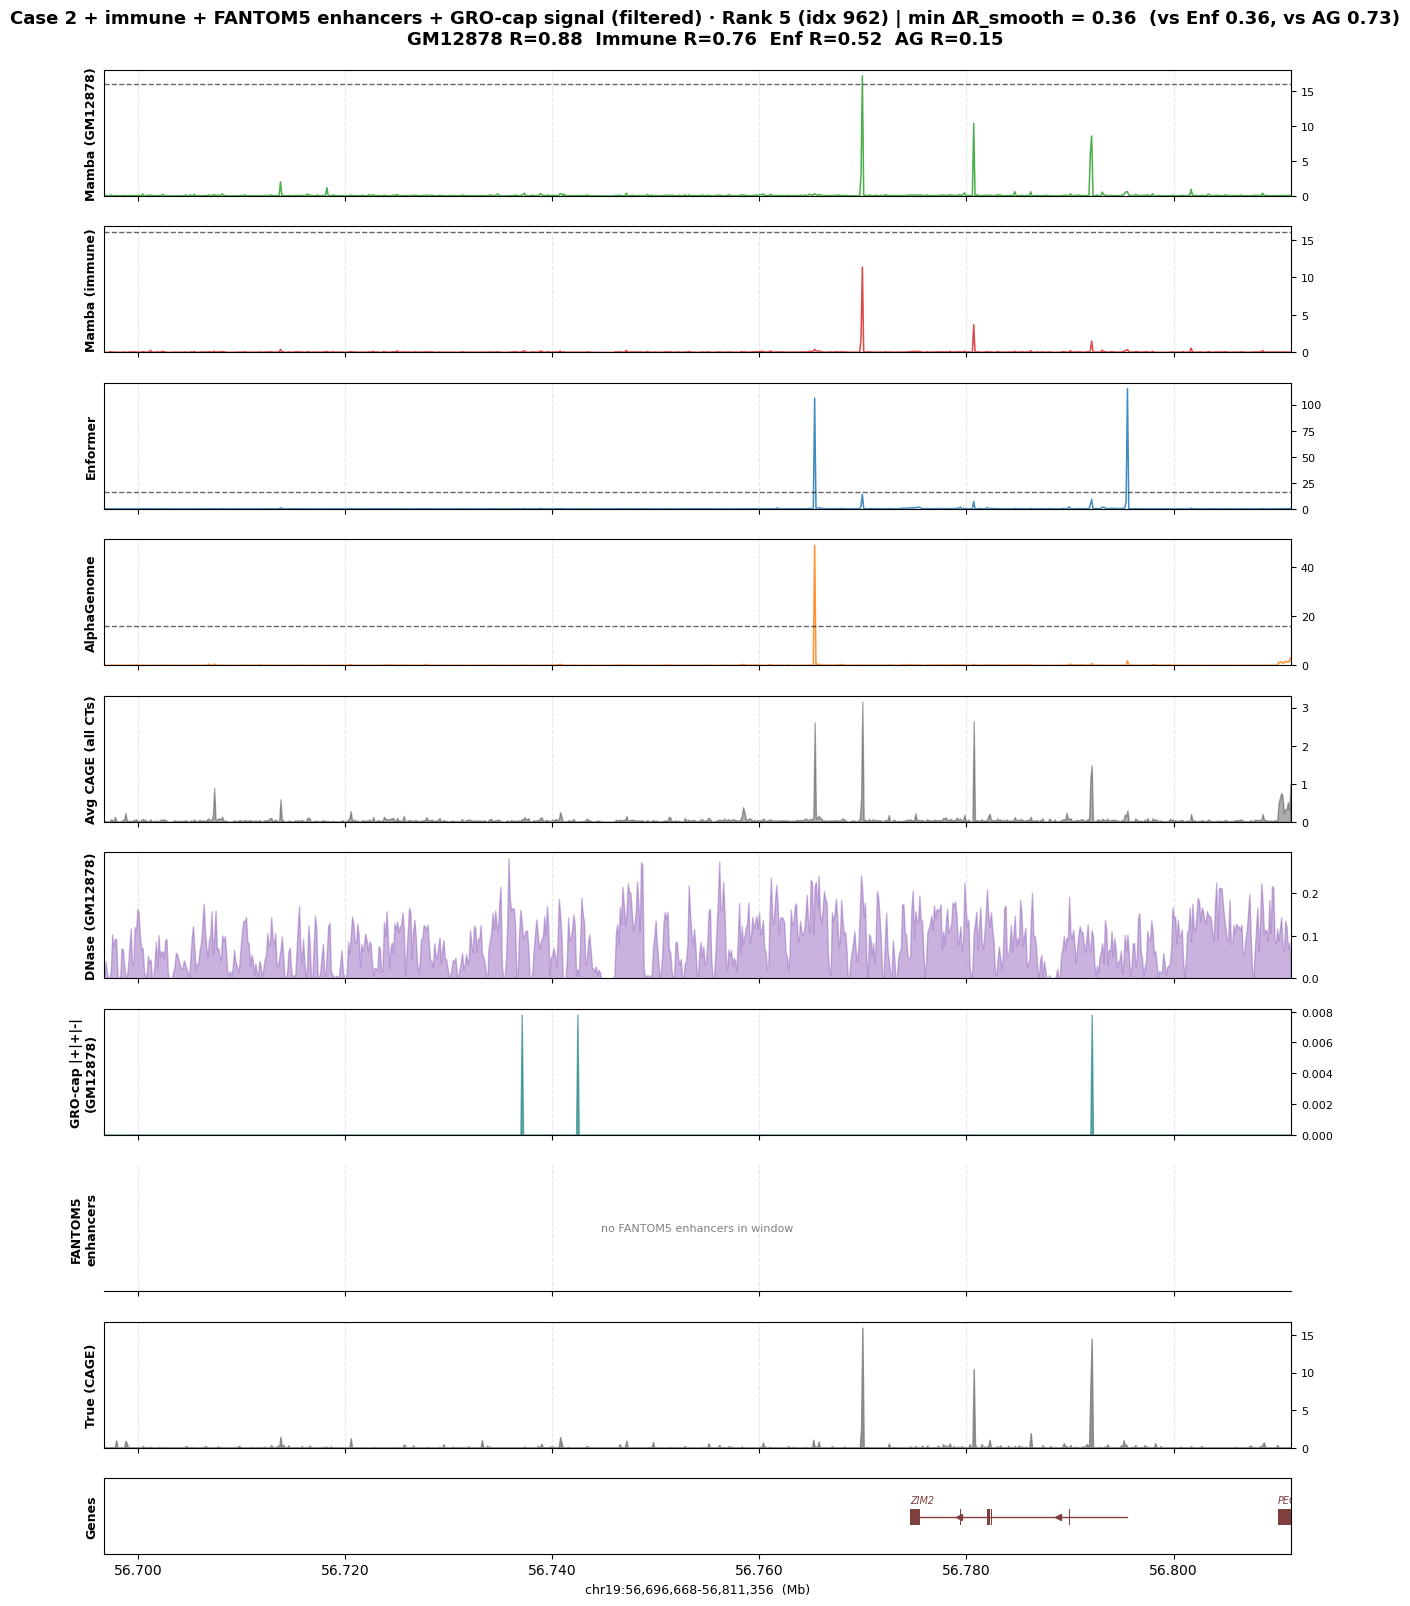

In [4]:
# ---------------------------------------------------------------------------------
# §12 = §11, but the GRO-cap track is the actual bigWig SIGNAL instead of the BED peak calls.
# Run §10 first (enhancer helpers); no data reload needed.
#
# Same experiment as §11's BED (ENCSR719WNF, GRO-cap, GM12878, GRCh38), stranded signal:
#   ENCFF799JUK = "plus strand signal of unique reads"   -> values all POSITIVE (1 .. 28252)
#   ENCFF368RBW = minus strand counterpart               -> values all NEGATIVE (-32958 .. 0)
# ENCODE stores the minus strand as negative numbers, so a literal plus+minus sum would
# largely CANCEL. We take |plus| + |minus| to get total unique-read 5'-end depth per bp,
# then mean-pool 128 bp -> 896 bins so it lines up with the CAGE tracks (same pooling as
# dnase_profile). Uncovered bases read back as NaN and are treated as 0.
#
# Unlike the FANTOM5 score, these values ARE read counts (unique reads), though only ~2.2 Mb
# of the genome is covered in each file, so the track is very sparse and spiky.
# ---------------------------------------------------------------------------------
import pyBigWig

GC_BW_PLUS = '/data1/lesliec/sarthak/data/DK_zarr/bw_files/ENCFF799JUK.bigWig'
GC_BW_MINUS = '/data1/lesliec/sarthak/data/DK_zarr/bw_files/ENCFF368RBW.bigWig'
GC_SIG_COLOR = '#0e7c7b'

if '_gc_bw' not in globals():
    _gc_bw = {'plus': pyBigWig.open(GC_BW_PLUS), 'minus': pyBigWig.open(GC_BW_MINUS)}
    _gc_bw_chroms = {k: h.chroms() for k, h in _gc_bw.items()}
    for k, h in _gc_bw.items():
        hd = h.header()
        print(f'GRO-cap {k:5s} bigWig: {len(_gc_bw_chroms[k])} contigs, '
              f'covered {hd["nBasesCovered"]:,} bp, range [{hd["minVal"]:g}, {hd["maxVal"]:g}]')
else:
    print('GRO-cap bigWigs already open - skipped')


def grocap_signal(chrom, start, end):
    """|plus| + |minus| GRO-cap unique-read depth over [start, end), mean-pooled to
    (end-start)//BIN bins. Returns zeros where a contig or region is absent."""
    n_bp = end - start
    total = np.zeros(n_bp, dtype=np.float64)
    for k, h in _gc_bw.items():
        clen = _gc_bw_chroms[k].get(chrom)
        if clen is None:
            continue
        e = min(end, clen)
        if e <= start:
            continue
        v = np.nan_to_num(np.asarray(h.values(chrom, start, e), dtype=np.float64), nan=0.0)
        total[:e - start] += np.abs(v)      # minus strand is stored negative -> abs, then sum
    n_bins = n_bp // BIN
    return total[:n_bins * BIN].reshape(n_bins, BIN).mean(axis=1)


mamba_key    = 'GM12878_no_mlm_predictions.npy'
immune_key   = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'
ag_key       = 'alphagenome_cage_test_128bp.npy'

delta_enf  = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag   = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_both = np.minimum(delta_enf, delta_ag)
top = top_allowed(delta_both, n=5)

ENH_MIN_SCORE = 0        # raise (e.g. 50) to show only strongly-transcribed enhancers

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, immune_key, enformer_key, ag_key])
    chrom, start, end = region

    # GRO-cap signal is a real signal track (own scale -> reference_exempt), drawn above the
    # FANTOM5 enhancer blocks so the two eRNA views sit next to each other.
    gc_sig = grocap_signal(chrom, start, end)
    tracks.append(Track(gc_sig, name='GRO-cap |+|+|-|\n(GM12878)', color=GC_SIG_COLOR,
                        style='fill', alpha=0.6, reference_exempt=True,
                        chrom=chrom, start=start, bin_size=BIN))
    enh_slot = len(tracks)
    tracks.append(Track(np.zeros(896), name='FANTOM5 enhancers', color=ENH_COLOR,
                        style='fill', alpha=0.0, reference_exempt=True,
                        chrom=chrom, start=start, bin_size=BIN))

    title = (f'Case 2 + immune + FANTOM5 enhancers + GRO-cap signal (filtered) · '
             f'Rank {rank+1} (idx {idx}) | min ΔR_smooth = {delta_both[idx]:.2f}  '
             f'(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n'
             f'GM12878 R={r(mamba_key, idx):.2f}  Immune R={r(immune_key, idx):.2f}  '
             f'Enf R={r(enformer_key, idx):.2f}  AG R={r(ag_key, idx):.2f}')

    enh_rows = enh_layout(chrom, (start, end), min_score=ENH_MIN_SCORE)[2]
    n_signal_axes = len(tracks) + 1
    figsize = (13, 1.6 * n_signal_axes + 1.7 + 0.55 * max(0, enh_rows - 2))

    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title, figsize=figsize)
    enh_recs = draw_enhancer_track(axes[enh_slot], chrom, (start, end),
                                  min_score=ENH_MIN_SCORE)

    nz = int(np.count_nonzero(gc_sig))
    print(f'rank {rank+1} (idx {idx})  {chrom}:{start:,}-{end:,}  -> '
          f'{len(enh_recs)} FANTOM5 enhancer(s); GRO-cap signal in {nz}/896 bins, '
          f'max {gc_sig.max():.1f}, total {gc_sig.sum() * BIN:,.0f} reads')
    for s, e, sc in enh_recs:
        print(f'    FANTOM5  {chrom}:{s:,}-{e:,}  ({e-s} bp)  score={int(sc):,}')
    plt.show()

## 13. §12 with base-pair-resolution reprocessed GM12878 CAGE instead of GRO-cap

Same regions, ranking and tracks as §12, but the extra signal track now comes from
`k562plus10_CAGE.zarr` — reprocessed CAGE at base-pair resolution. Run §10 first (enhancer
helpers); no data reload needed. **The store is opened `mode='r'` (read-only)** and nothing in
this cell writes to it; a test write through that handle raises `ValueError`.

Layout is one array per chromosome, shape `(20, chrom_len)` float32, chunks `(2, 5e6)`. The
store's own `.zattrs['track_metadata']` gives the order as 10 cell types × 2 strands:

| tracks | cell type | | tracks | cell type |
|--------|-----------|-|--------|-----------|
| 0 / 1 | HL-60 | | 10 / 11 | A549 |
| 2 / 3 | K562 | | 12 / 13 | HeLa-S3 |
| 4 / 5 | natural killer cell | | 14 / 15 | frontal cortex |
| 6 / 7 | HepG2 | | 16 / 17 | heart left ventricle |
| **8 / 9** | **GM12878 (+ / −)** | | 18 / 19 | fibroblast of dermis |

So GM12878 is tracks **8 (+) and 9 (−)** — which is also a single chunk along axis 0, so the
`8:10` slice reads one chunk per region. Both strands are stored **non-negative** here (min 0.0
each), so unlike §12's ENCODE bigWigs a plain `8 + 9` sum is correct — no sign flip.

Median smoothed-log R against the existing 128 bp GM12878 conv target, sum-pooled, over 30
random test regions — this confirms both the indexing and the strand summing:

| tracks | median R |
|--------|----------|
| **8 + 9 — GM12878 (+ and −)** | **0.911** ← what this cell plots |
| 8 — GM12878 (+) only | 0.670 |
| 9 — GM12878 (−) only | 0.700 |
| 4 + 5 — natural killer | 0.565 (for contrast) |

So this is a close but not bit-exact view of the same signal: an independent bp-resolution
reprocessing agreeing with the conv target at R ≈ 0.91. Sparse regions are the exception —
where only a handful of bins carry signal, R collapses.

128 bp pooling uses **`sum`** (`CAGE_BP_POOL`), which keeps the track on the conv target's
scale — spot-checked within ~2× of `t1`'s per-region max, versus ~265× too small for `mean`,
since a single-bp spike gets divided by 128. The axis is `reference_exempt` either way, so this
affects the printed magnitudes, not the shape.

bp-res CAGE zarr already open - skipped
mask npz loaded: unmappable (24 chroms), blacklist (24 chroms)
rank 1 (idx 1811)  chrX:37,294,029-37,408,717  -> 1 FANTOM5 enhancer(s); bp-res CAGE nonzero in 4/896 bins, max 3.5, R vs conv target = 0.13
    masks: unmappable 9,044 bp (7.9%),  blacklist 0 bp (0.0%)
    FANTOM5  chrX:37,349,833-37,350,173  (340 bp)  score=62


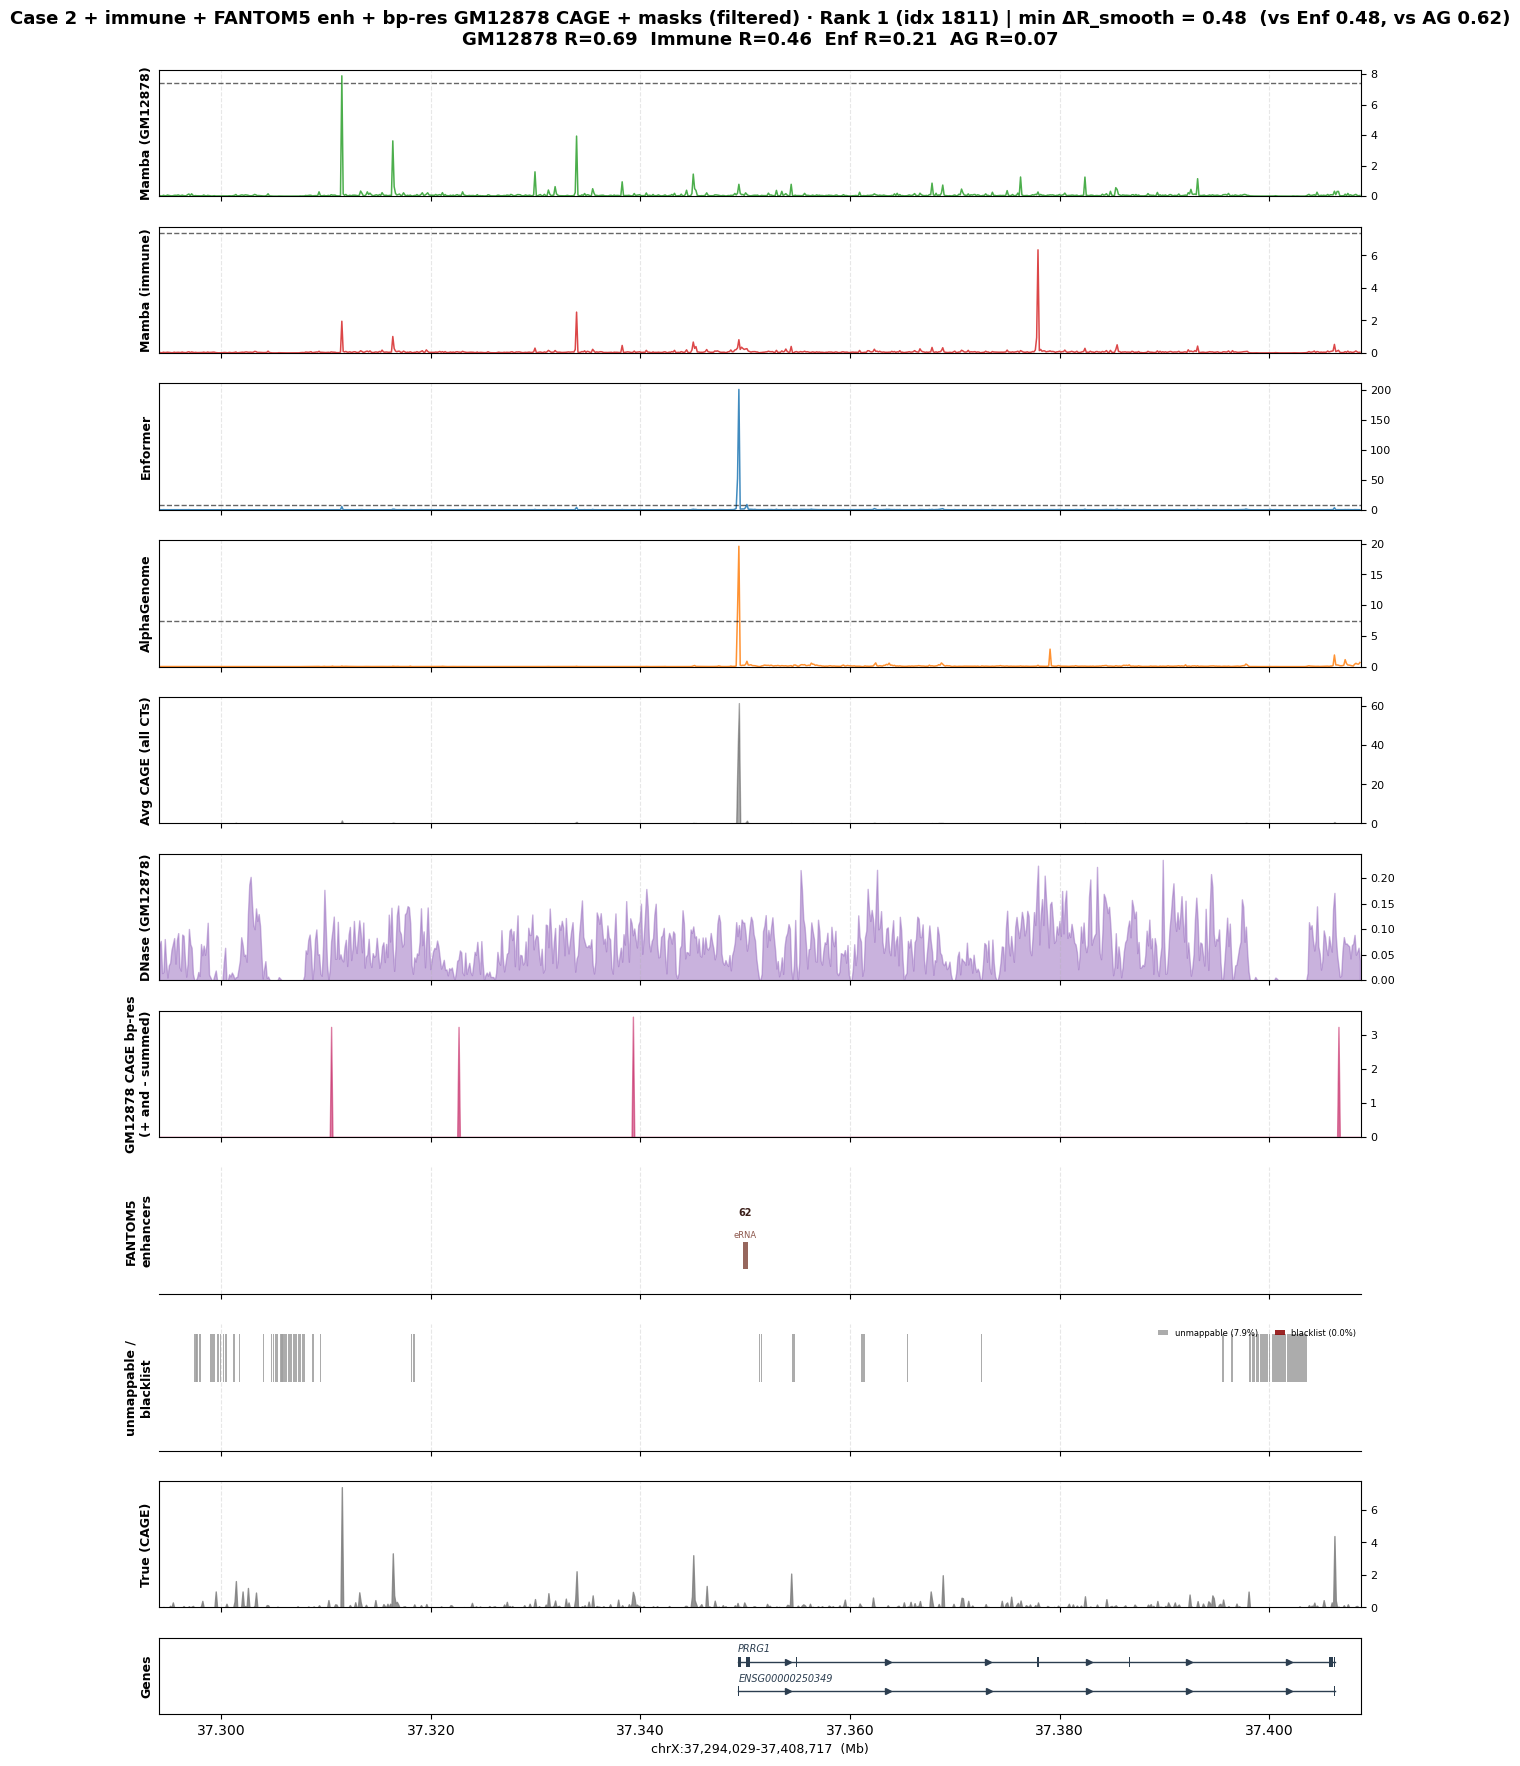

rank 2 (idx 803)  chr19:22,555,439-22,670,127  -> 0 FANTOM5 enhancer(s); bp-res CAGE nonzero in 6/896 bins, max 6.8, R vs conv target = 0.32
    masks: unmappable 17,094 bp (14.9%),  blacklist 0 bp (0.0%)


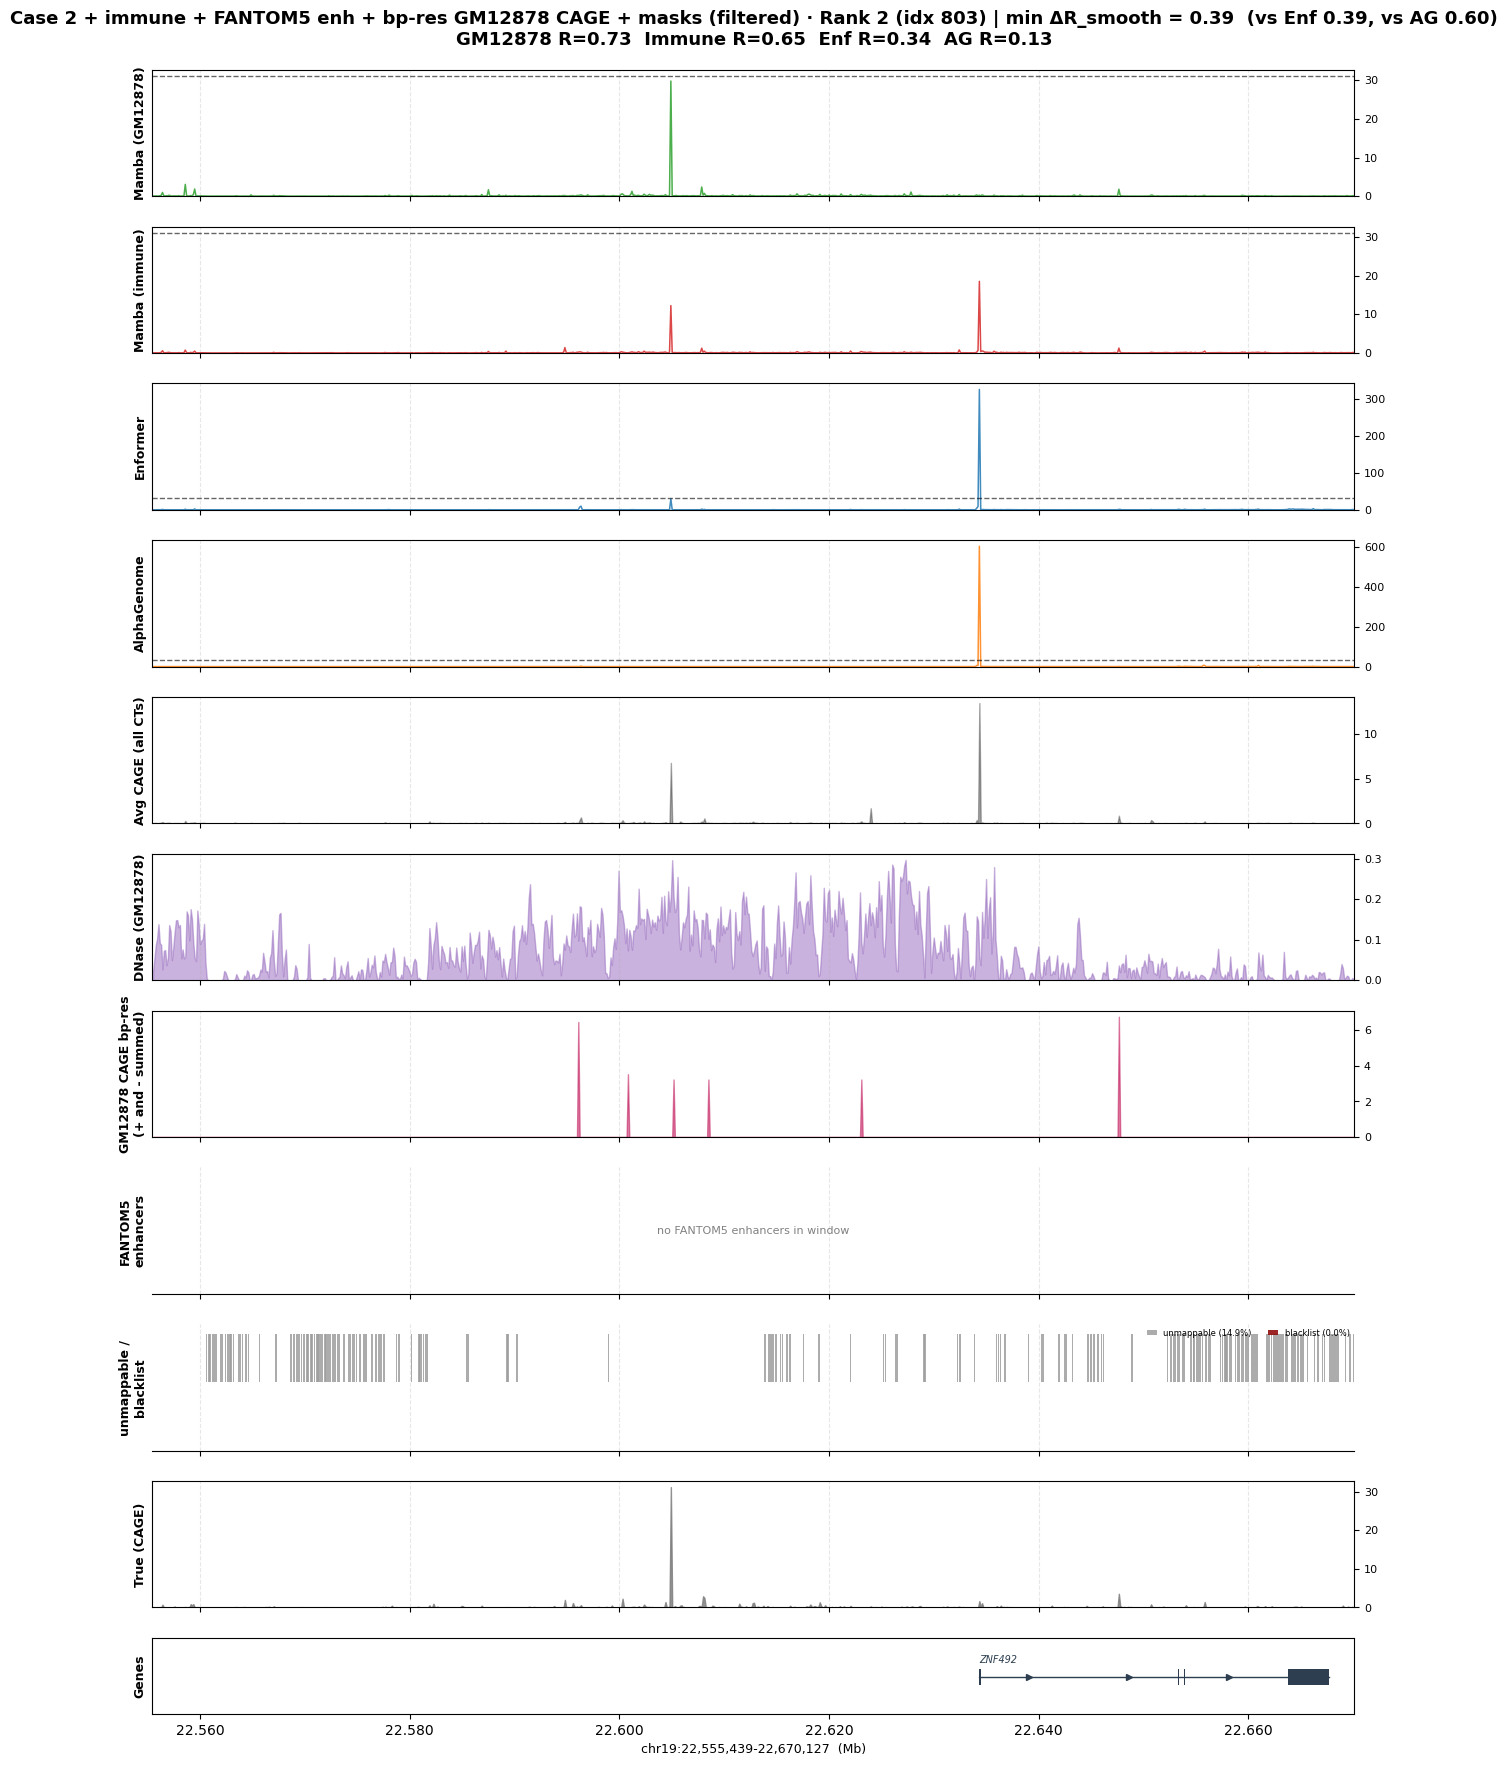

rank 3 (idx 1797)  chr11:44,831,307-44,945,995  -> 5 FANTOM5 enhancer(s); bp-res CAGE nonzero in 30/896 bins, max 13.6, R vs conv target = 0.68
    masks: unmappable 1,689 bp (1.5%),  blacklist 0 bp (0.0%)
    FANTOM5  chr11:44,861,229-44,861,483  (254 bp)  score=22
    FANTOM5  chr11:44,862,258-44,862,617  (359 bp)  score=198
    FANTOM5  chr11:44,863,385-44,863,576  (191 bp)  score=9
    FANTOM5  chr11:44,916,812-44,917,035  (223 bp)  score=7
    FANTOM5  chr11:44,941,646-44,941,931  (285 bp)  score=4


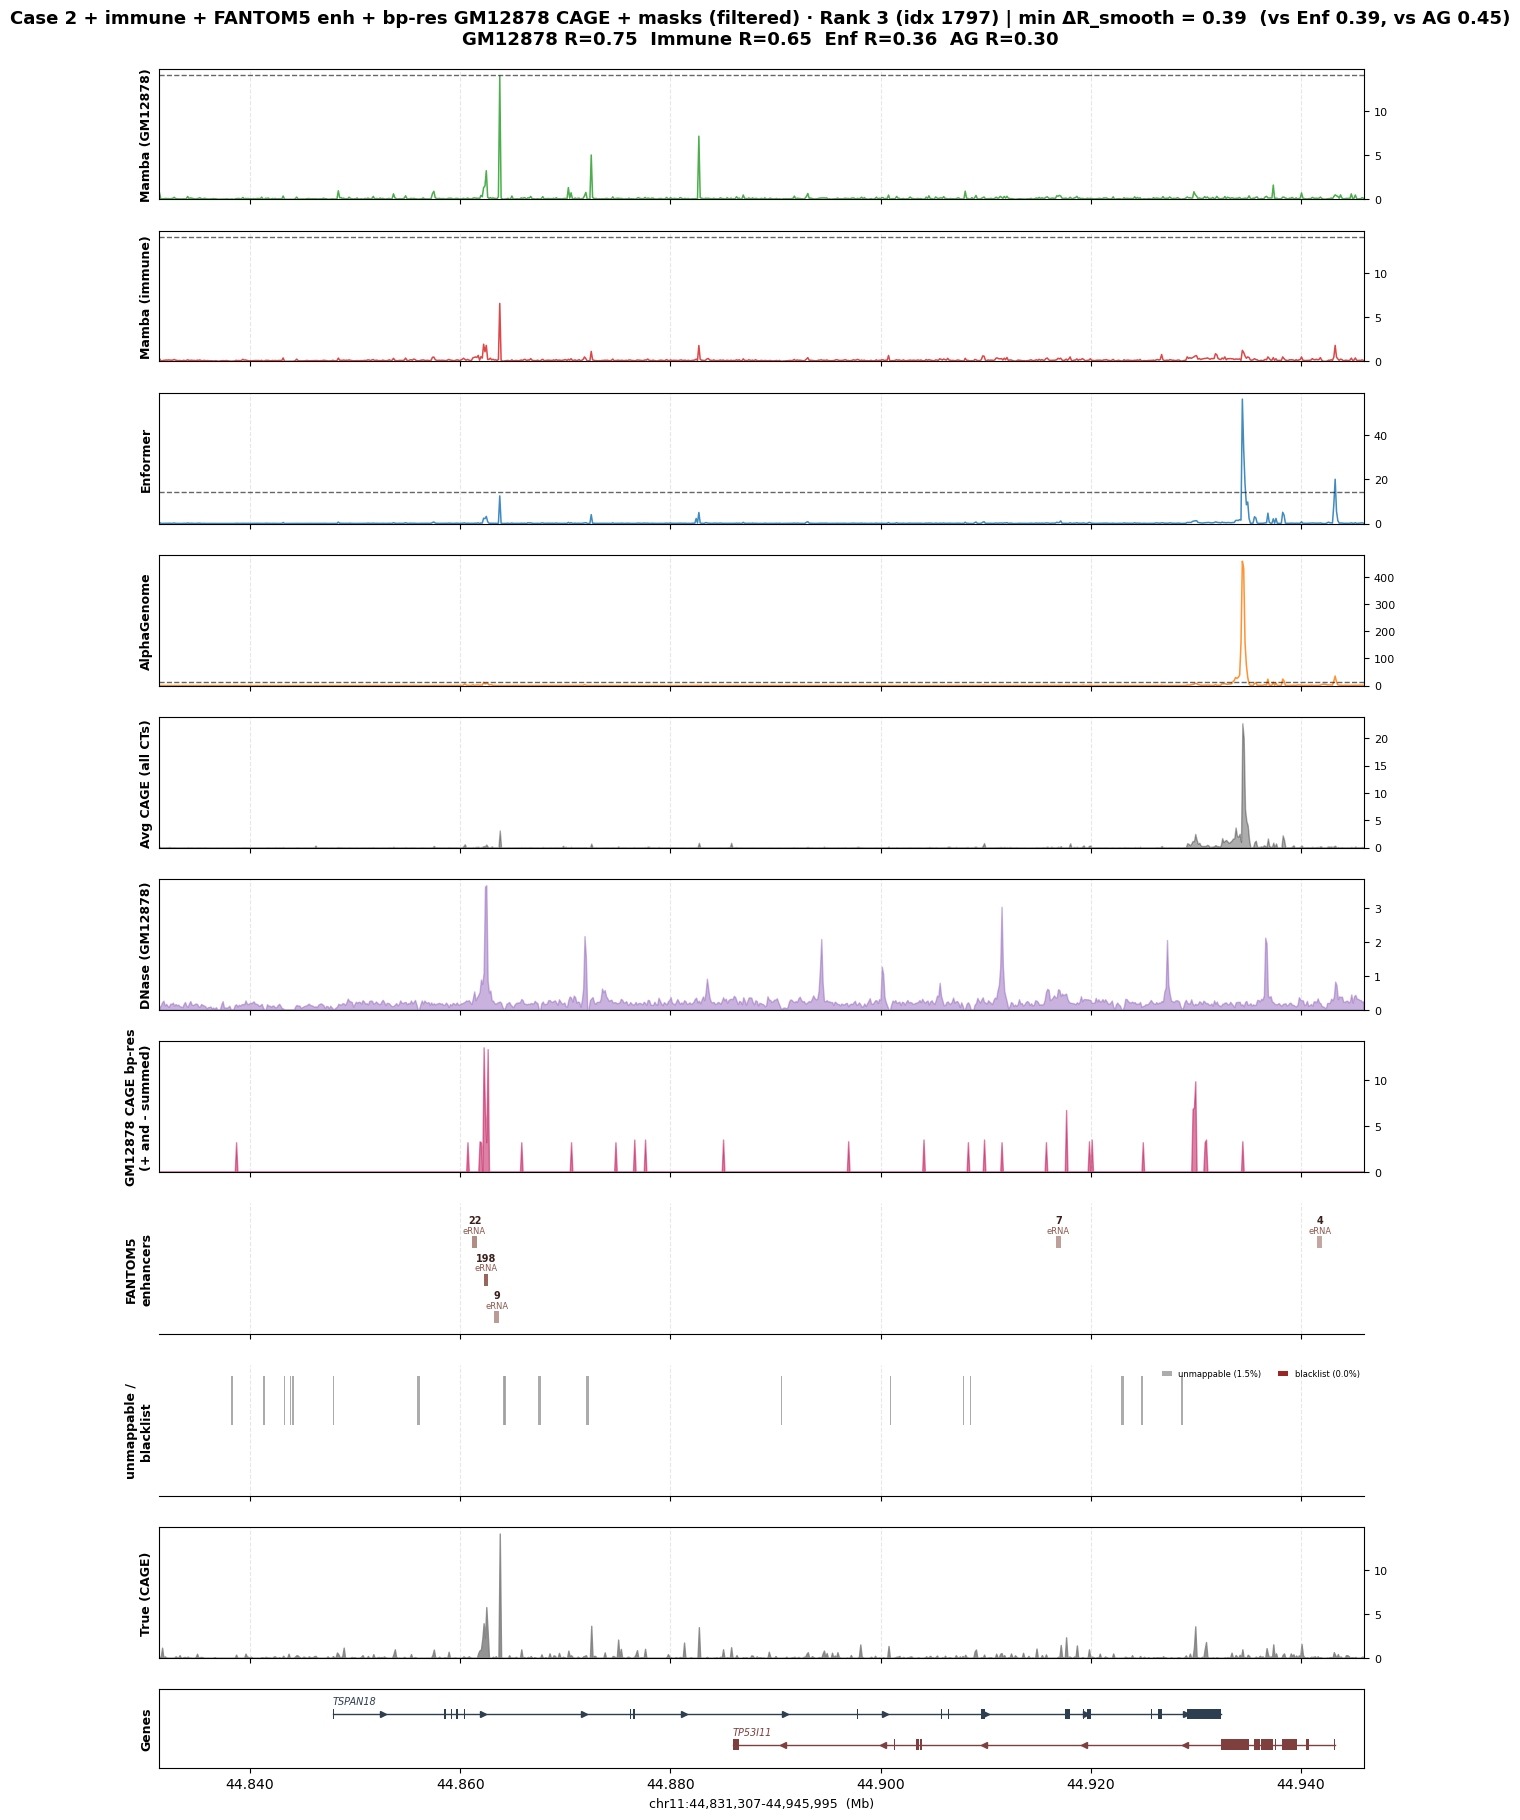

rank 4 (idx 560)  chr7:57,452,857-57,567,545  -> 1 FANTOM5 enhancer(s); bp-res CAGE nonzero in 4/896 bins, max 3.3, R vs conv target = -0.05
    masks: unmappable 8,473 bp (7.4%),  blacklist 372 bp (0.3%)
    FANTOM5  chr7:57,517,846-57,518,077  (231 bp)  score=4


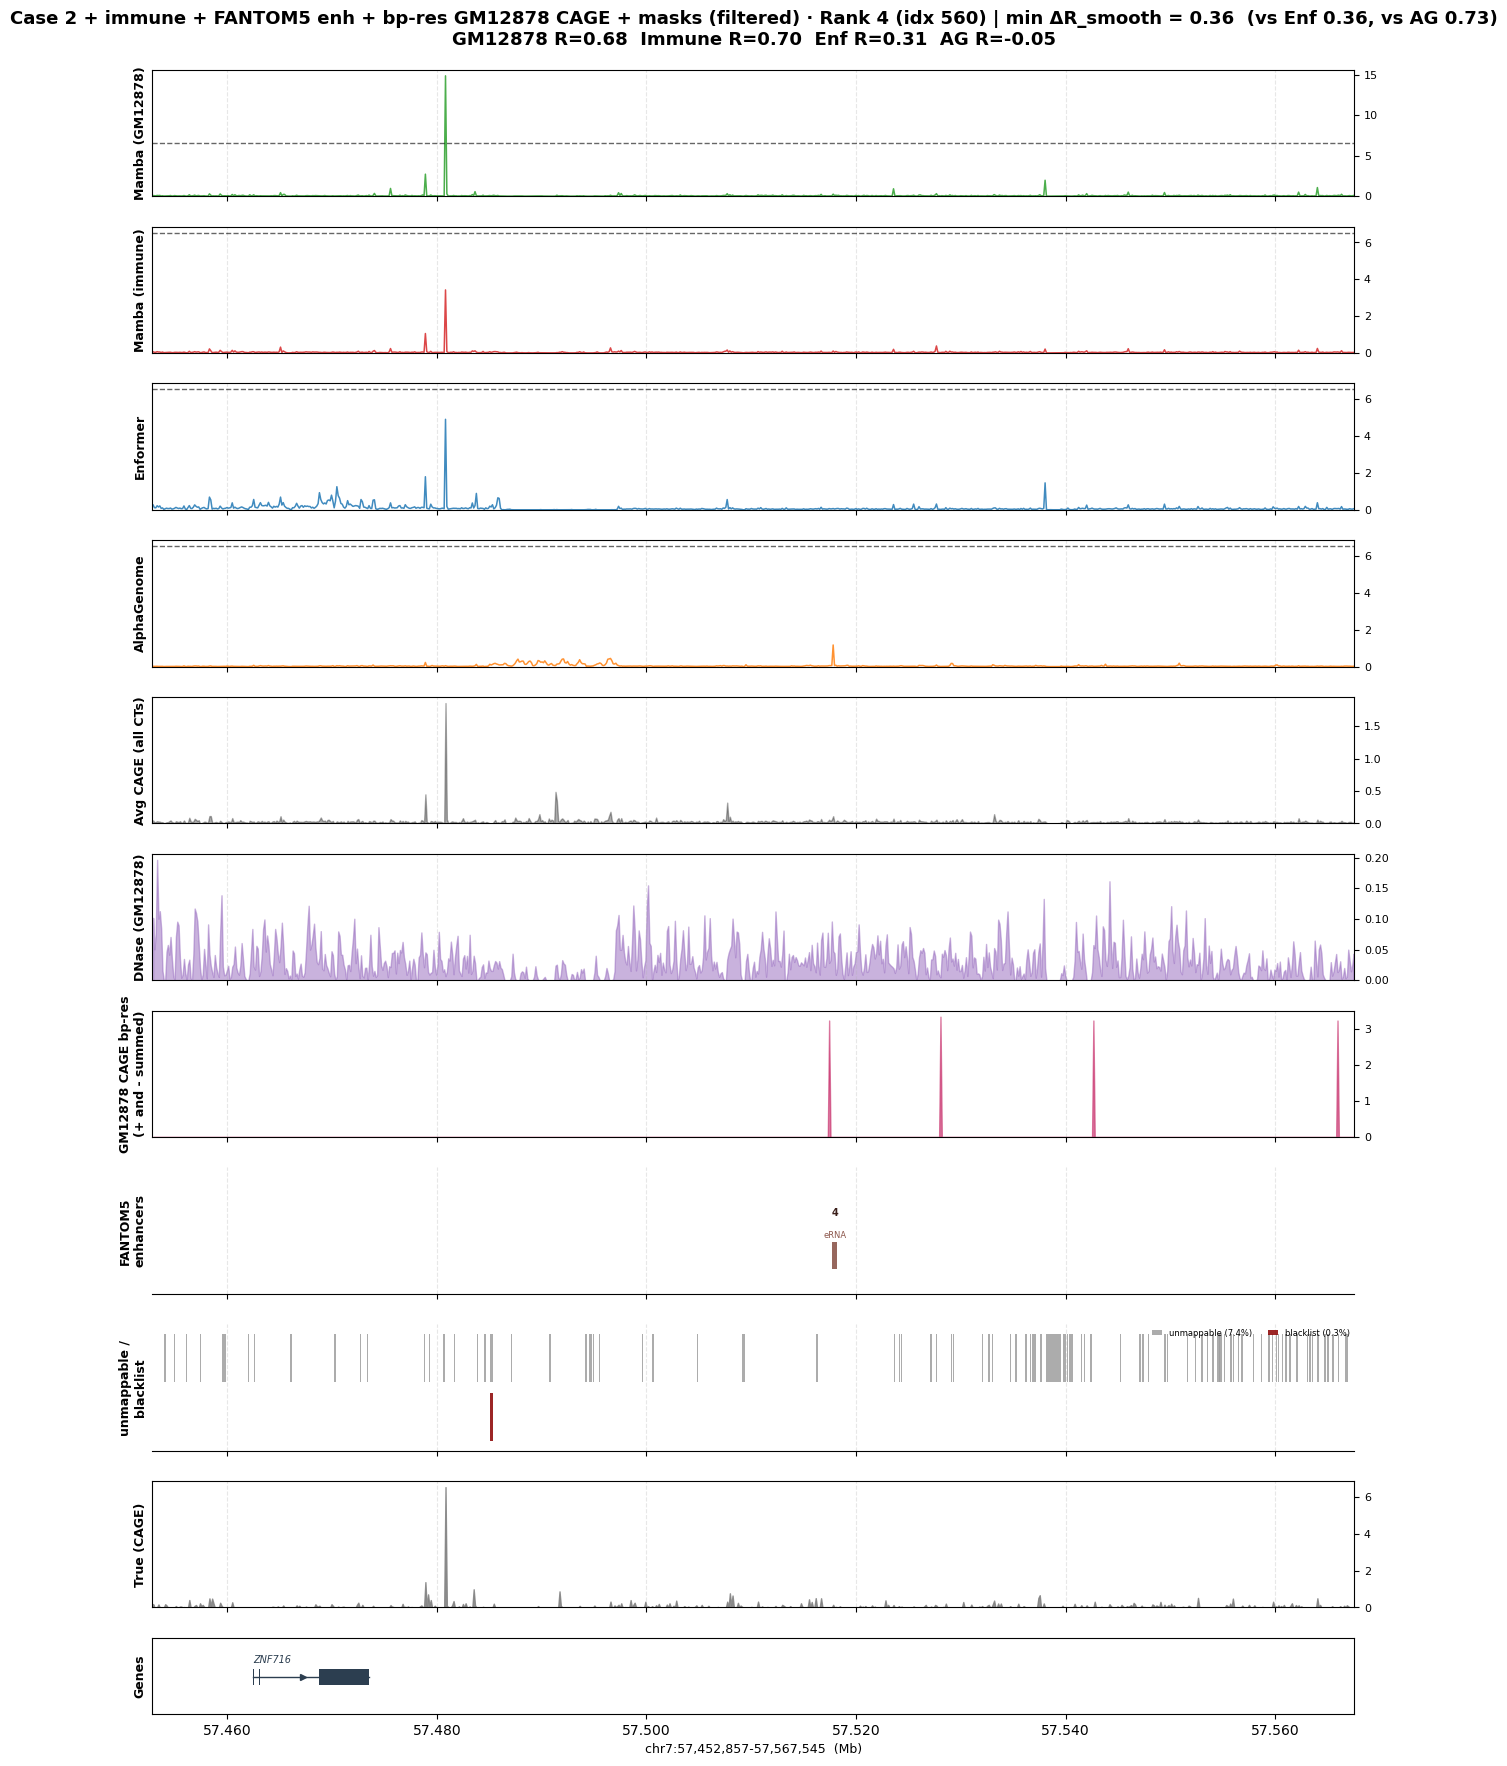

rank 5 (idx 962)  chr19:56,696,668-56,811,356  -> 0 FANTOM5 enhancer(s); bp-res CAGE nonzero in 8/896 bins, max 3.3, R vs conv target = 0.12
    masks: unmappable 7,284 bp (6.4%),  blacklist 0 bp (0.0%)


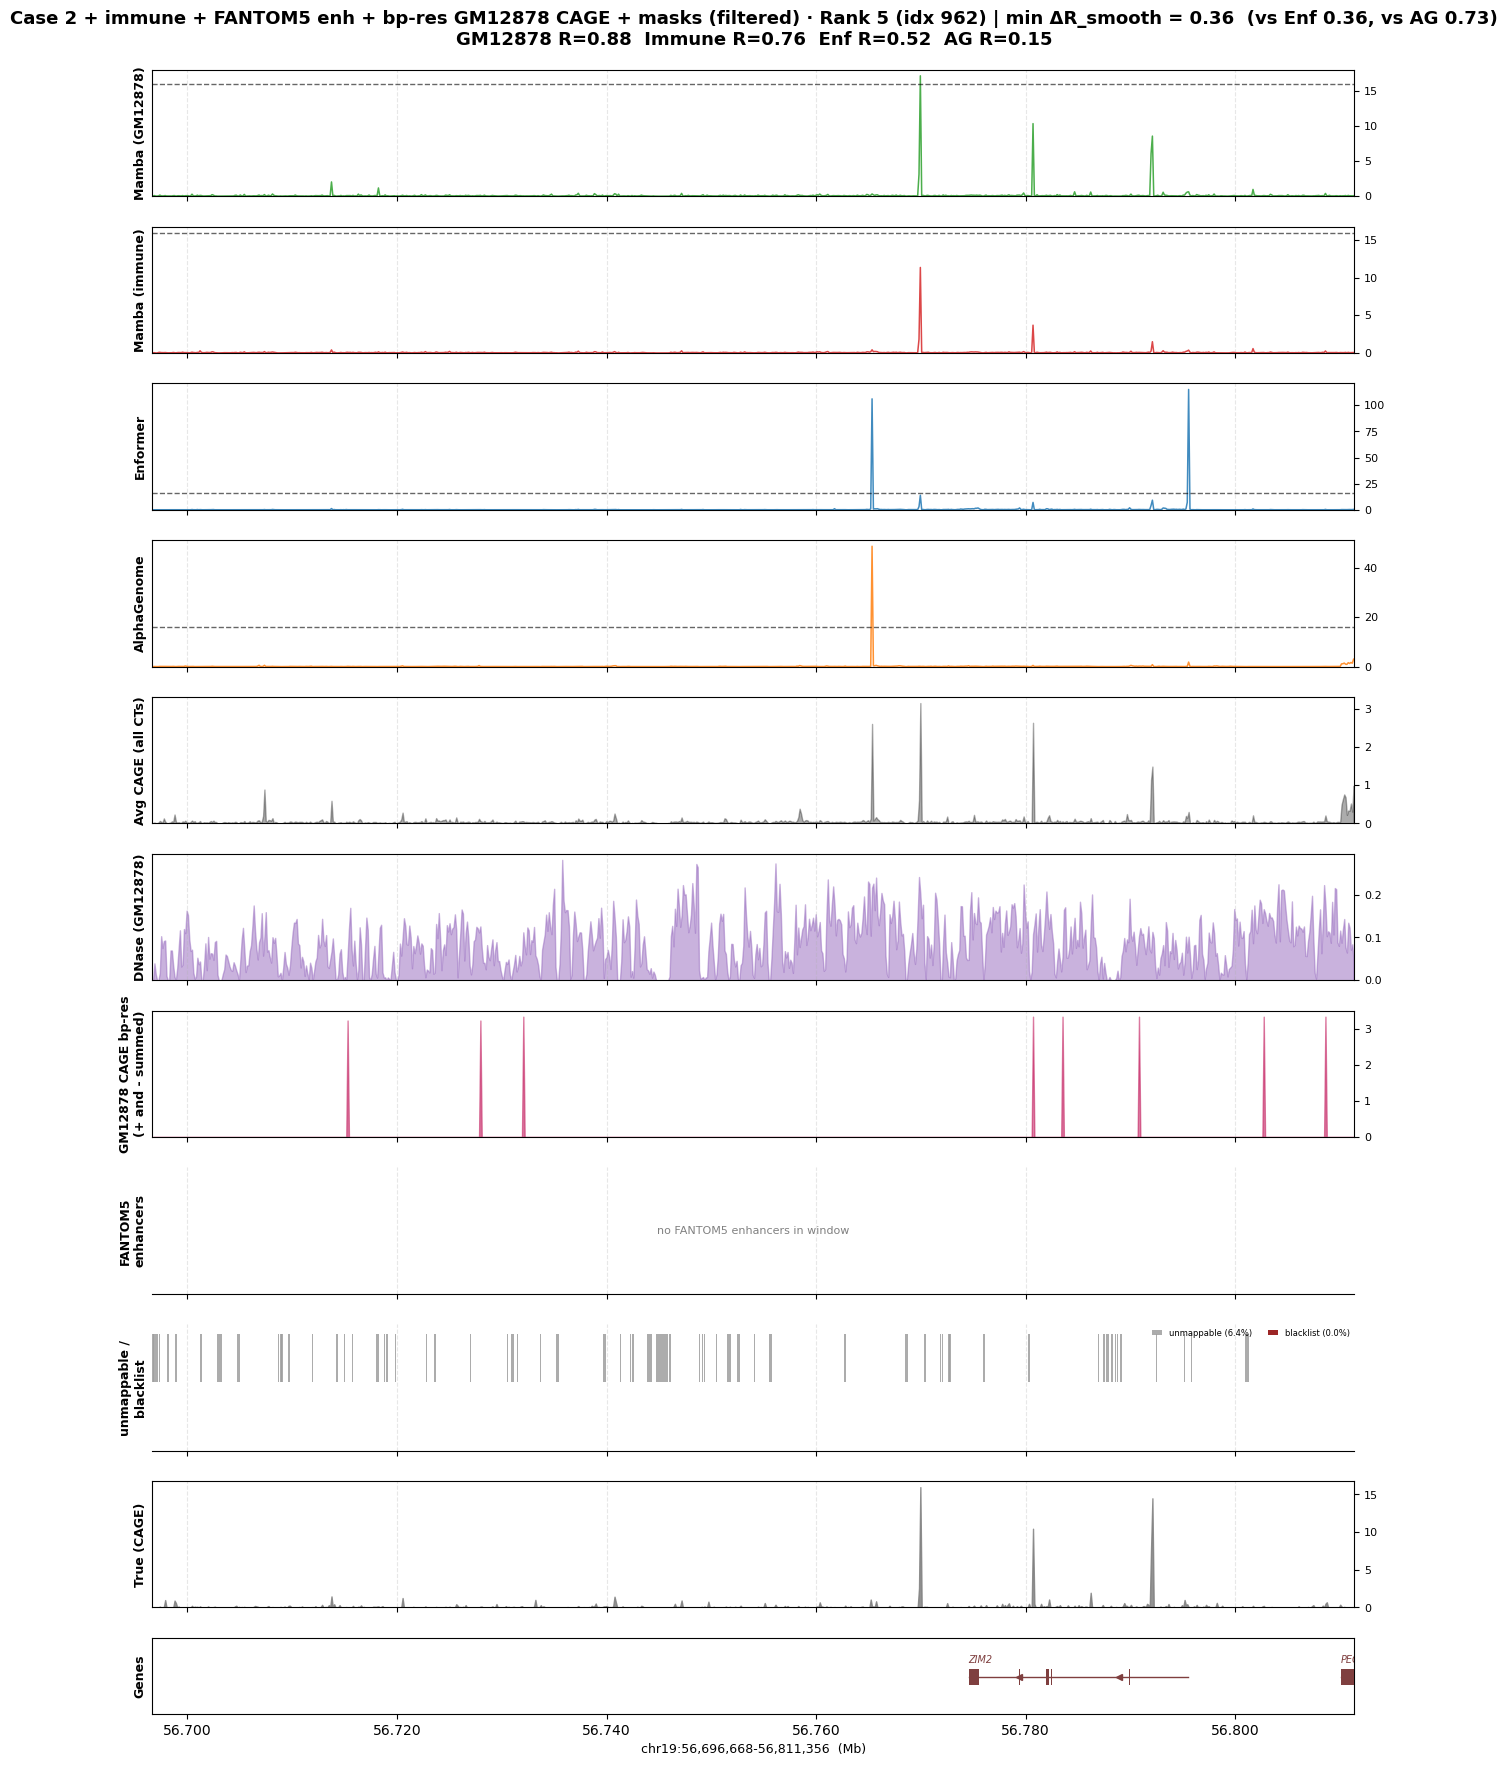

In [6]:
# ---------------------------------------------------------------------------------
# §13 = §12, but the extra signal track is base-pair-resolution reprocessed GM12878 CAGE
# from k562plus10_CAGE.zarr instead of the GRO-cap bigWigs.
# Run §10 first (enhancer helpers); no data reload needed.
#
# The store is one array per chromosome, shape (20, chrom_len) float32, chunks (2, 5e6).
# Its own .zattrs['track_metadata'] gives the track order as 10 cell types x 2 strands:
#   0/1 HL-60   2/3 K562   4/5 natural killer   6/7 HepG2   8/9 GM12878
#   10/11 A549  12/13 HeLa-S3  14/15 frontal cortex  16/17 heart LV  18/19 fibroblast
# -> GM12878 is tracks 8 (+) and 9 (-), which is also one chunk along axis 0, so the
#    8:10 slice below reads a single chunk per region.
#
# Unlike the ENCODE GRO-cap bigWigs in §12, BOTH strands here are stored NON-NEGATIVE
# (observed min 0.0 for each), so a plain 8+9 sum is correct -- no sign flip needed.
#
# Median smoothed-log R against the existing 128 bp GM12878 conv target, sum-pooled, over 30
# random test regions -- this both confirms the .zattrs indexing and justifies summing strands:
#   tracks 8+9  GM12878 (+ and -) : 0.911   <-- what this cell plots
#   track  8    GM12878 (+) only  : 0.670
#   track  9    GM12878 (-) only  : 0.700
#   tracks 4+5  natural killer    : 0.565   (the index-4 pair, for contrast)
# So this is a close but not identical view of the same signal -- an independent bp-resolution
# reprocessing, agreeing with the conv target at R ~0.91, not a bit-exact unbinned copy.
# Sparse regions are the exception: where only a handful of bins carry signal, R collapses.
#
# The store is opened mode='r' (READ-ONLY) -- nothing here writes to it. Verified: attempting
# a write through this handle raises ValueError.
#
# Also adds ONE mask axis carrying BOTH the Borzoi unmappable and blacklist regions, drawn as
# two separately-coloured bands on that single axis. Deliberately NOT axvspan-ed across the
# whole figure: that would tint every signal track and make the CAGE/prediction fills hard to
# read. Both npz files are per-chromosome bp-resolution uint8 0/1 arrays (24 chroms, hg38
# lengths), and in bw2npy.process_data both use `== 1` as the flagged set, so the polarity is
# the same for each. Genome-wide the masks cover roughly 7-16% (unmappable) and 1-7%
# (blacklist) depending on the chromosome.
# ---------------------------------------------------------------------------------
CAGE_BP_ZARR = '/data1/lesliec/sarthak/data/alphagenome/k562plus10_CAGE.zarr'
GM_PLUS_TRACK, GM_MINUS_TRACK = 8, 9        # per .zattrs['track_metadata']
CAGE_BP_COLOR = '#c2185b'

UNMAPPABLE_FILE = '/data1/lesliec/sarthak/data/borzoi/umap.npz'
BLACKLIST_FILE = '/data1/lesliec/sarthak/data/borzoi/blacklist.npz'
MASK_KINDS = ('unmappable', 'blacklist')
MASK_COLORS = {'unmappable': '#9e9e9e', 'blacklist': '#8b0000'}
# 128 bp pooling: 'sum' keeps this on the conv target's scale (spot-checked within ~2x of
# t1's per-region max, vs ~265x too small for 'mean' -- a bp spike divided by 128). The axis
# is reference_exempt either way, so this only affects the printed magnitudes, not the shape.
CAGE_BP_POOL = 'sum'

if '_cage_bp' not in globals():
    _cage_bp = zarr.open(CAGE_BP_ZARR, mode='r')          # READ-ONLY, never written
    _cage_bp_md = dict(_cage_bp.attrs).get('track_metadata', {})
    _lbl = lambda i: (f"{_cage_bp_md[str(i)]['celltype']} ({_cage_bp_md[str(i)]['strand']})"
                      if str(i) in _cage_bp_md else f'track {i}')
    print(f"bp-res CAGE zarr (read-only): chr1 shape {_cage_bp['chr1'].shape}, "
          f"{len(_cage_bp_md)} tracks")
    print(f'  summing track {GM_PLUS_TRACK} = {_lbl(GM_PLUS_TRACK)} '
          f'+ track {GM_MINUS_TRACK} = {_lbl(GM_MINUS_TRACK)}')
else:
    print('bp-res CAGE zarr already open - skipped')


def cage_bp_profile(chrom, start, end):
    """Reprocessed GM12878 CAGE, plus + minus strand, pooled 128 bp -> bins.
    Both strands are non-negative in this store, so combining them is a plain sum."""
    n_bp = end - start
    arr = _cage_bp[chrom]                     # read-only view; nothing is written
    e = min(end, arr.shape[1])
    blk = np.asarray(arr[GM_PLUS_TRACK:GM_MINUS_TRACK + 1, start:e], dtype=np.float64)
    total = np.zeros(n_bp, dtype=np.float64)
    total[:e - start] = blk.sum(axis=0)       # + and - strand summed
    binned = total[:(n_bp // BIN) * BIN].reshape(n_bp // BIN, BIN)
    return binned.sum(axis=1) if CAGE_BP_POOL == 'sum' else binned.mean(axis=1)


# --- unmappable / blacklist masks -------------------------------------------------
if '_mask_npz' not in globals():
    _mask_npz = {'unmappable': np.load(UNMAPPABLE_FILE),
                 'blacklist': np.load(BLACKLIST_FILE)}
    _mask_runs = {}          # (kind, chrom) -> (run_starts, run_ends), populated lazily
    print(f'mask npz loaded: ' + ', '.join(
        f'{k} ({len(_mask_npz[k].files)} chroms)' for k in MASK_KINDS))
else:
    print('mask npz already loaded - skipped')


def _mask_intervals(kind, chrom):
    """Run-length-encode a bp mask into (starts, ends) once per (kind, chrom) and cache that.
    The raw arrays are ~1 byte/bp (chr1 alone is 249 MB), so the big array is released after
    encoding and only the tiny interval lists are kept."""
    key = (kind, chrom)
    if key not in _mask_runs:
        a = _mask_npz[kind][chrom]
        m = (a > 0).astype(np.int8)
        d = np.diff(np.concatenate(([np.int8(0)], m, [np.int8(0)])))
        _mask_runs[key] = (np.flatnonzero(d == 1), np.flatnonzero(d == -1))
        del a, m, d
    return _mask_runs[key]


def masks_in(chrom, start, end):
    """{kind: [(s, e), ...]} mask runs clipped to [start, end)."""
    out = {}
    for kind in MASK_KINDS:
        if chrom not in _mask_npz[kind].files:
            out[kind] = []
            continue
        s, e = _mask_intervals(kind, chrom)
        i = np.searchsorted(e, start, 'right')      # runs ending after `start`
        j = np.searchsorted(s, end, 'left')         # runs starting before `end`
        out[kind] = list(zip(np.maximum(s[i:j], start).tolist(),
                             np.minimum(e[i:j], end).tolist()))
    return out


def draw_mask_track(ax, chrom, xlim, min_frac=0.0012):
    """Unmappable and blacklist regions as two coloured bands on ONE axis (upper =
    unmappable, lower = blacklist). Confined to this axis so no other track gets tinted.
    Returns {kind: covered_bp}."""
    ax.set_xlim(xlim)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel('unmappable /\nblacklist', fontsize=9, weight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    for side in ('left', 'right', 'top'):
        ax.spines[side].set_visible(False)

    span = xlim[1] - xlim[0]
    min_w = span * min_frac          # keep single-bp flags visible at 114 kb zoom
    runs = masks_in(chrom, int(xlim[0]), int(xlim[1]))
    covered = {}
    for kind, y0 in zip(MASK_KINDS, (0.54, 0.08)):
        covered[kind] = sum(e - s for s, e in runs[kind])
        for s, e in runs[kind]:
            w = max(e - s, min_w)
            ax.add_patch(Rectangle((s, y0), w, 0.38, facecolor=MASK_COLORS[kind],
                                   edgecolor='none', alpha=0.85, zorder=3))
    ax.legend(handles=[Rectangle((0, 0), 1, 1, facecolor=MASK_COLORS[k], alpha=0.85)
                       for k in MASK_KINDS],
              labels=[f'{k} ({100 * covered[k] / span:.1f}%)' for k in MASK_KINDS],
              fontsize=6, loc='upper right', frameon=False, ncol=2,
              handlelength=1.2, borderaxespad=0.1)
    if not any(covered.values()):
        ax.text(0.5, 0.5, 'no unmappable or blacklist regions in window',
                transform=ax.transAxes, ha='center', va='center', fontsize=8, color='gray')
    return covered


mamba_key    = 'GM12878_no_mlm_predictions.npy'
immune_key   = 'immune_CAGE_predictions.npy'
enformer_key = 'enformer'
ag_key       = 'alphagenome_cage_test_128bp.npy'

delta_enf  = pearson_smooth_results[mamba_key] - pearson_smooth_results[enformer_key]
delta_ag   = pearson_smooth_results[mamba_key] - pearson_smooth_results[ag_key]
delta_both = np.minimum(delta_enf, delta_ag)
top = top_allowed(delta_both, n=5)

ENH_MIN_SCORE = 0        # raise (e.g. 50) to show only strongly-transcribed enhancers

for rank, idx in enumerate(top):
    tracks, truth, region = make_tracks(idx, [mamba_key, immune_key, enformer_key, ag_key])
    chrom, start, end = region

    # bp-resolution CAGE on its own scale (reference_exempt), above the enhancer blocks.
    cage_bp = cage_bp_profile(chrom, start, end)
    tracks.append(Track(cage_bp, name='GM12878 CAGE bp-res\n(+ and - summed)',
                        color=CAGE_BP_COLOR, style='fill', alpha=0.55,
                        reference_exempt=True, chrom=chrom, start=start, bin_size=BIN))
    enh_slot = len(tracks)
    tracks.append(Track(np.zeros(896), name='FANTOM5 enhancers', color=ENH_COLOR,
                        style='fill', alpha=0.0, reference_exempt=True,
                        chrom=chrom, start=start, bin_size=BIN))
    # one placeholder axis carrying BOTH masks as separately-coloured bands
    mask_slot = len(tracks)
    tracks.append(Track(np.zeros(896), name='unmappable / blacklist', color='#9e9e9e',
                        style='fill', alpha=0.0, reference_exempt=True,
                        chrom=chrom, start=start, bin_size=BIN))

    title = (f'Case 2 + immune + FANTOM5 enh + bp-res GM12878 CAGE + masks (filtered) · '
             f'Rank {rank+1} (idx {idx}) | min ΔR_smooth = {delta_both[idx]:.2f}  '
             f'(vs Enf {delta_enf[idx]:.2f}, vs AG {delta_ag[idx]:.2f})\n'
             f'GM12878 R={r(mamba_key, idx):.2f}  Immune R={r(immune_key, idx):.2f}  '
             f'Enf R={r(enformer_key, idx):.2f}  AG R={r(ag_key, idx):.2f}')

    enh_rows = enh_layout(chrom, (start, end), min_score=ENH_MIN_SCORE)[2]
    n_signal_axes = len(tracks) + 1
    figsize = (13, 1.6 * n_signal_axes + 1.7 + 0.55 * max(0, enh_rows - 2))

    fig, axes = plot_tracks(tracks, genes=ann, region=region, ground_truth=truth,
                            collapse_genes=True, title=title, figsize=figsize)
    enh_recs = draw_enhancer_track(axes[enh_slot], chrom, (start, end),
                                   min_score=ENH_MIN_SCORE)
    mask_cov = draw_mask_track(axes[mask_slot], chrom, (start, end))

    # how well does the bp-res reprocessing agree with the 128 bp conv target here?
    R_bp = smoothed_log_pearson(cage_bp, np.asarray(t1[idx]))
    win = end - start
    print(f'rank {rank+1} (idx {idx})  {chrom}:{start:,}-{end:,}  -> '
          f'{len(enh_recs)} FANTOM5 enhancer(s); bp-res CAGE nonzero in '
          f'{int(np.count_nonzero(cage_bp))}/896 bins, max {cage_bp.max():.1f}, '
          f'R vs conv target = {R_bp:.2f}')
    print(f'    masks: ' + ',  '.join(
        f'{k} {mask_cov[k]:,} bp ({100 * mask_cov[k] / win:.1f}%)' for k in MASK_KINDS))
    for s, e, sc in enh_recs:
        print(f'    FANTOM5  {chrom}:{s:,}-{e:,}  ({e-s} bp)  score={int(sc):,}')
    plt.show()